In [2]:
1

1

Optimization terminated successfully.
         Current function value: -189.133286
         Iterations: 15
         Function evaluations: 30
 message: Solution found.
 success: True
  status: 0
     fun: -7.666552992013417
       x: 1.868204484697312
     nit: 15
    nfev: 15
8 188.7927830812204


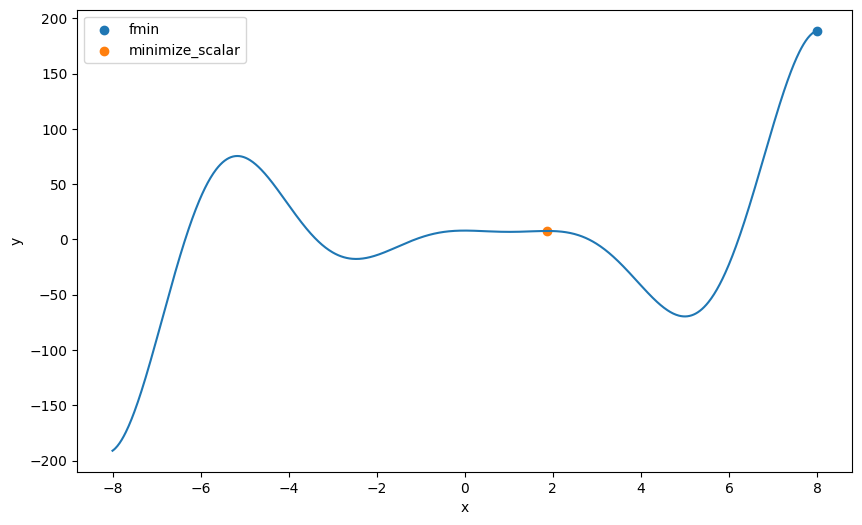

In [3]:
import numpy as np
from scipy.optimize import minimize_scalar, fmin
import matplotlib.pyplot as plt

def f(x,w=8):
    return w * np.cos(x)+3*x**2 * np.sin(x)

def fm(x,w=8):
    return -f(x,w) # отриц функция


(x_min, x_max) = (-8, 8)

f_min=fmin(fm, 7)

if f_min>x_max:
    f_min=x_max
elif f_min<x_min:
    f_min=x_min

result = minimize_scalar(fm, bounds=[x_min, x_max], method='bounded') # не оптимальная точка
print(result)

x = f_min
y = f(x)
print(x,y)

plt.figure(figsize=(10,6))
x_arr=np.linspace(x_min,x_max,1000)
plt.plot(x_arr, f(x_arr))
plt.scatter(x,y, label = 'fmin')
plt.scatter(result.x, f(result.x), label = 'minimize_scalar')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

2 зд

In [4]:
import numpy as np
def f(x,w=8):
    return w * np.cos(x)+3*x**2 * np.sin(x)

def bruteforce (w=8):

    (x_min, x_max) = (-8, 8)

    X_MIN_GLOBAL = x_min
    X_MAX_GLOBAL = x_max

    n_shag=0.1
    n_round=1
    xres=x_min
    tol = 1e-10

    while n_shag > tol:
        x_value = np.arange(x_min, x_max, n_shag)

        y_value = np.array([f(x,w) for x in x_value])
        max_value = -np.inf
        for y in y_value:
            if y > max_value:
                max_value = y
                xres = round(x_value[np.where(y_value==max_value)][0], n_round)

        x_min = max(X_MIN_GLOBAL, xres - n_shag)
        x_max = min(X_MAX_GLOBAL, xres + n_shag)
        n_round+=1
        n_shag/=10
        n_shag = round(n_shag, n_round)
        #print(xres, max_value, n_shag, x_max)
    return xres

bruteforce()

np.float64(7.999999999)

3

In [9]:
import random
def f(x,w=8):
    return w * np.cos(x)+3*x**2 * np.sin(x)

def fm(x,w=8):
    return -f(x,w)

def global_max(w=8, x_min=-8, x_max=8, coarse_step=0.001):

    #  плотный перебор
    x_coarse = np.arange(x_min, x_max + coarse_step, coarse_step)
    #  добавляем границы
    if x_coarse[0] != x_min:
        x_coarse = np.insert(x_coarse, 0, x_min)
    if x_coarse[-1] != x_max:
        x_coarse = np.append(x_coarse, x_max)
    y_coarse = f(x_coarse, w)

    # Находим глобальный максимум
    max_idx = np.argmax(y_coarse)
    x_initial = x_coarse[max_idx]
    y_initial = y_coarse[max_idx]

    print(f"поиск: максимум при x = {x_initial:.4f}, y = {y_initial:.4f}")

    # 2
    result = minimize_scalar(fm, bounds=[max(x_min, x_initial - 0.2), min(x_max, x_initial + 0.2)], method='bounded', args=(w,))
    x_opt = result.x
    y_opt = f(x_opt, w)
    print(f"норм результат: x = {x_opt:.8f}, y = {y_opt:.8f}")
    return x_opt

w=8
w_optimize_scalar=[]
w_fmin = []
tol=10**-5
for i in range (100):
    wrand=w*random.uniform(0.1, 2)
    x1 =global_max(wrand, x_min, x_max)
    res_fmin=fmin(lambda x: fm(x,wrand), 7)
    if res_fmin>x_max:
        res_fmin=x_max
    elif res_fmin<x_min:
        res_fmin=x_min
    x2=bruteforce(w)
    razn=abs(x1-x2)
    razn_fmin=abs(res_fmin-x2)
    plt.figure(figsize=(6,2))
    x_arr=np.linspace(x_min,x_max,1000)
   # plt.plot(x_arr, [f(x,wrand) for x in x_arr])
    #plt.scatter(x1,f(x1,wrand), label='minimize_scalar')
    #plt.scatter(x2,f(x2,wrand), label='bruteforce')
    #plt.scatter(res_fmin,f(res_fmin,wrand), label='fmin')
    #plt.xlabel('x')
   # plt.ylabel('y')
    #plt.legend()
    if razn>tol:
        w_optimize_scalar.append(wrand)
    if razn_fmin>tol:
        print(res_fmin, x2)
        w_fmin.append(wrand)

        
print("w для которых оптимальная точка не оптимальная при minimize_scalar:", w_optimize_scalar)
print("w для которых оптимальная точка не оптимальная при fmin:", w_fmin)

поиск: максимум при x = 8.0000, y = 189.0847
норм результат: x = 7.99999528, y = 189.08464885
Optimization terminated successfully.
         Current function value: -189.549706
         Iterations: 15
         Function evaluations: 30
поиск: максимум при x = 8.0000, y = 189.8332
норм результат: x = 7.99999528, y = 189.83309674
Optimization terminated successfully.
         Current function value: -190.702859
         Iterations: 15
         Function evaluations: 30
поиск: максимум при x = 8.0000, y = 189.1061
норм результат: x = 7.99999528, y = 189.10607700
Optimization terminated successfully.
         Current function value: -189.581017
         Iterations: 15
         Function evaluations: 30
поиск: максимум при x = 8.0000, y = 188.8919
норм результат: x = 7.99999528, y = 188.89186662
Optimization terminated successfully.
         Current function value: -189.272582
         Iterations: 15
         Function evaluations: 30
поиск: максимум при x = 8.0000, y = 189.4466
норм результат:

C:\Users\raven\AppData\Local\Temp\ipykernel_32016\2017700538.py:48: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6,2))


поиск: максимум при x = 8.0000, y = 188.9908
норм результат: x = 7.99999528, y = 188.99072005
Optimization terminated successfully.
         Current function value: -189.413654
         Iterations: 15
         Function evaluations: 30
поиск: максимум при x = 8.0000, y = 188.6844
норм результат: x = 7.99999528, y = 188.68430271
Optimization terminated successfully.
         Current function value: -188.983454
         Iterations: 15
         Function evaluations: 30
поиск: максимум при x = 8.0000, y = 189.0263
норм результат: x = 7.99999528, y = 189.02625655
Optimization terminated successfully.
         Current function value: -189.464898
         Iterations: 15
         Function evaluations: 30
поиск: максимум при x = 8.0000, y = 188.3949
норм результат: x = 7.99999528, y = 188.39486581
Optimization terminated successfully.
         Current function value: -188.596419
         Iterations: 15
         Function evaluations: 30
поиск: максимум при x = 8.0000, y = 189.0288
норм результат:

<Figure size 600x200 with 0 Axes>

<Figure size 600x200 with 0 Axes>

...

<Figure size 600x200 with 0 Axes>

<Figure size 600x200 with 0 Axes>

<Figure size 600x200 with 0 Axes>

<Figure size 600x200 with 0 Axes>

<Figure size 600x200 with 0 Axes>

In [6]:
print(bruteforce())



7.999999999


хз

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


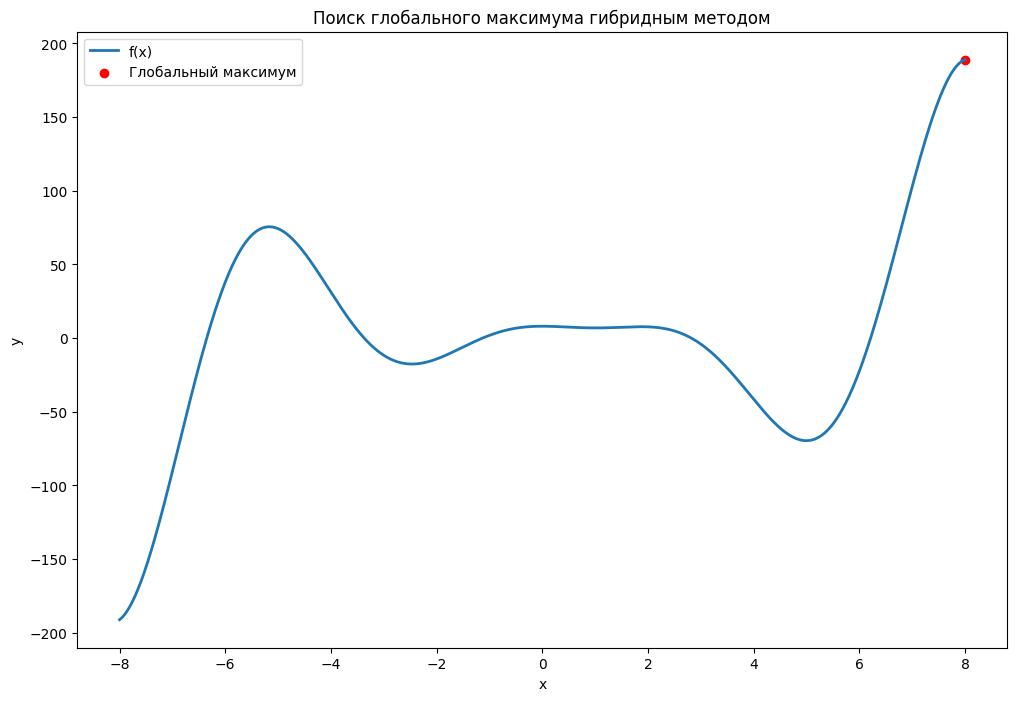

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


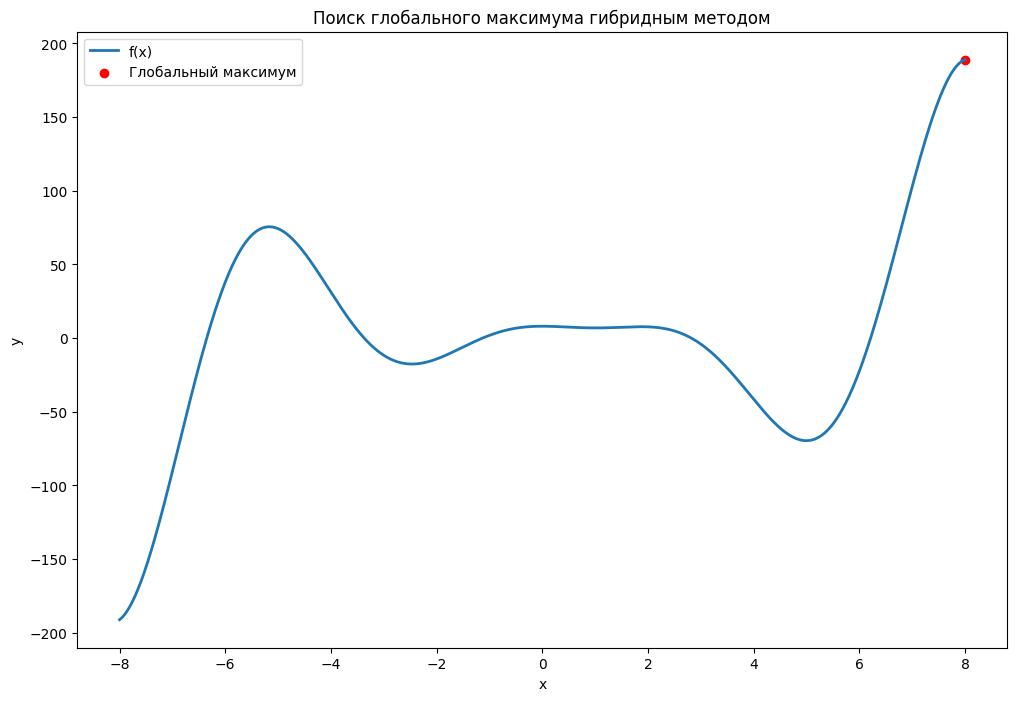

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


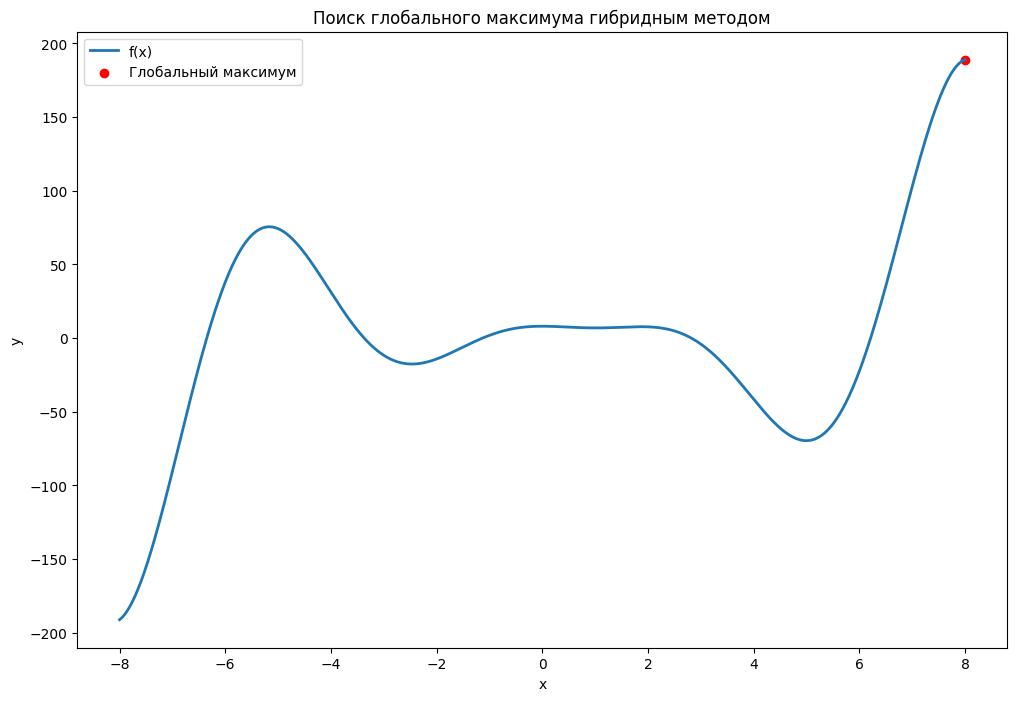

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


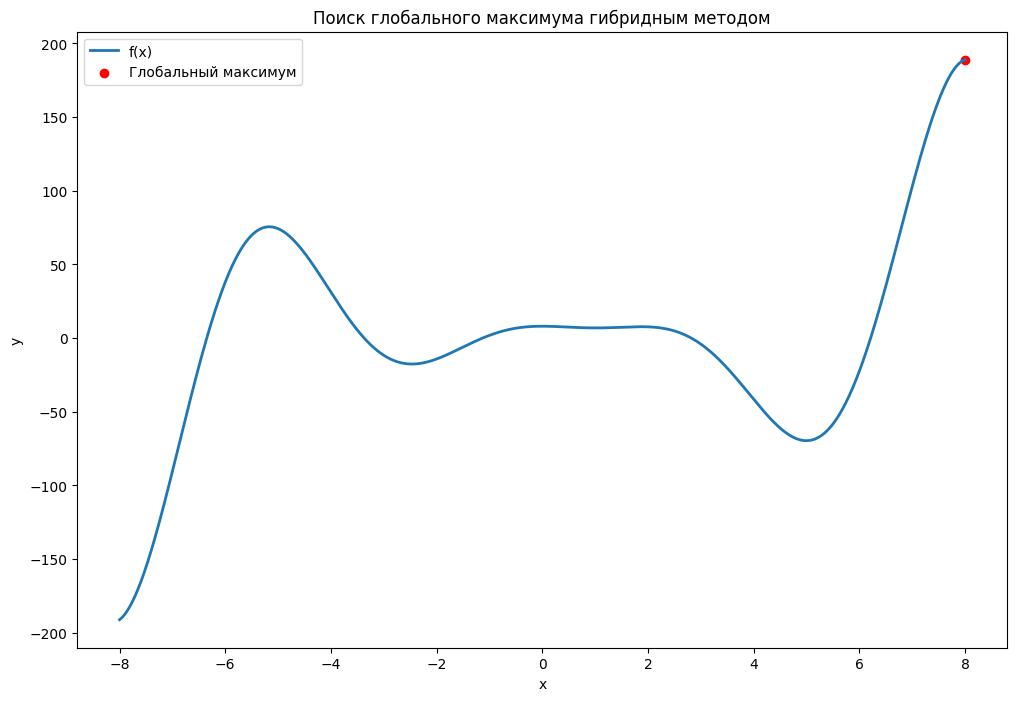

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


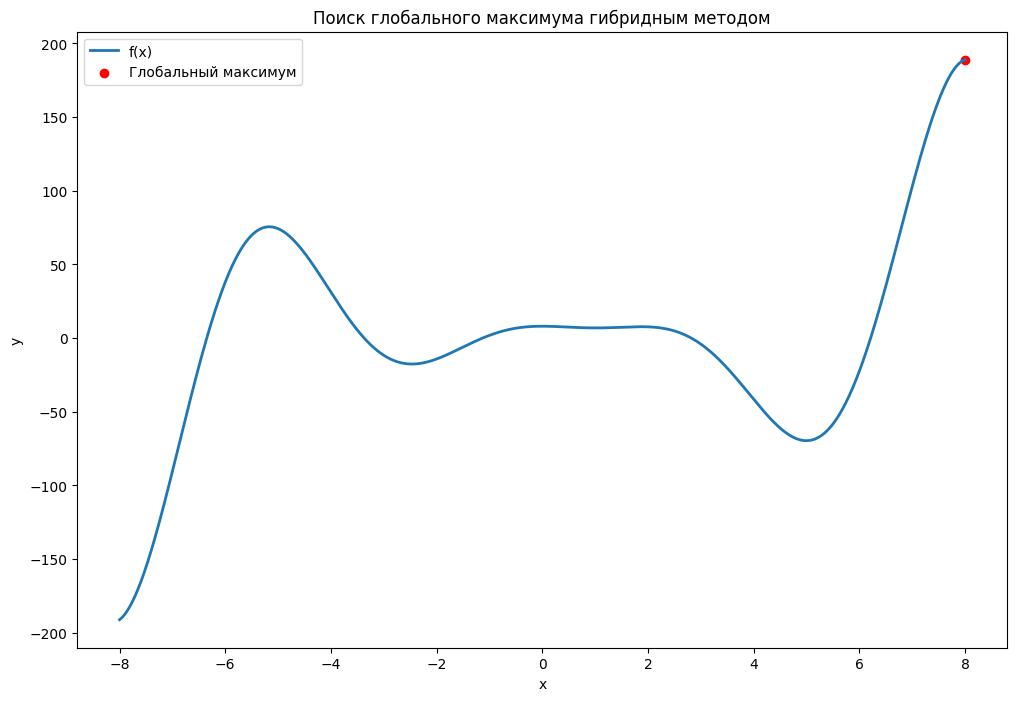

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


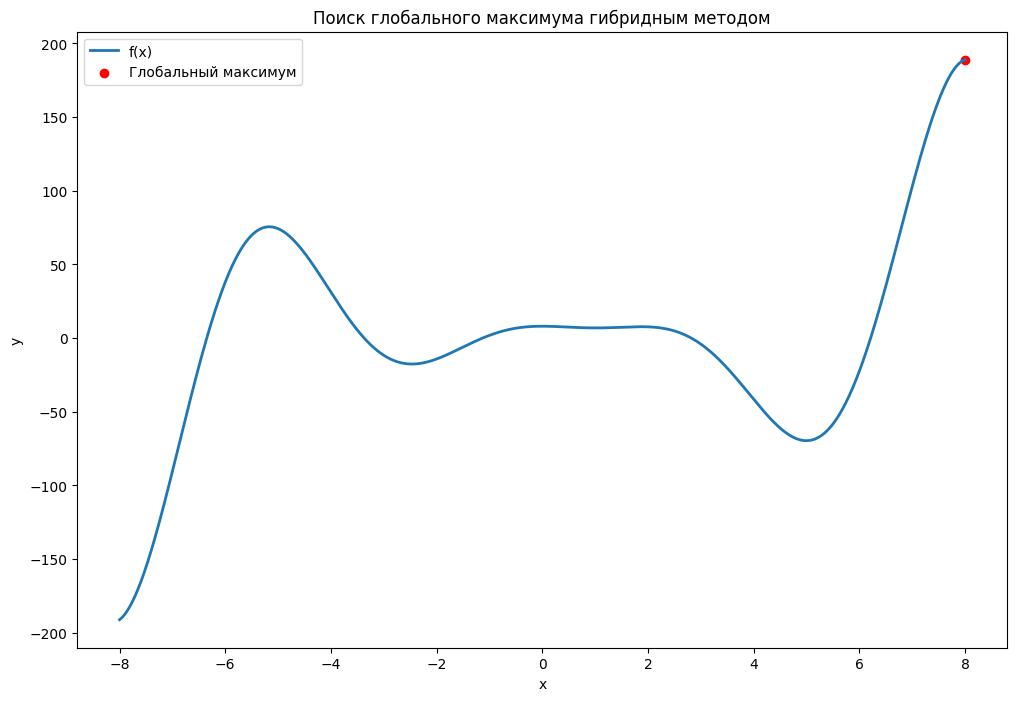

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


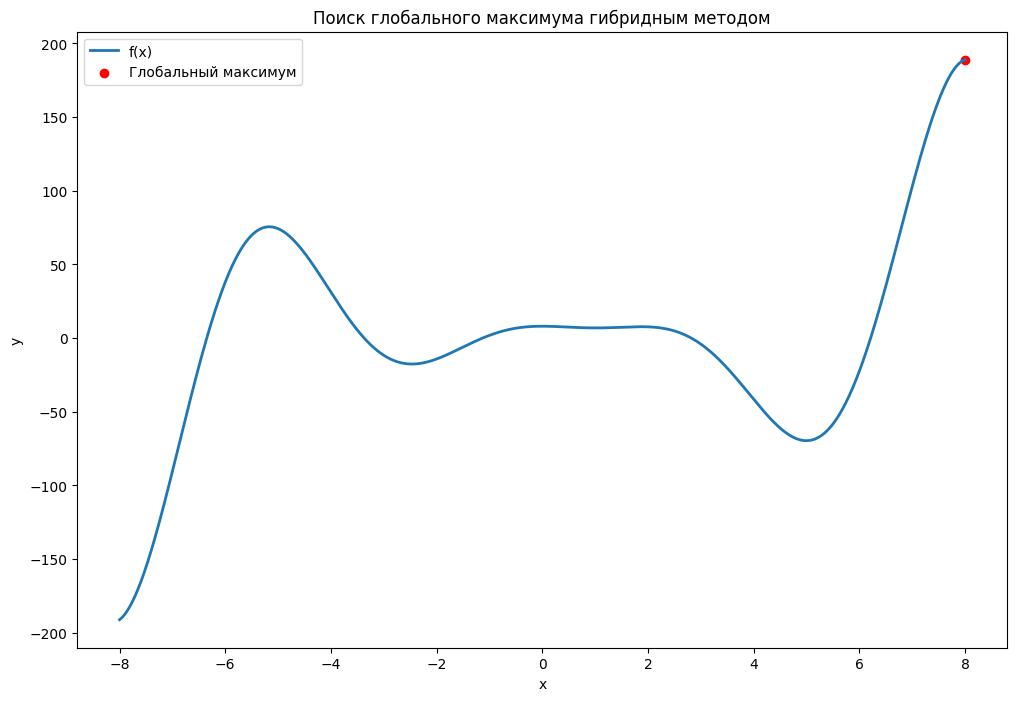

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


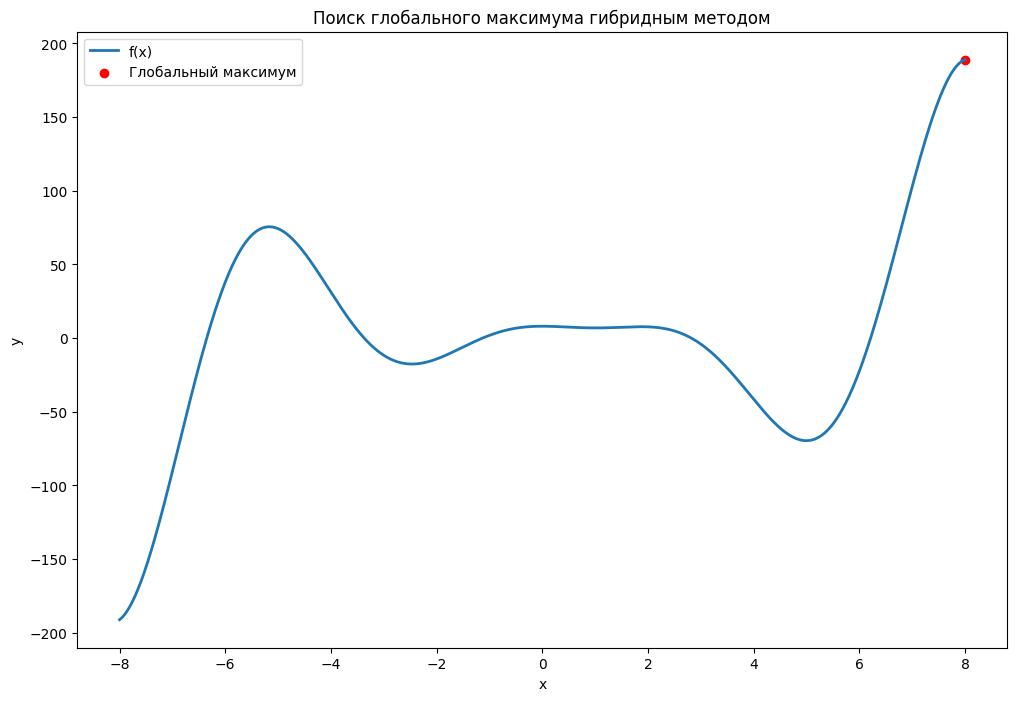

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


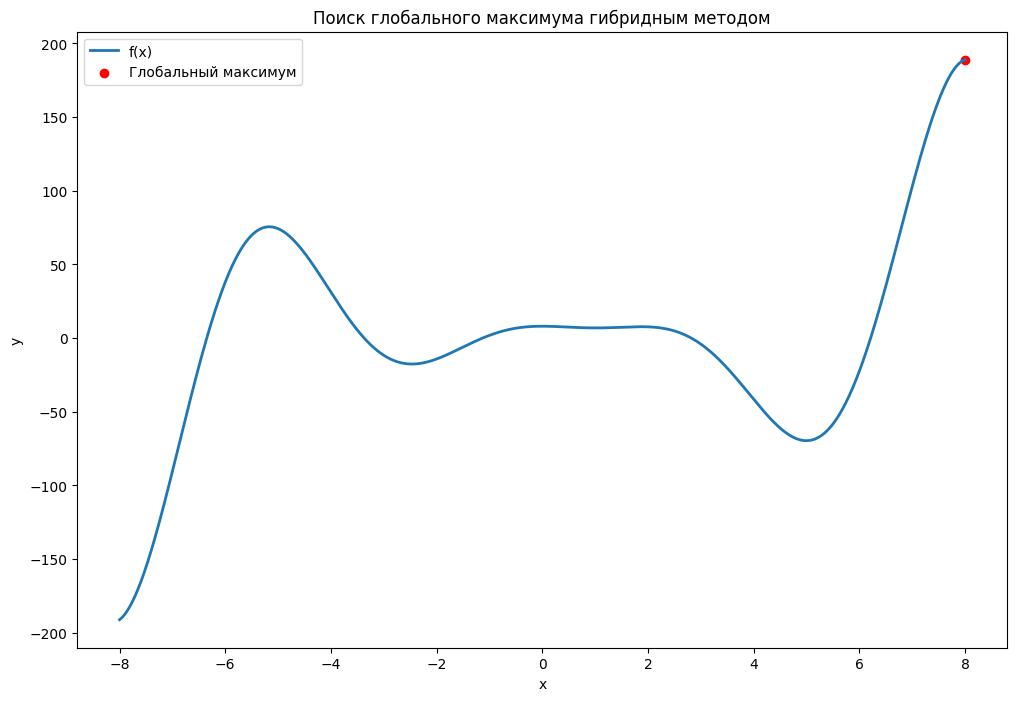

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


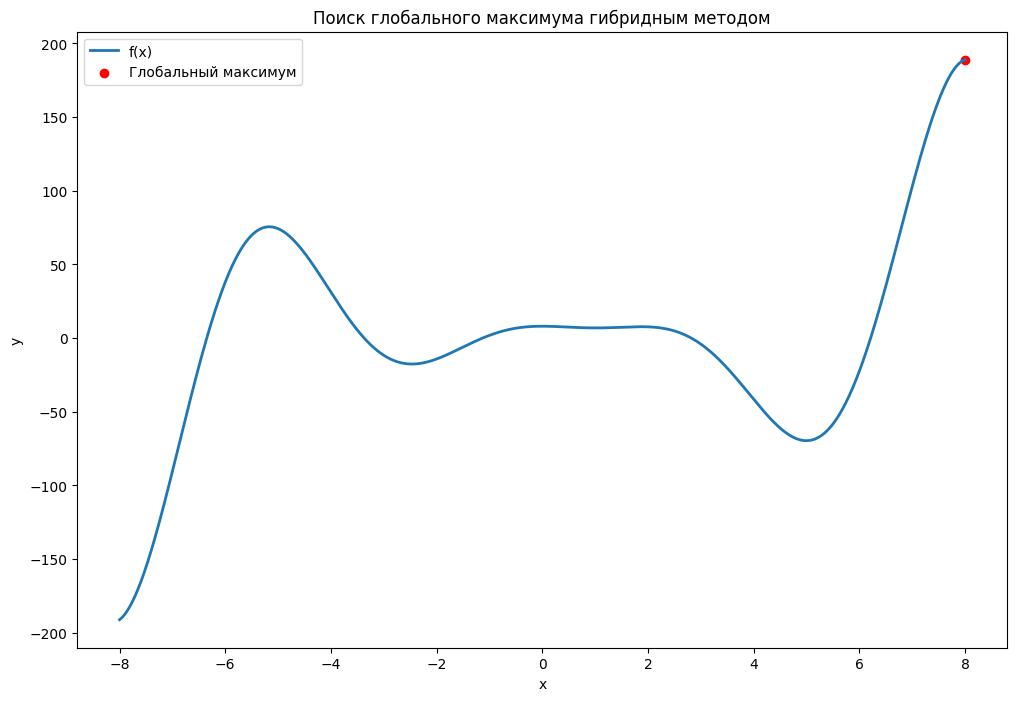

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


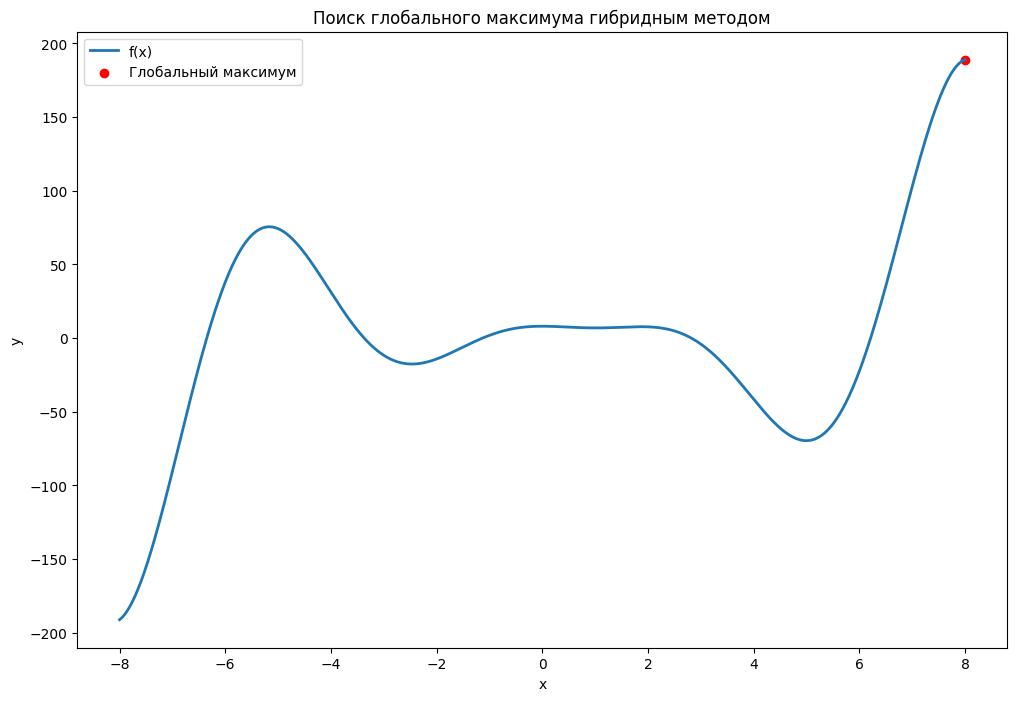

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


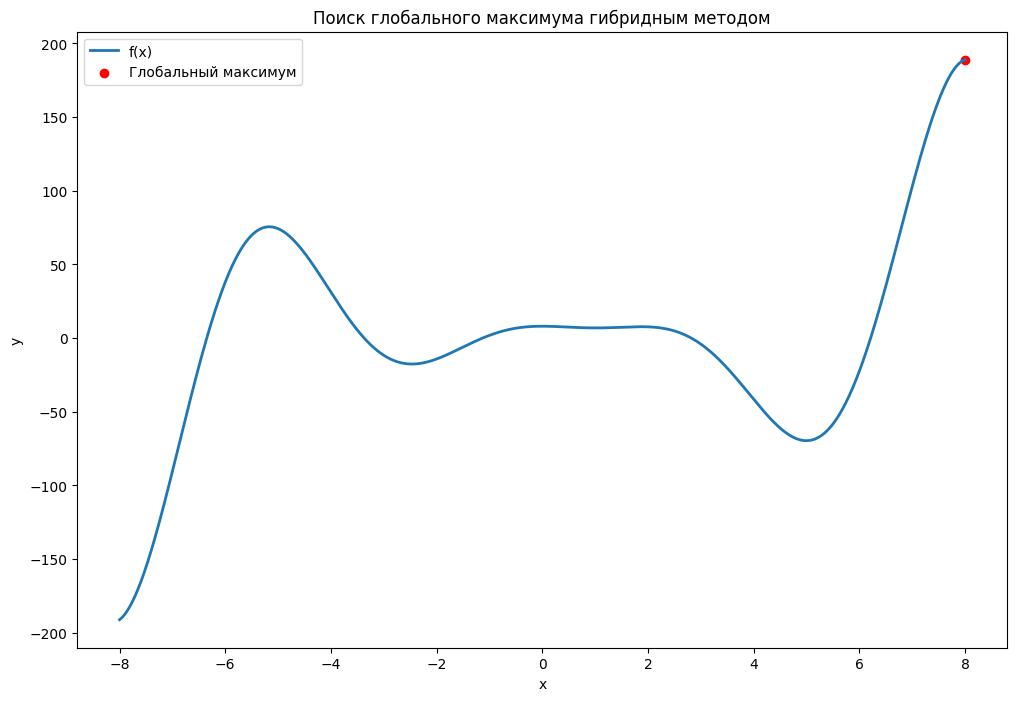

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


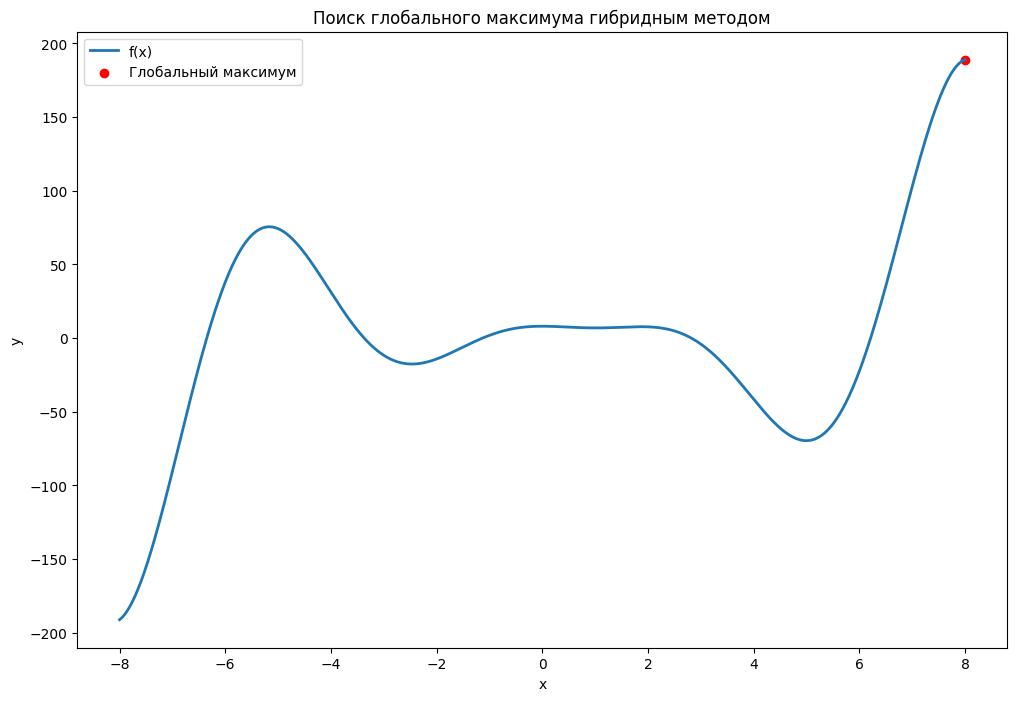

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


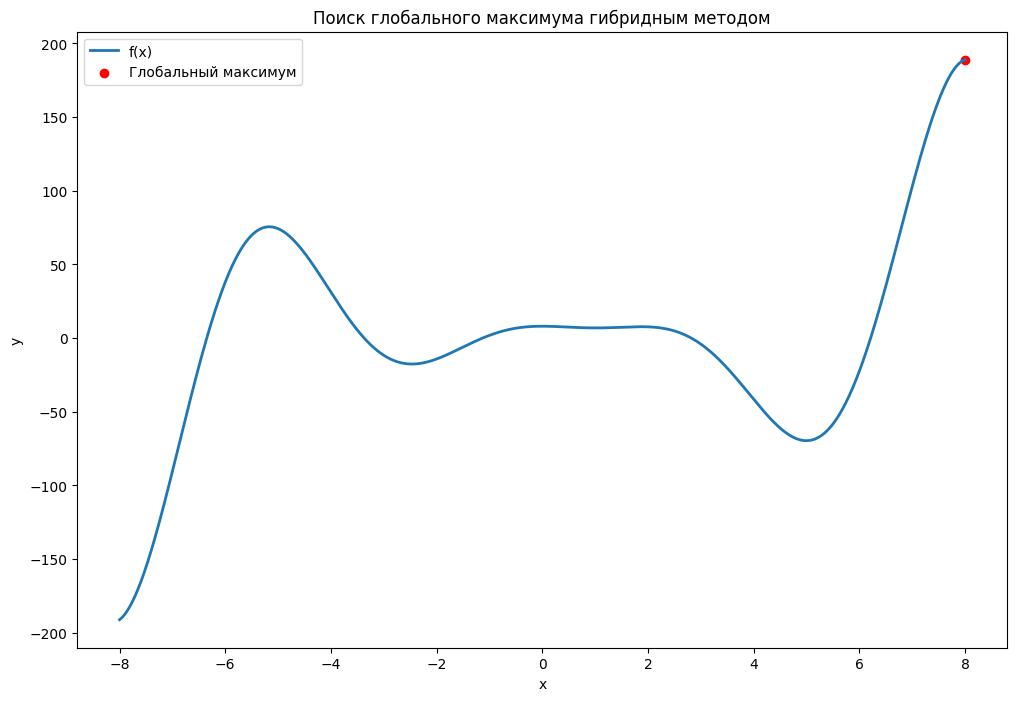

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


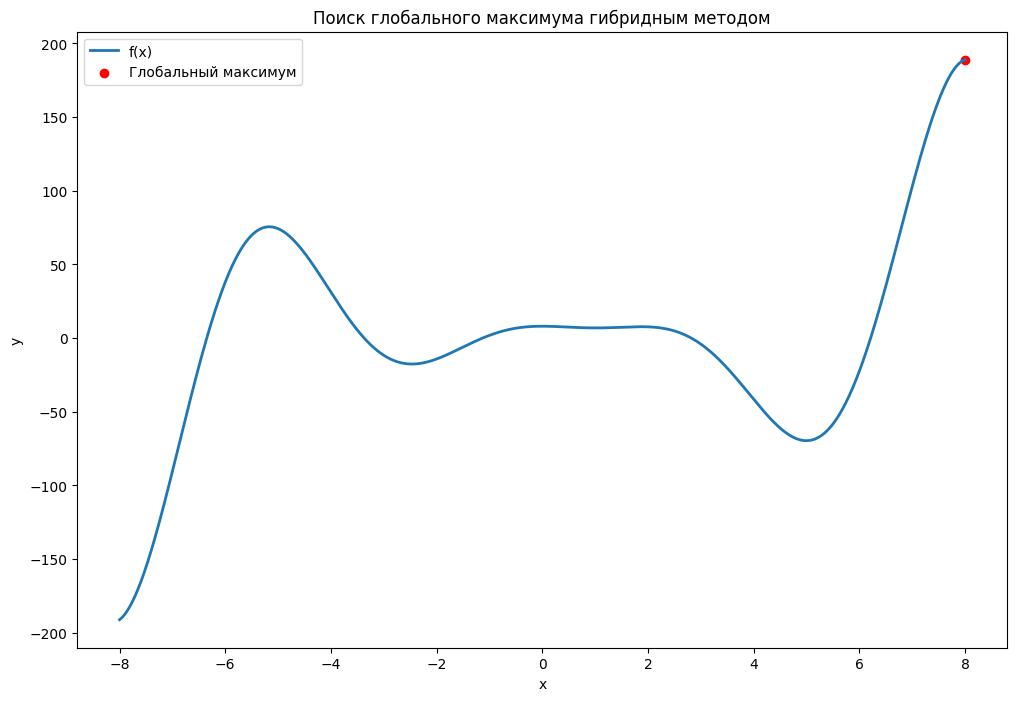

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


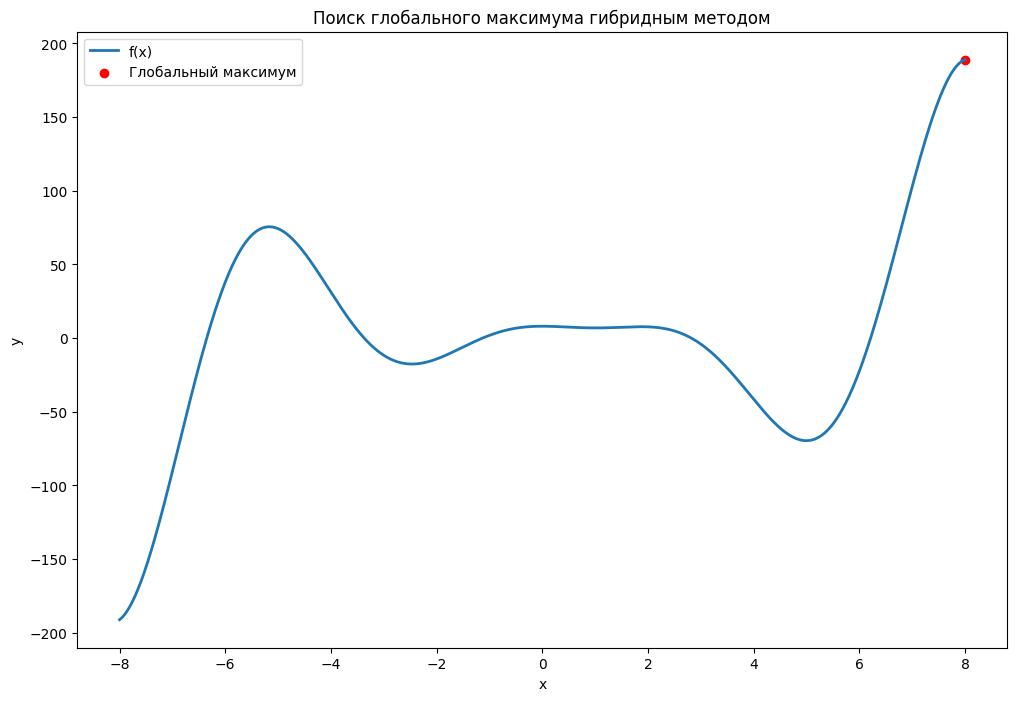

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


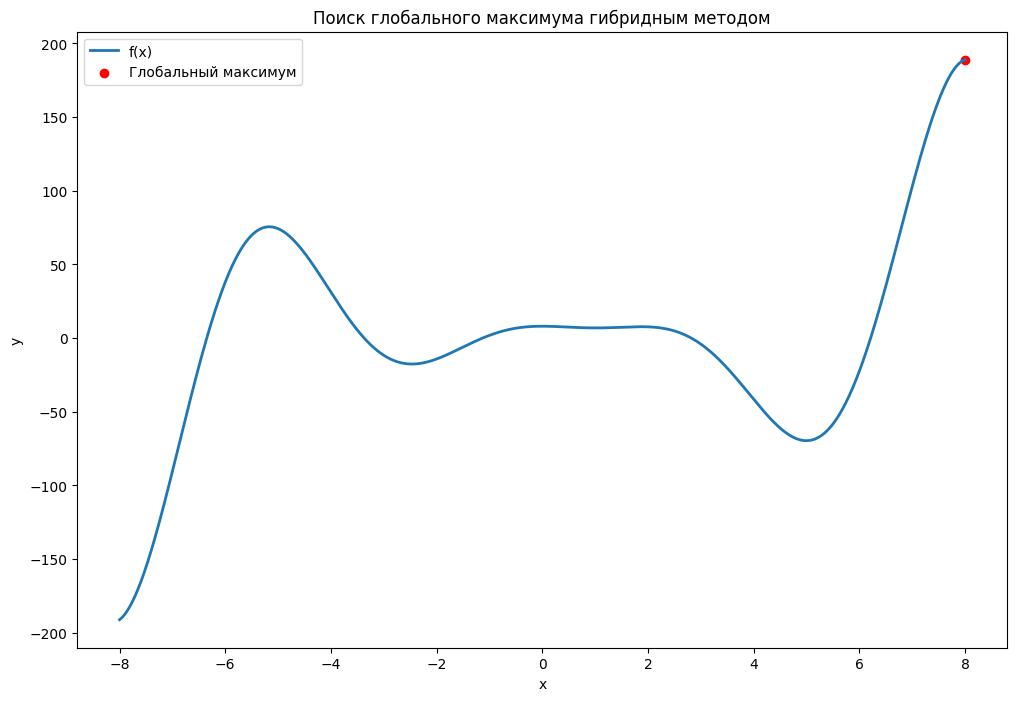

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


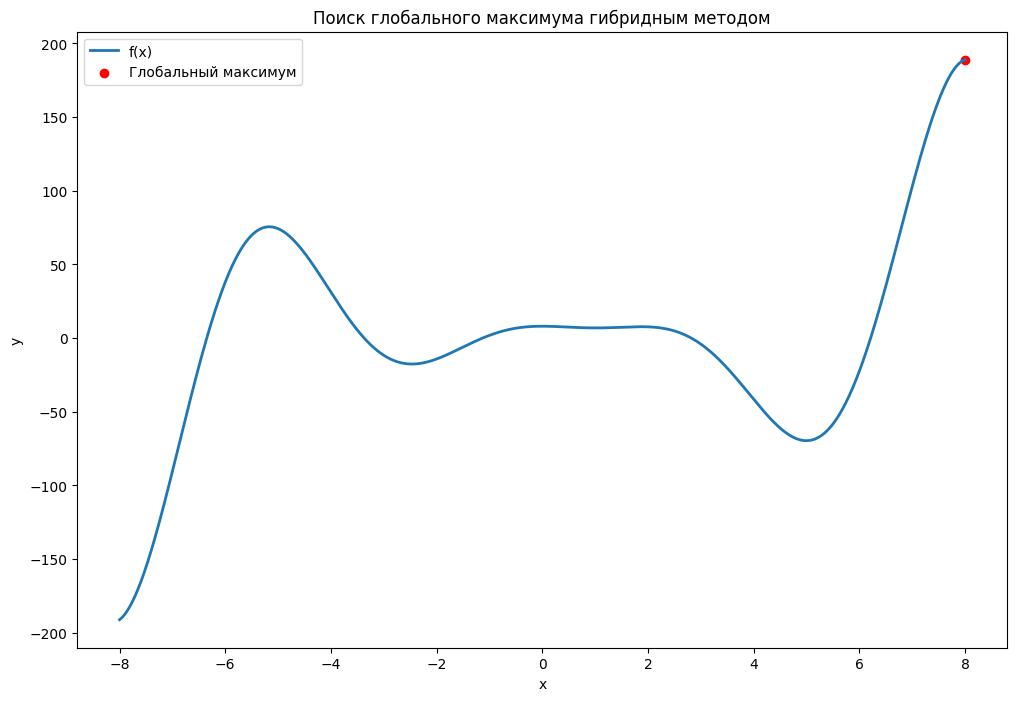

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


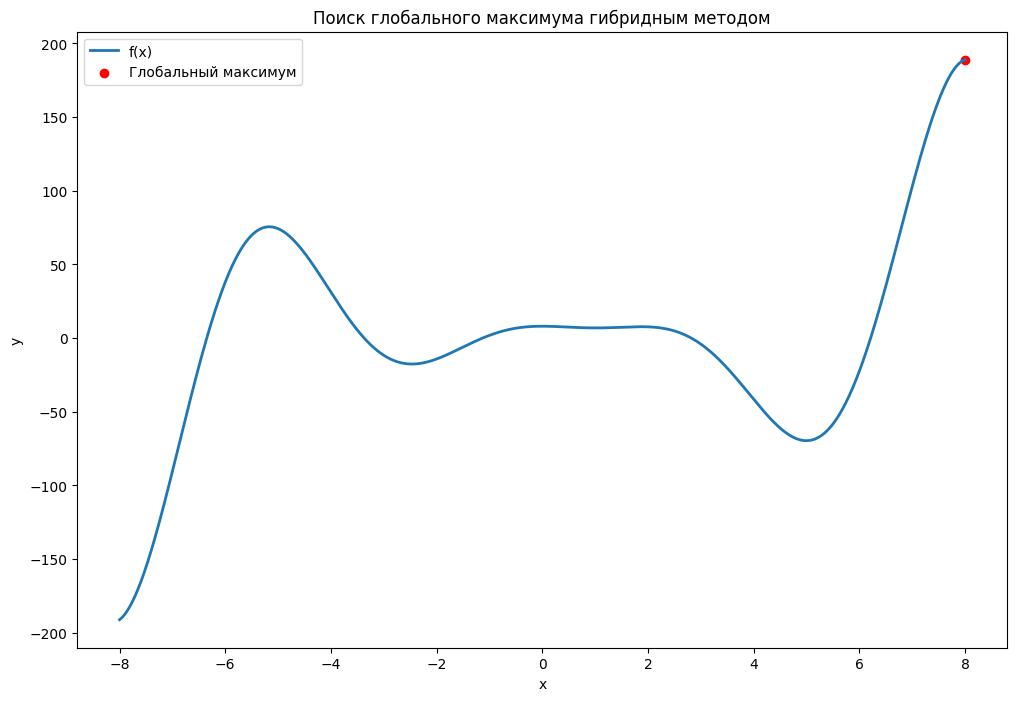

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


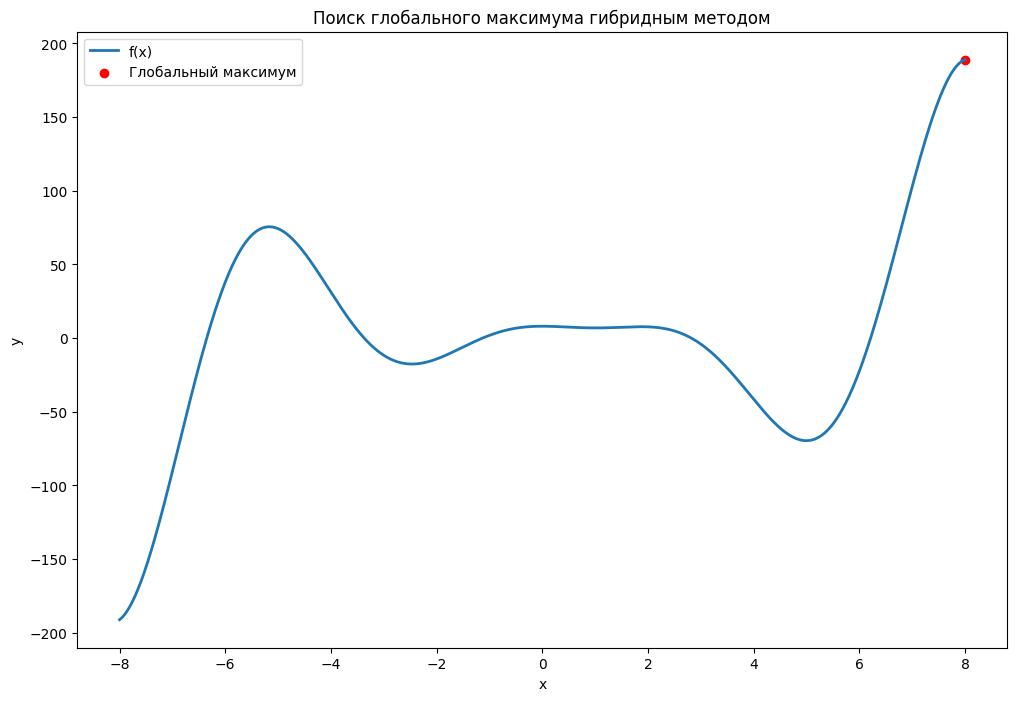

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


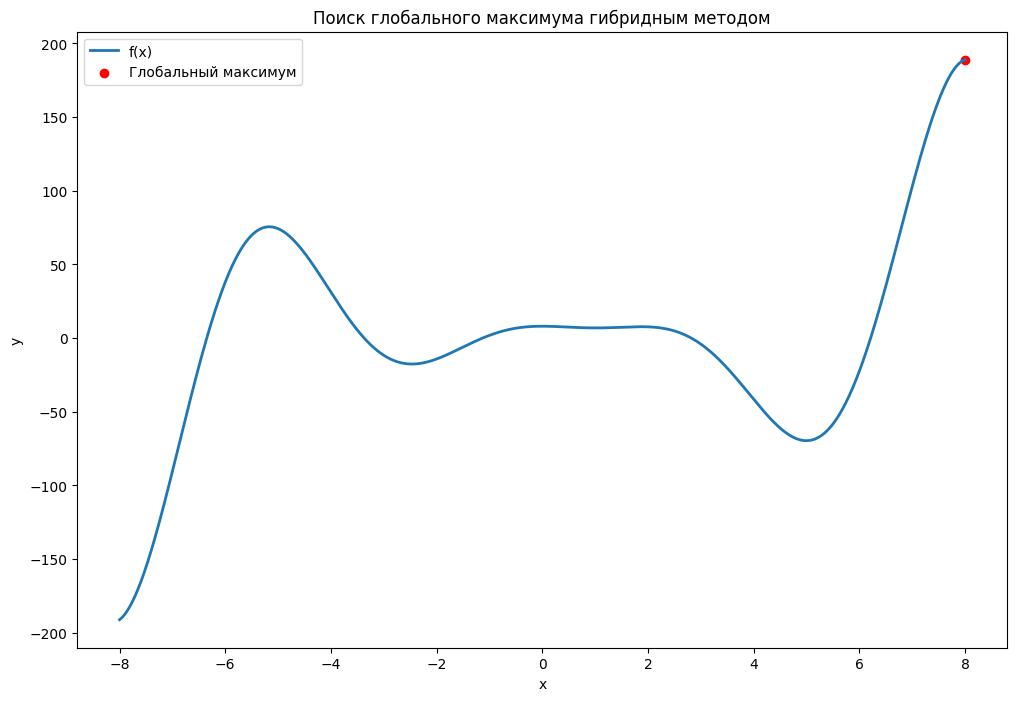

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


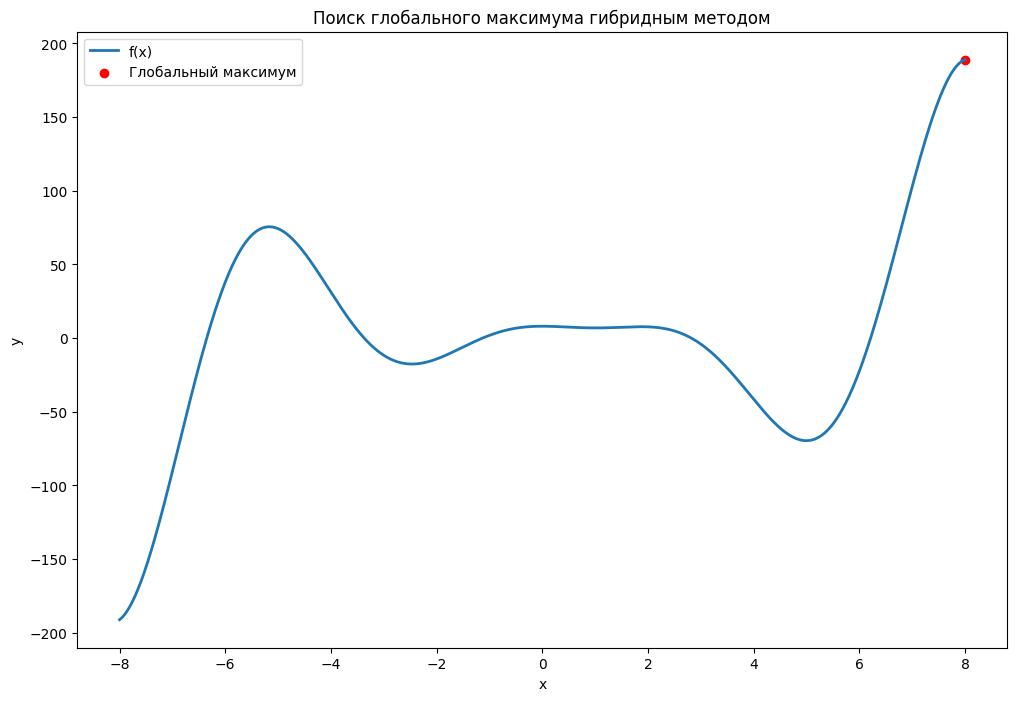

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


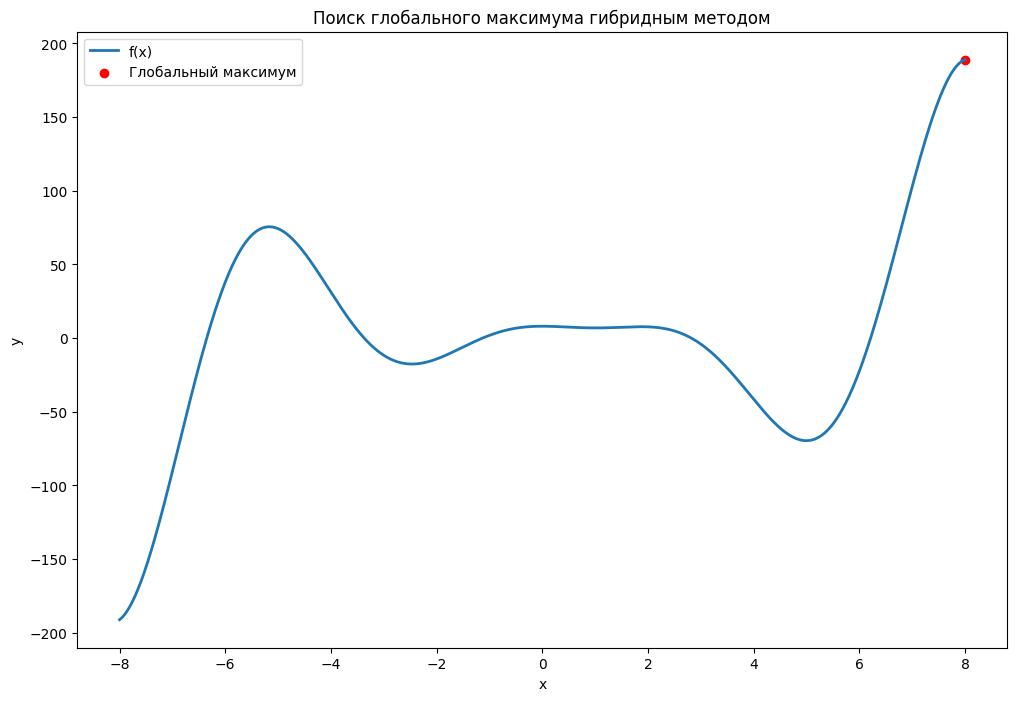

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


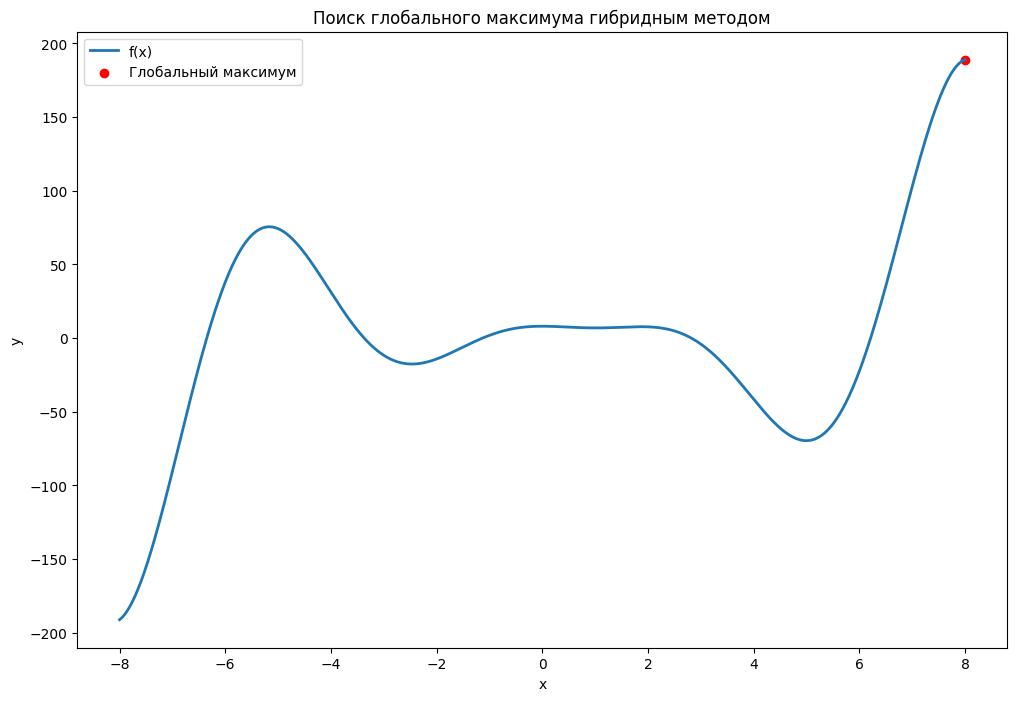

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


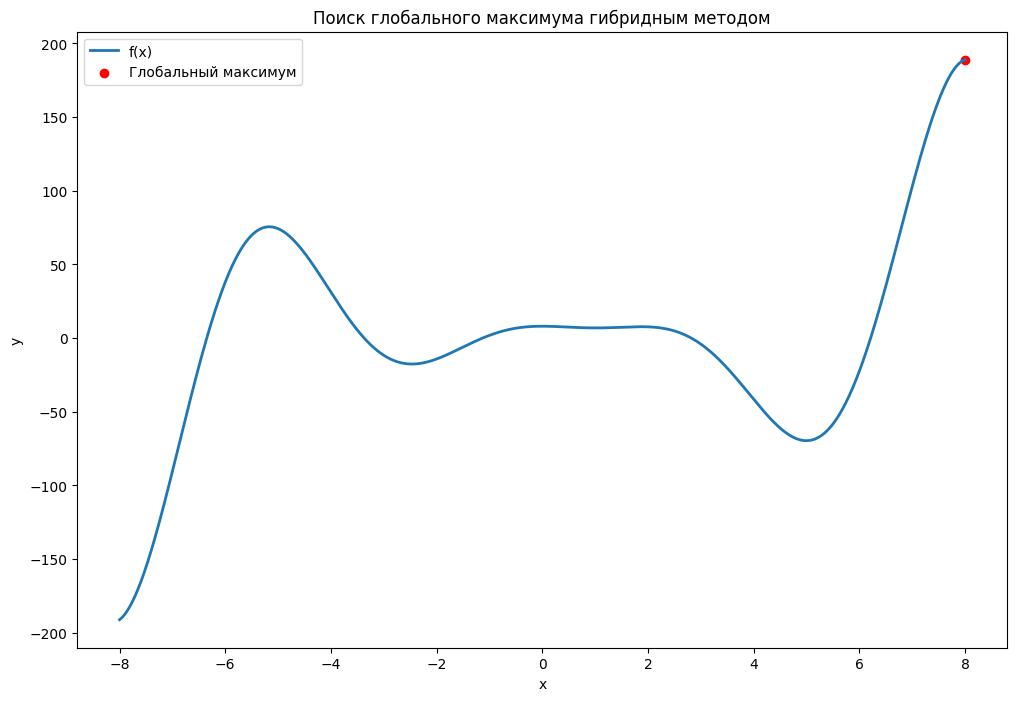

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


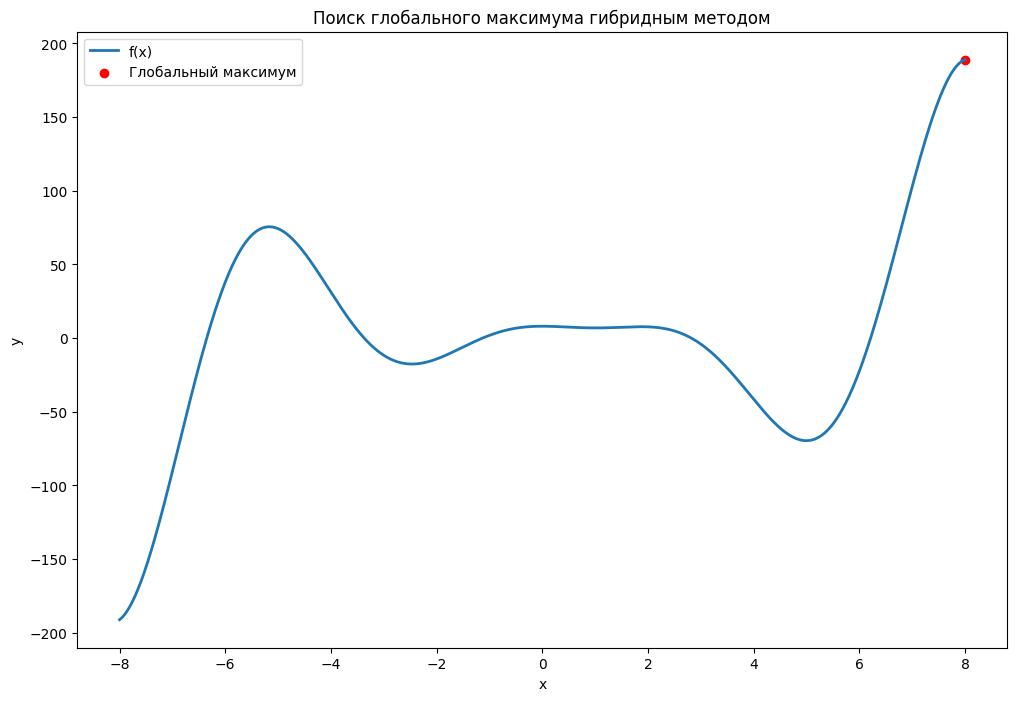

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


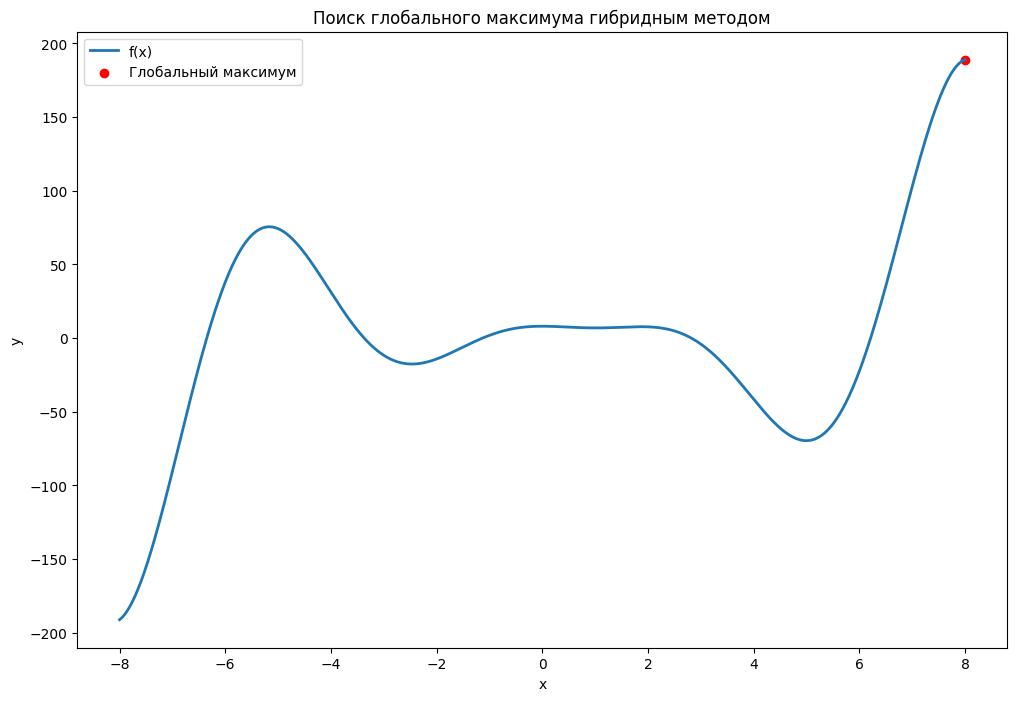

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


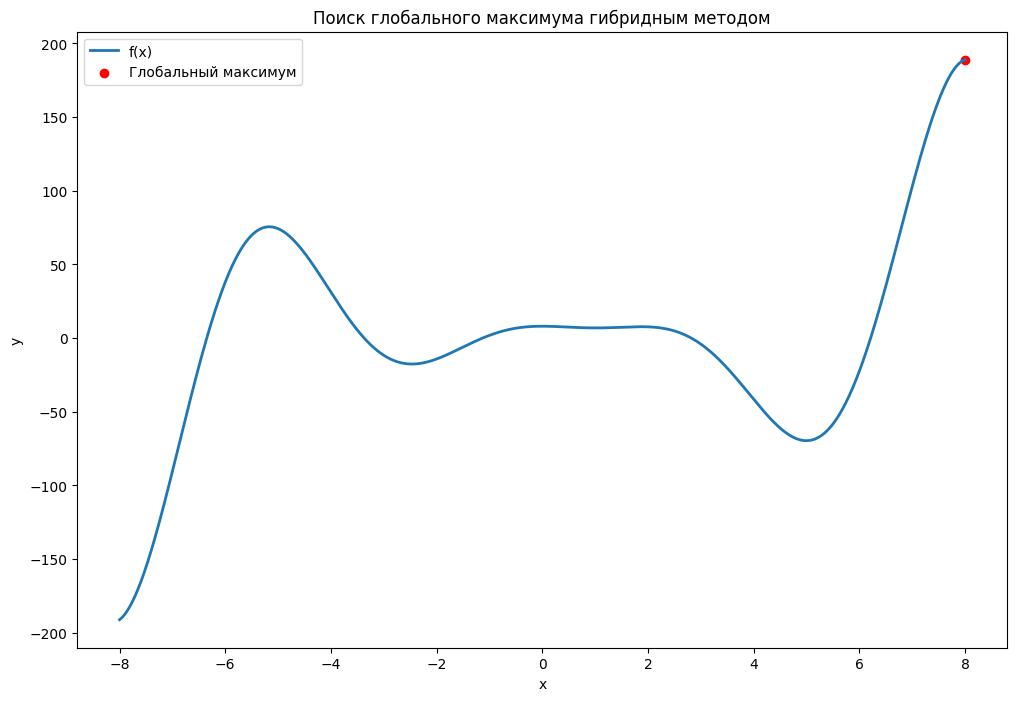

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


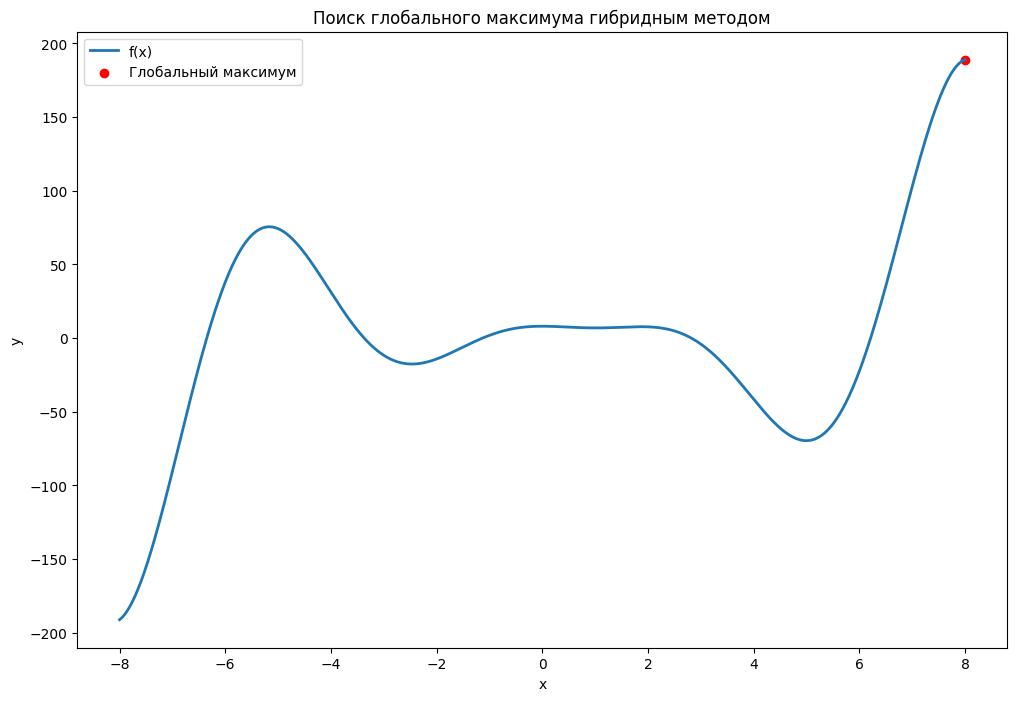

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


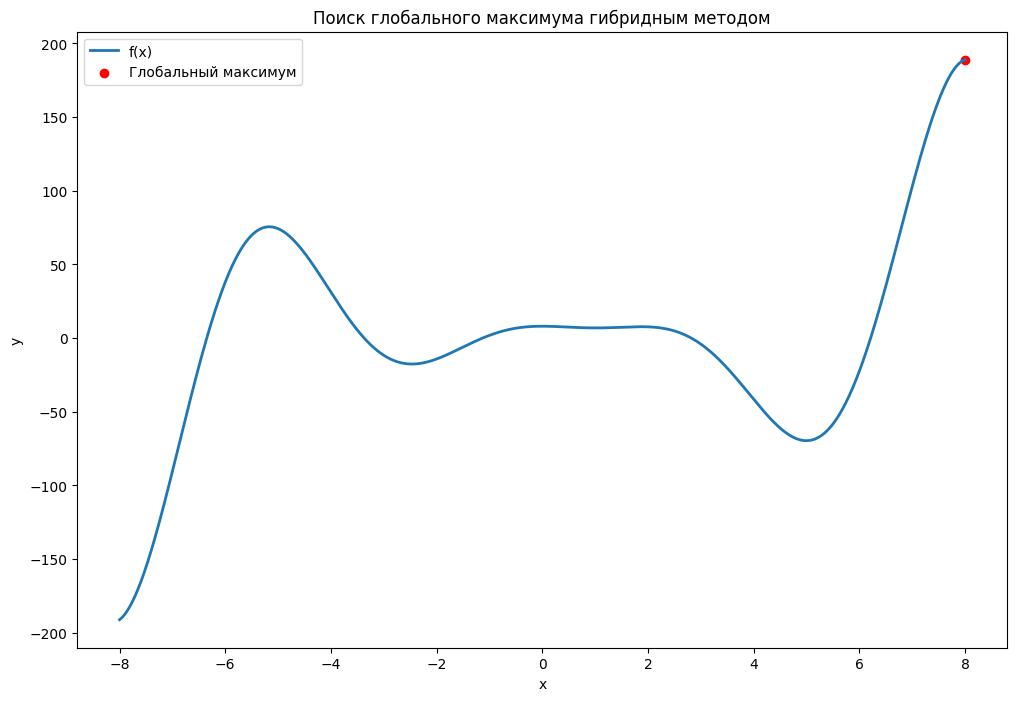

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


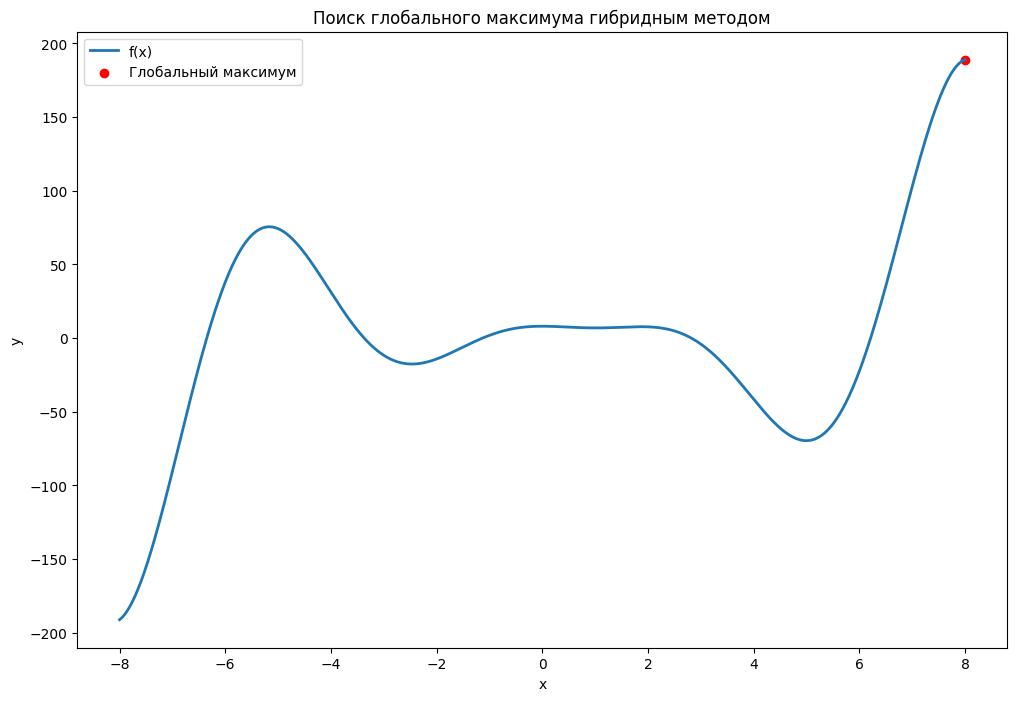

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


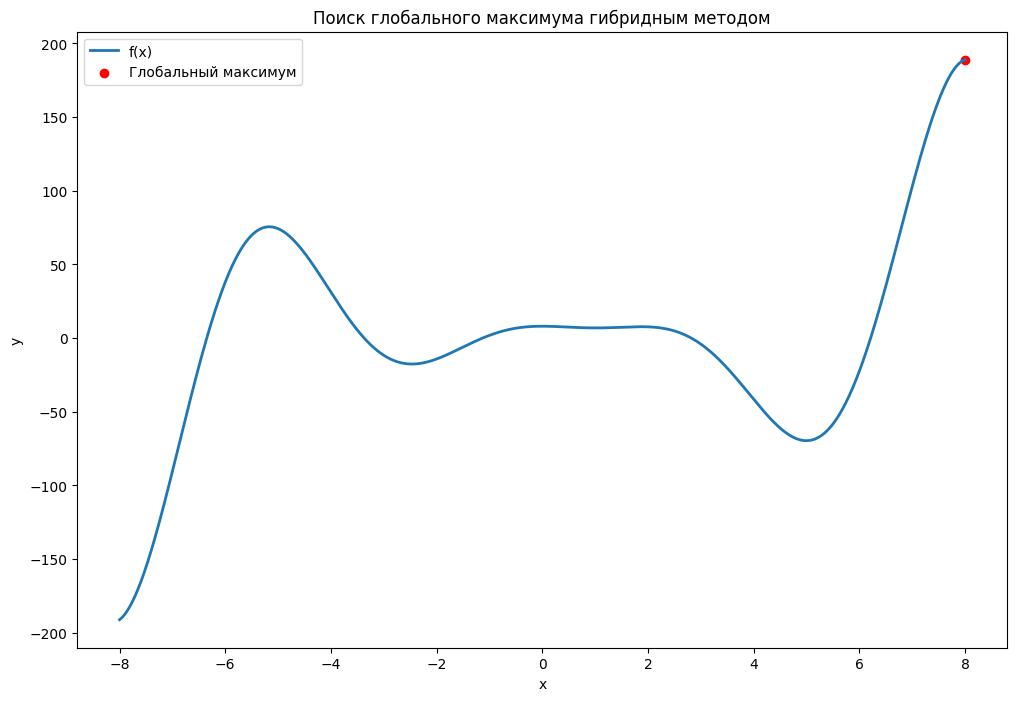

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


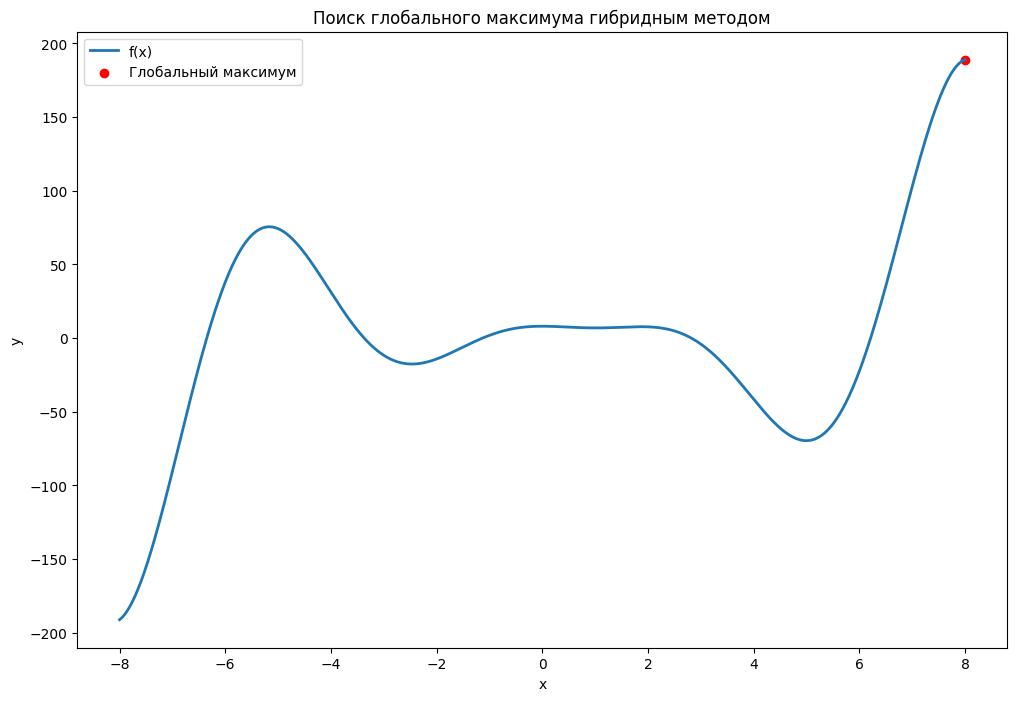

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


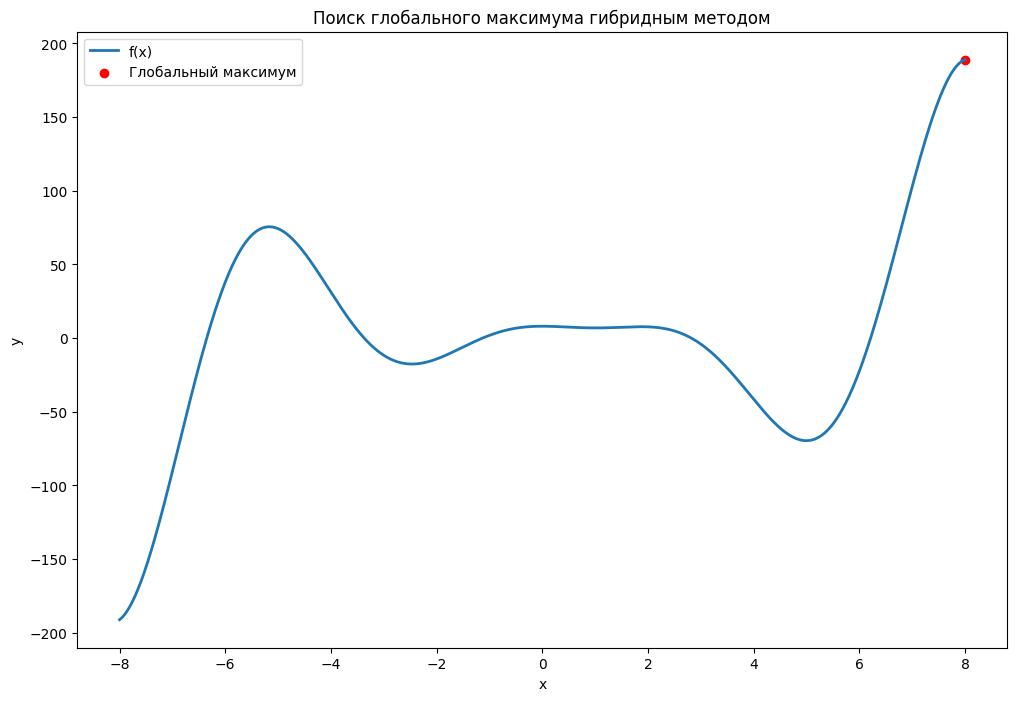

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


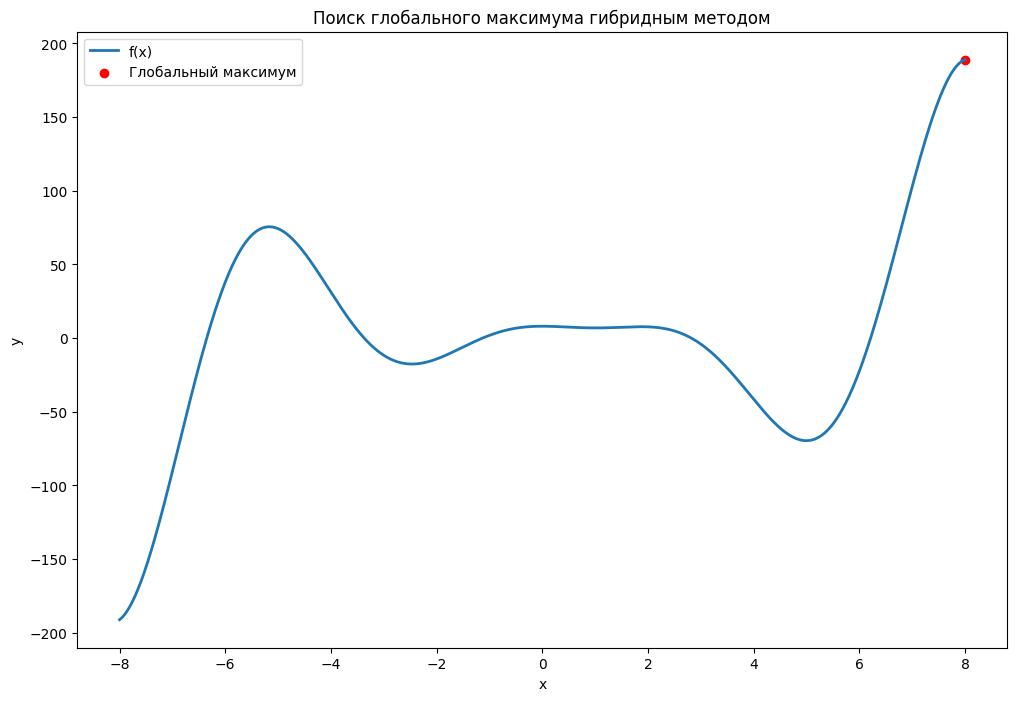

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


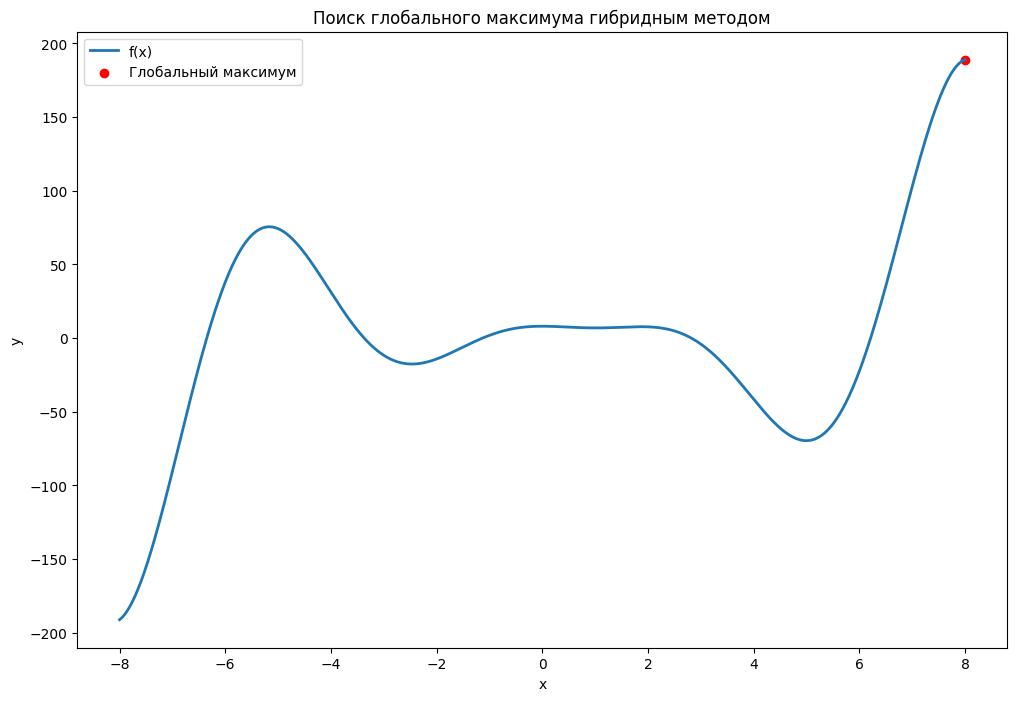

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


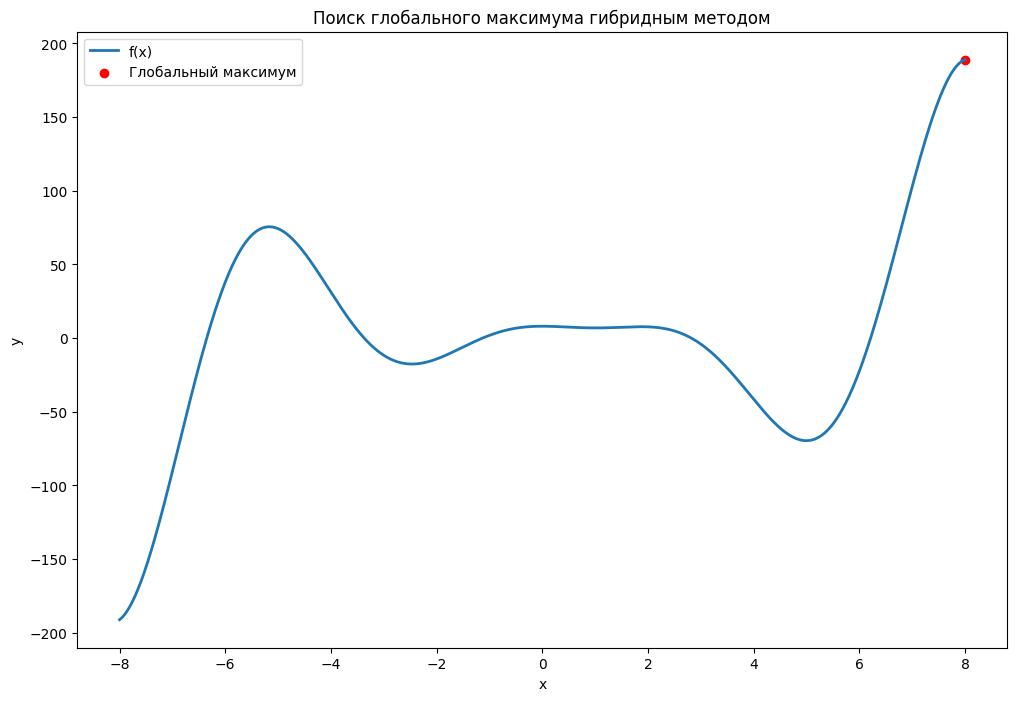

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


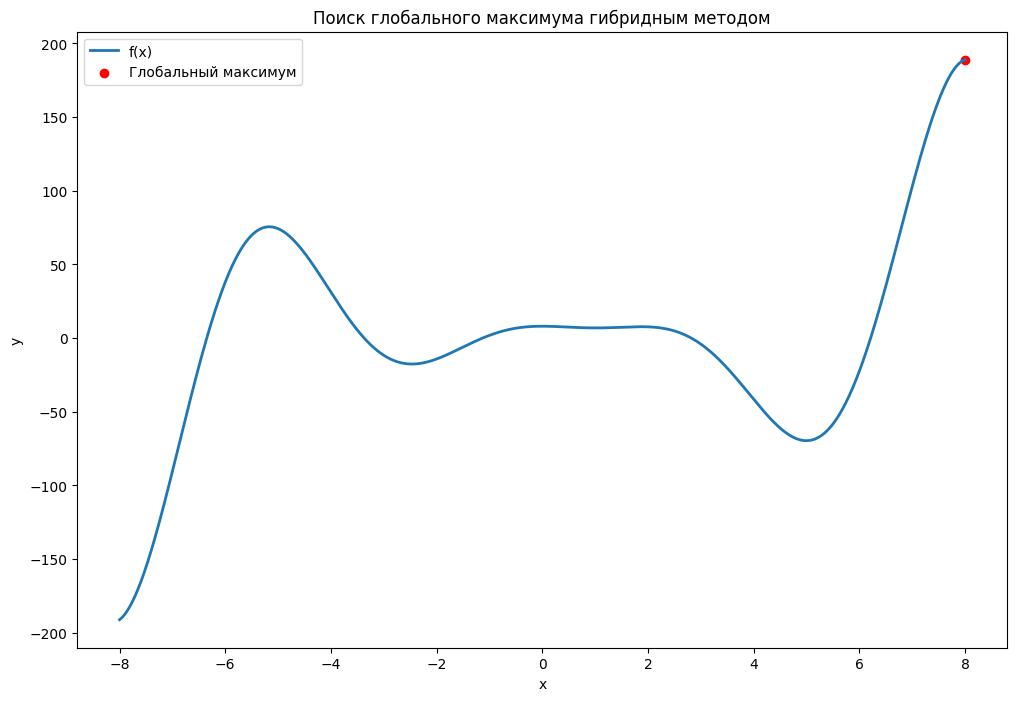

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


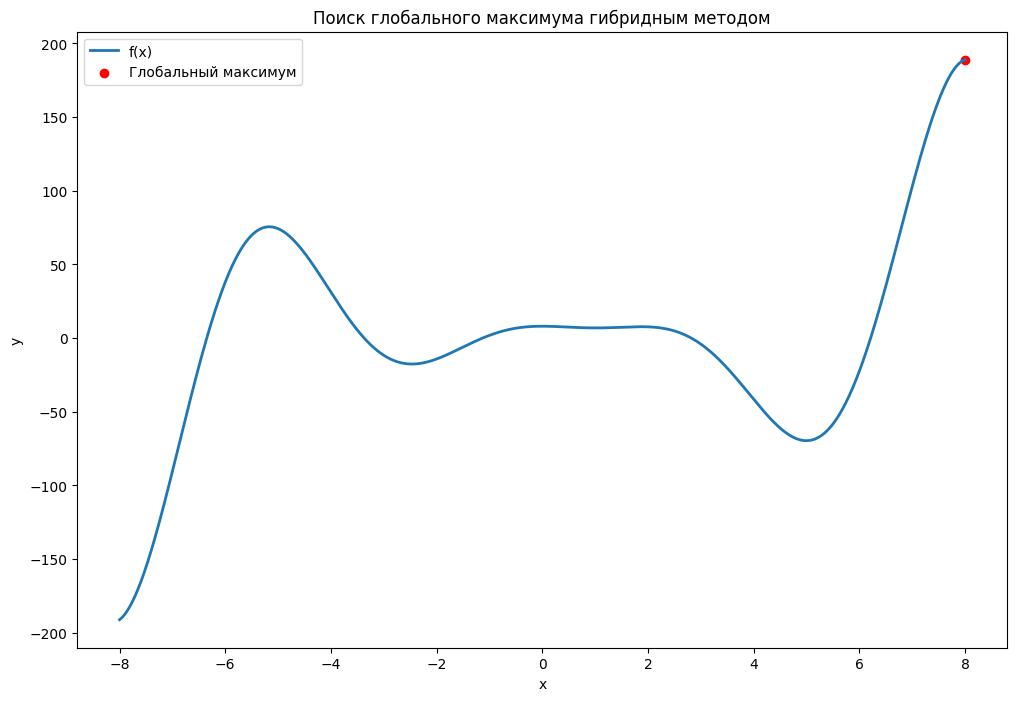

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


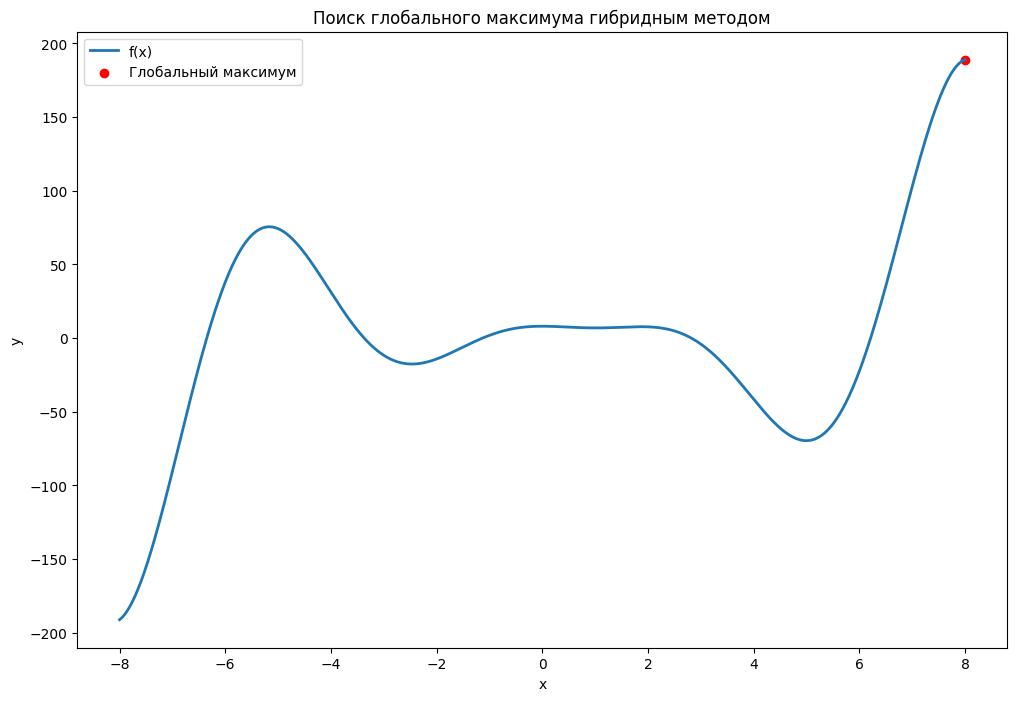

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


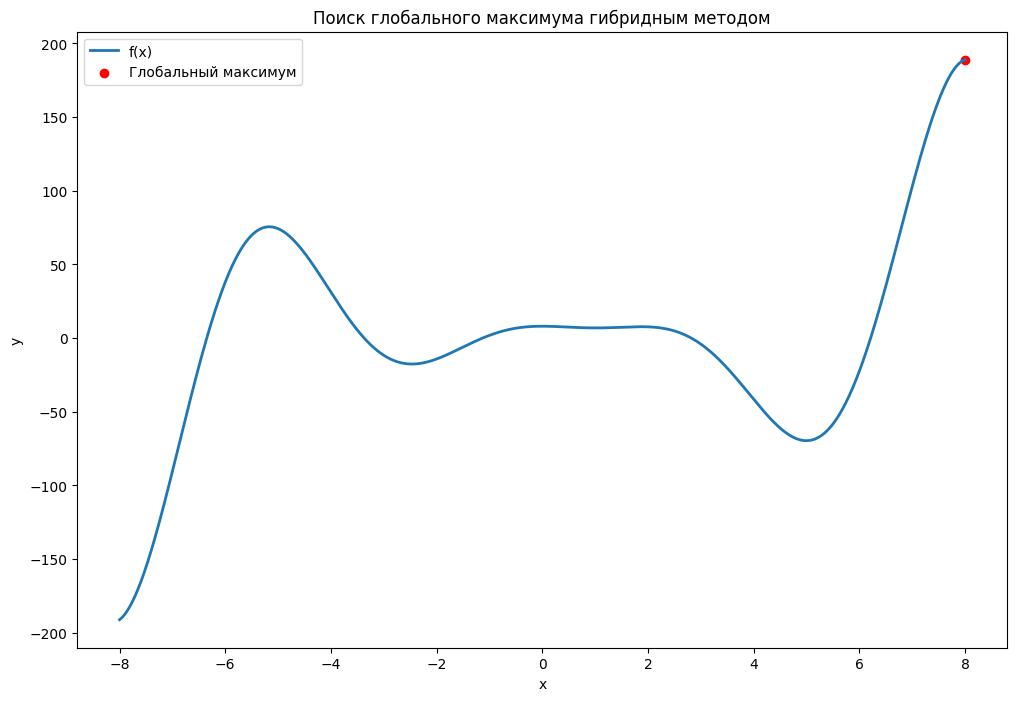

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


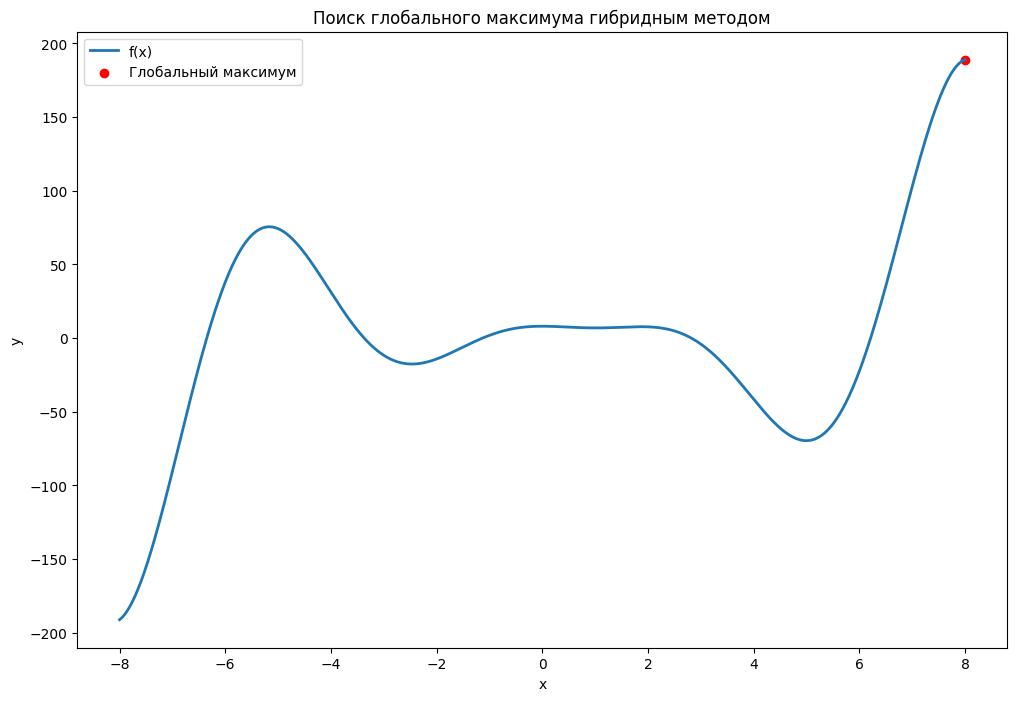

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


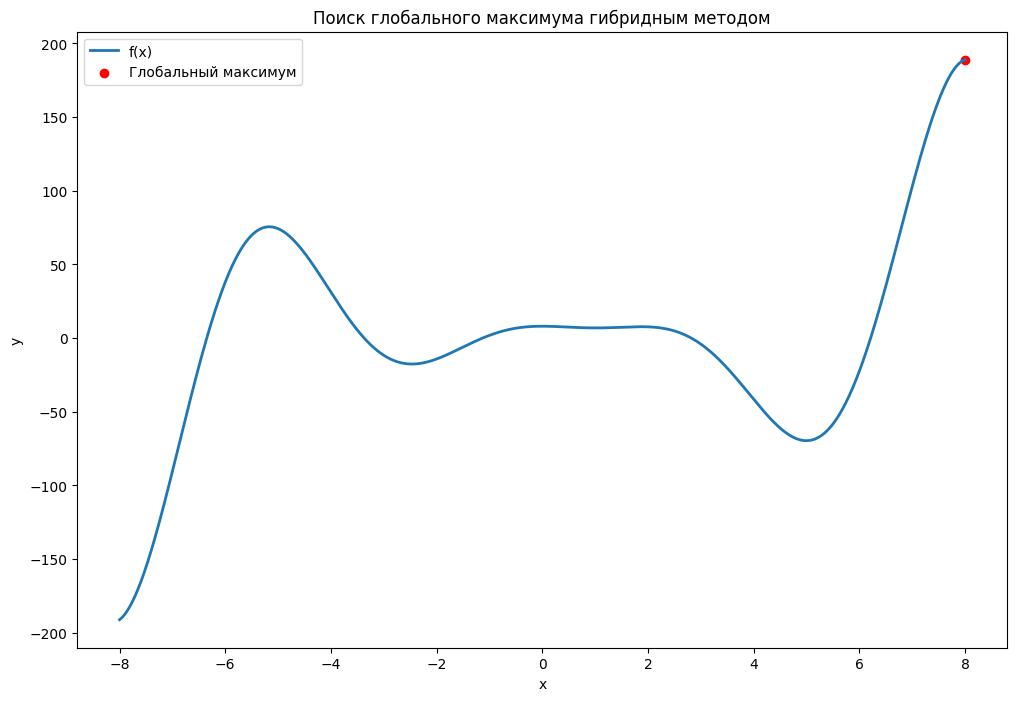

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


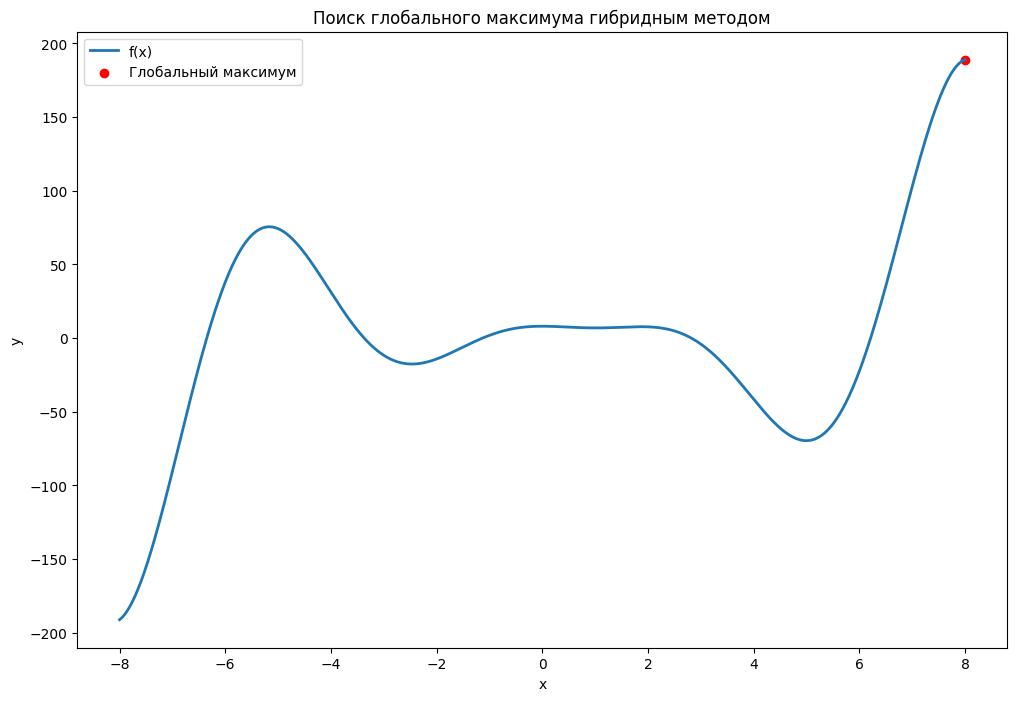

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


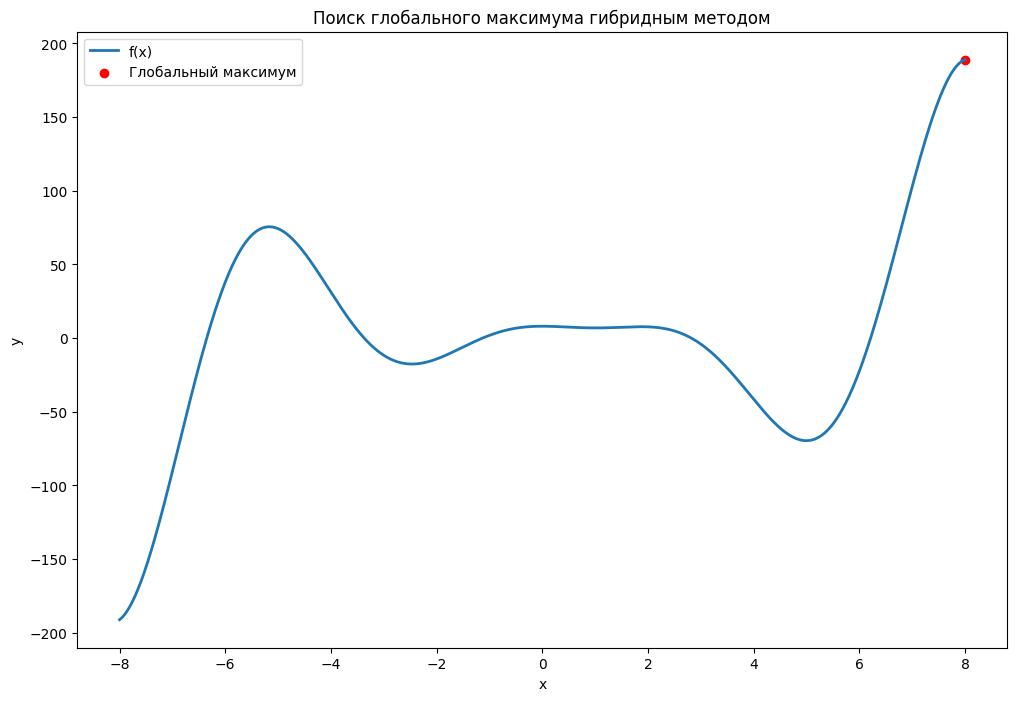

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


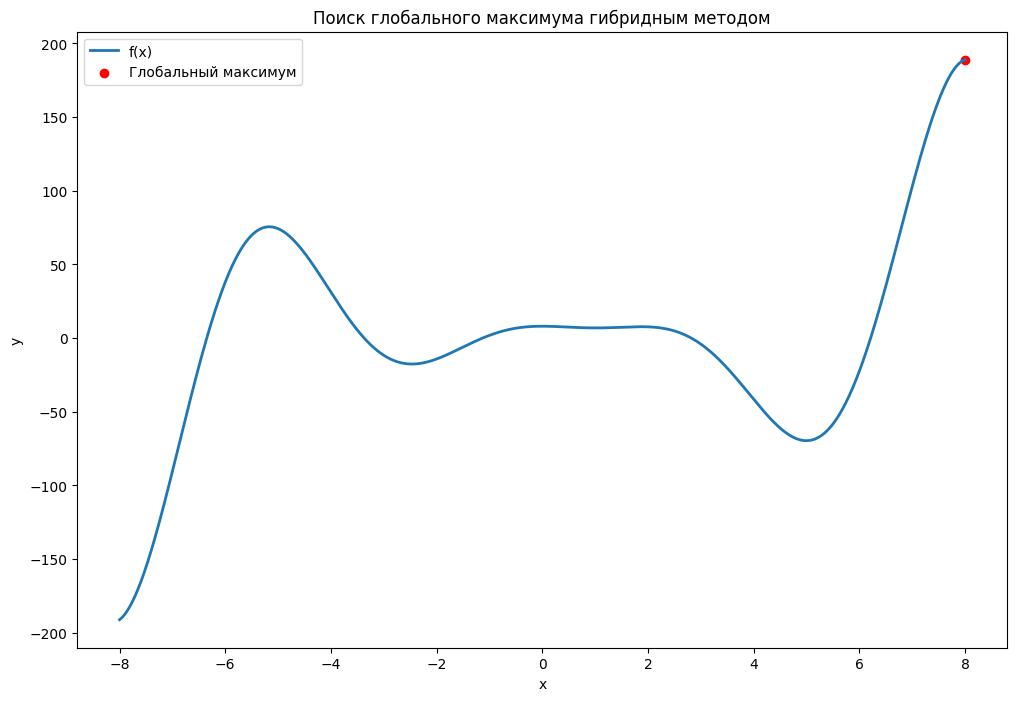

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


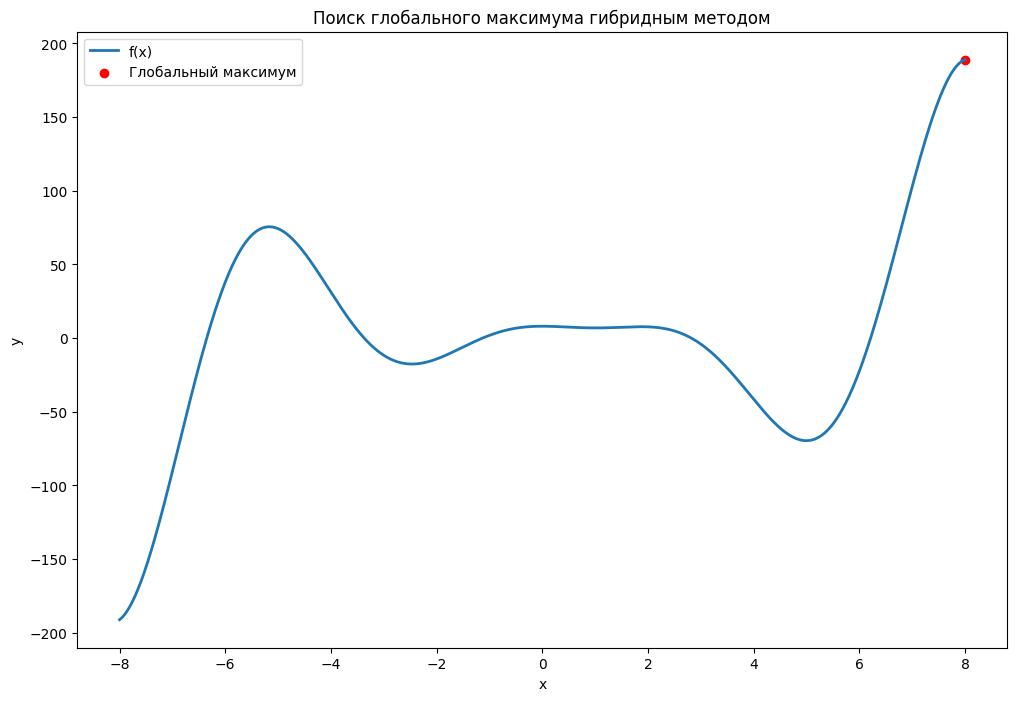

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


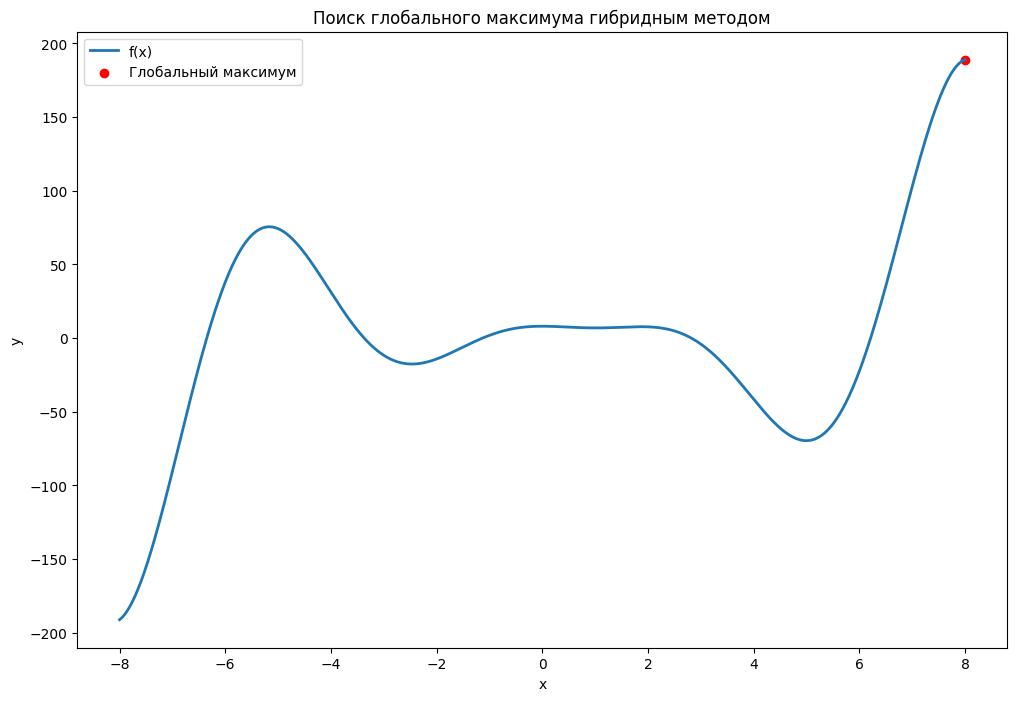

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


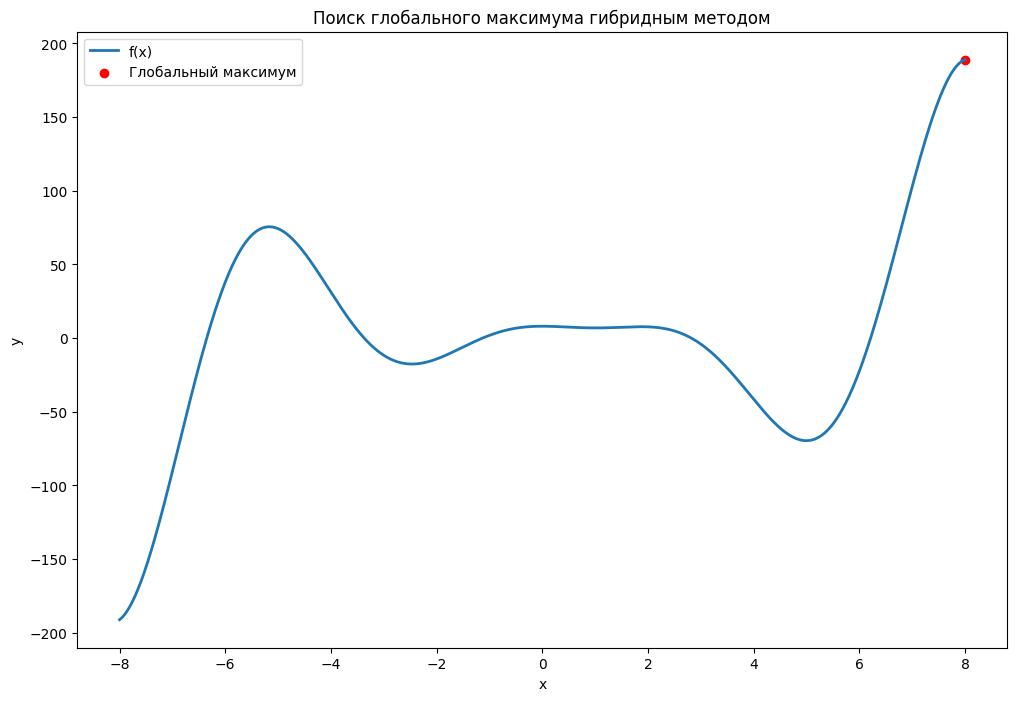

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


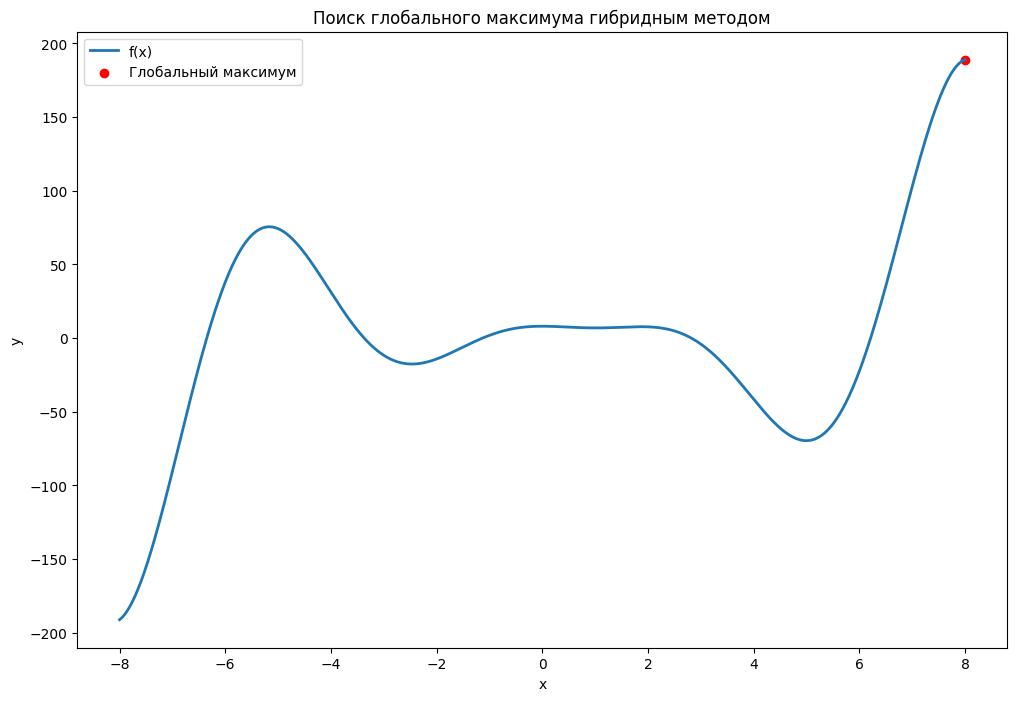

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


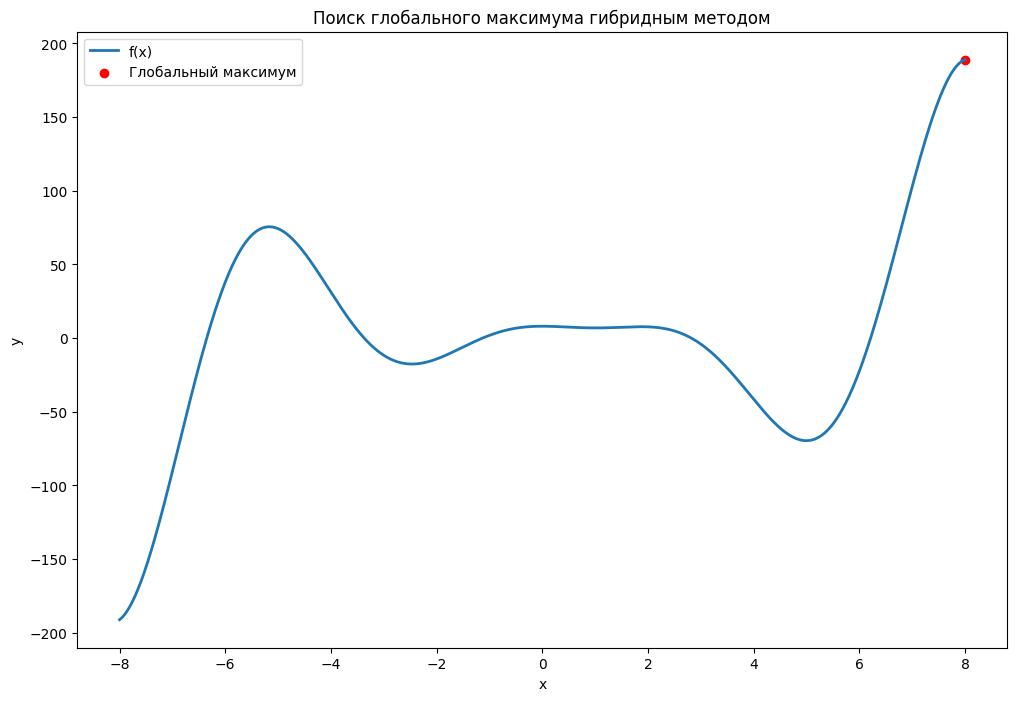

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


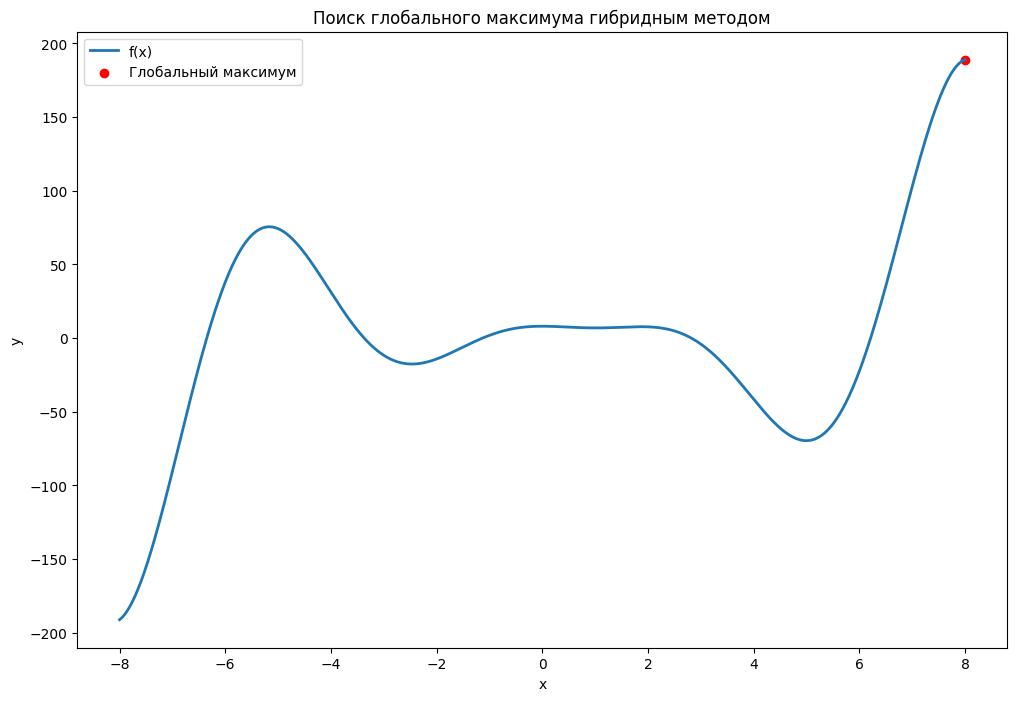

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


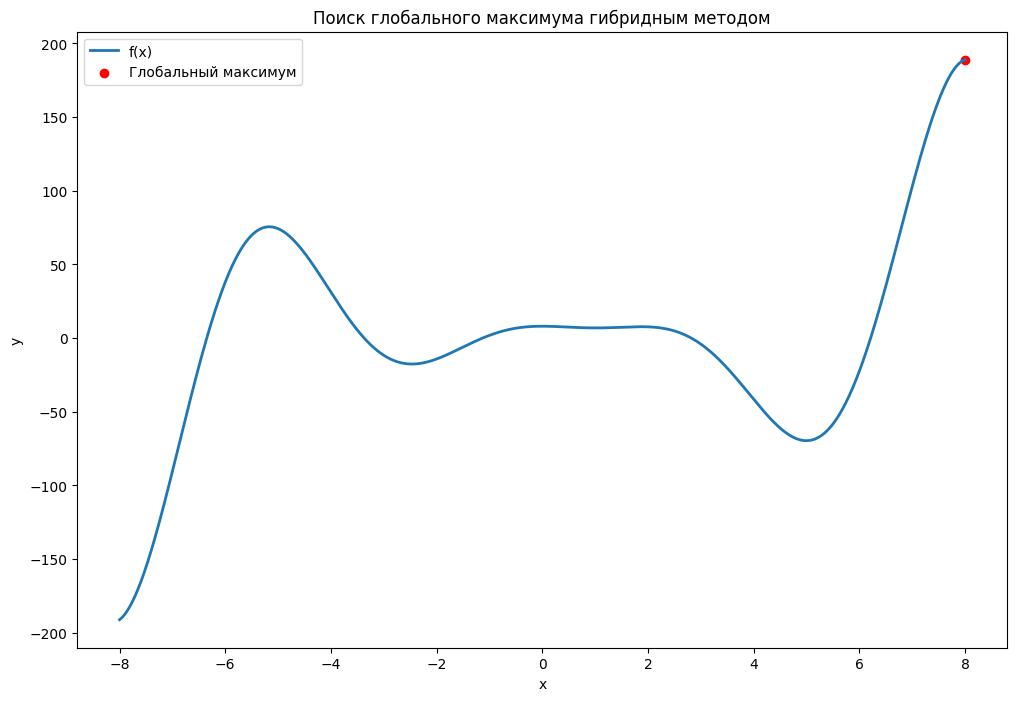

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


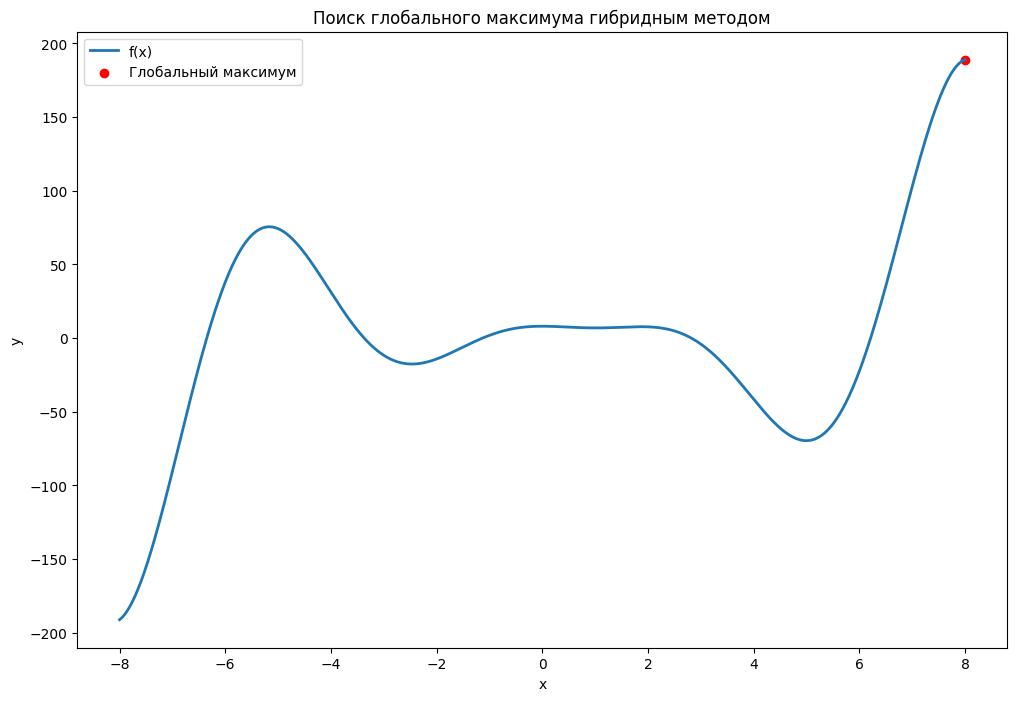

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


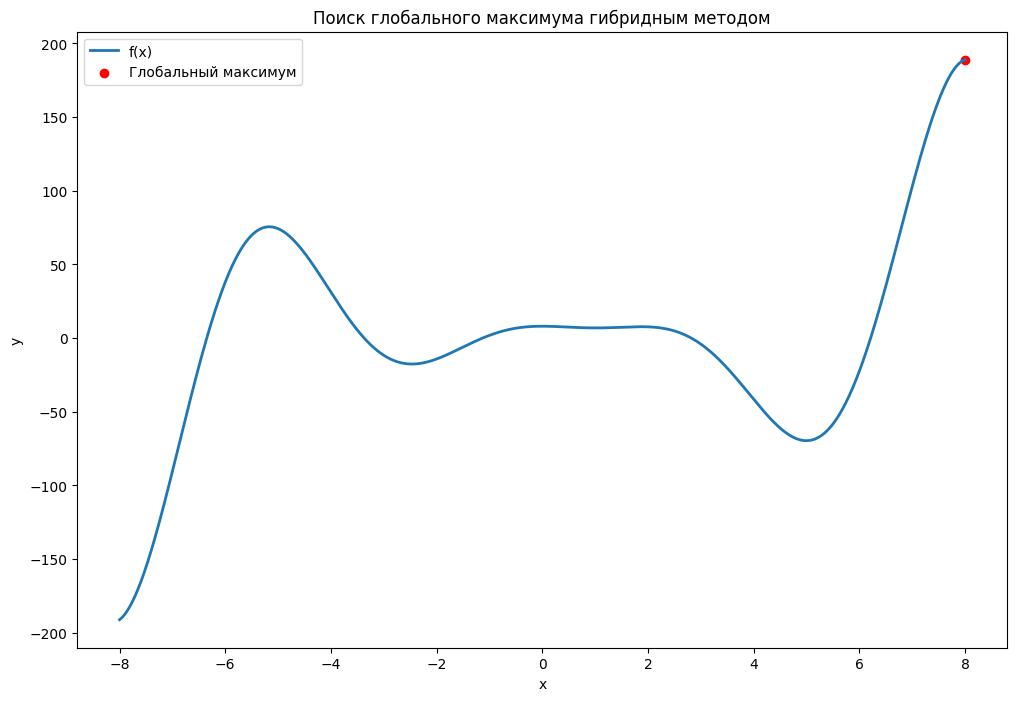

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


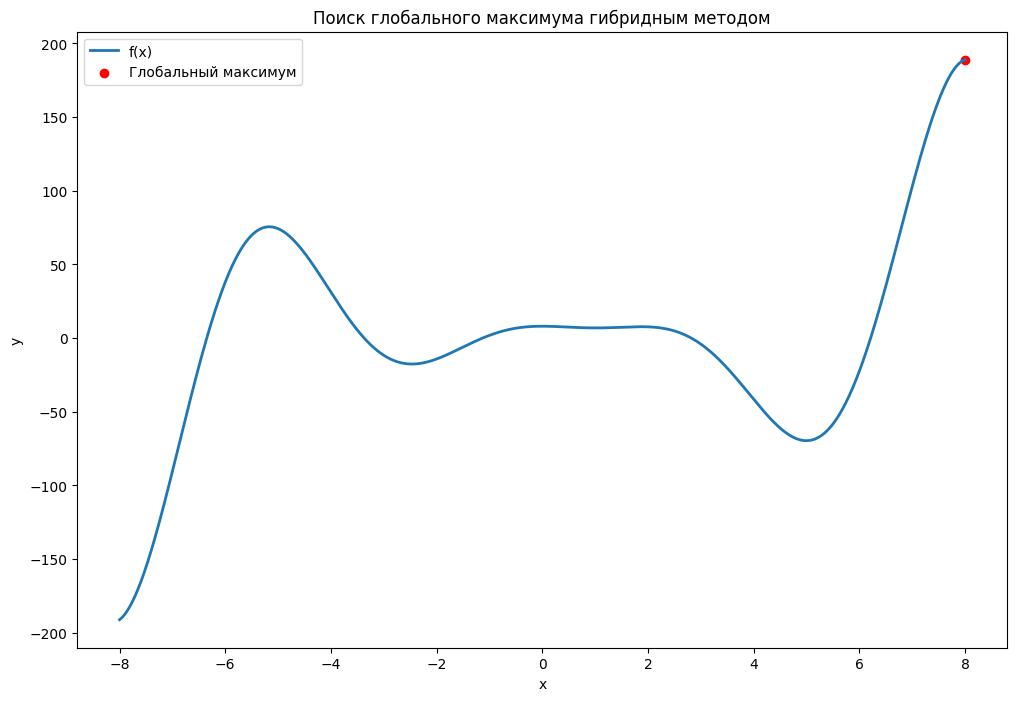

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


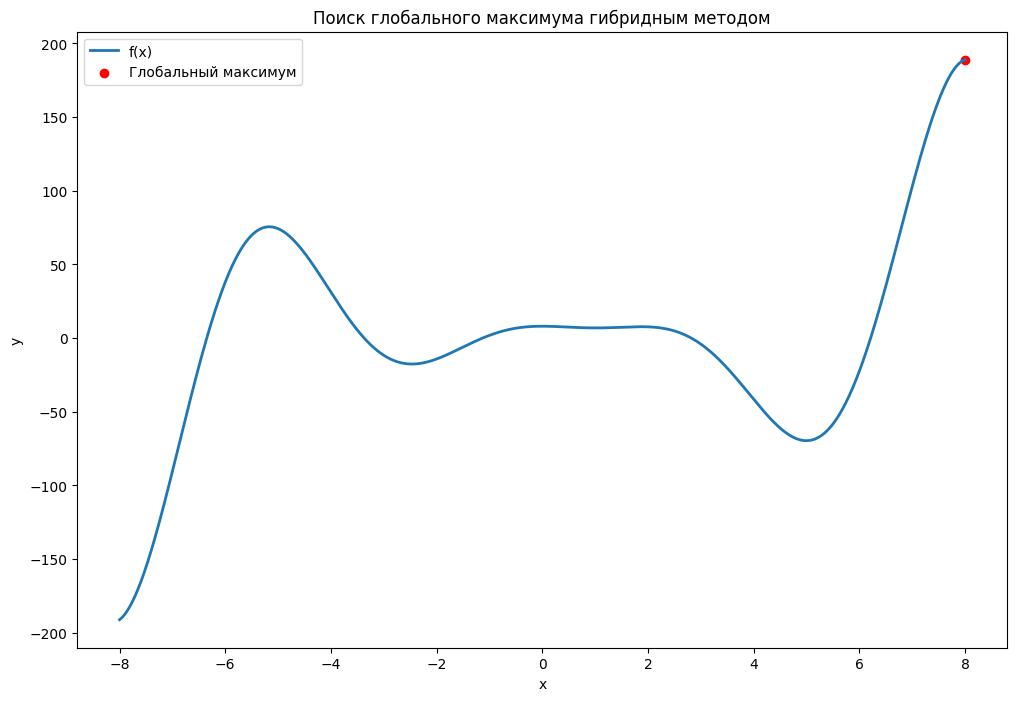

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


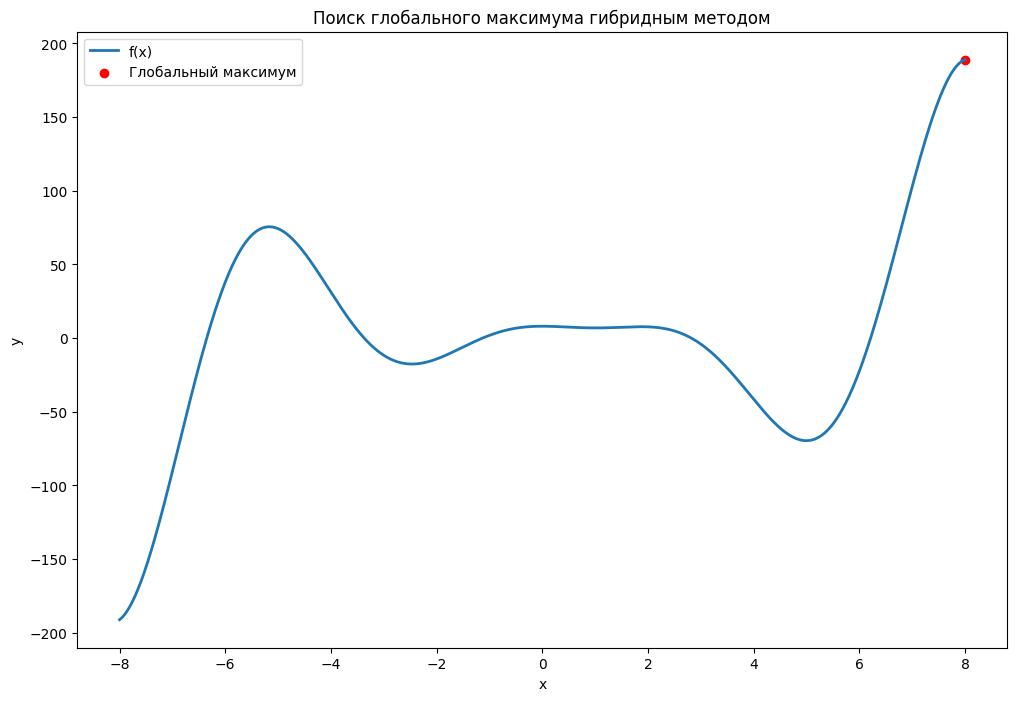

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


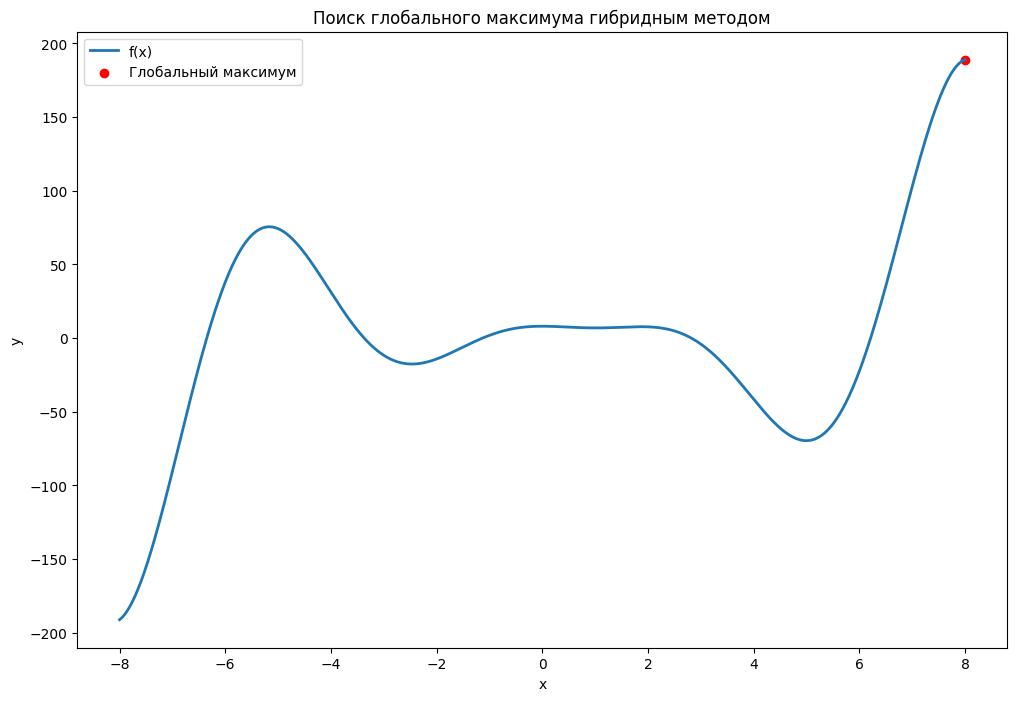

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


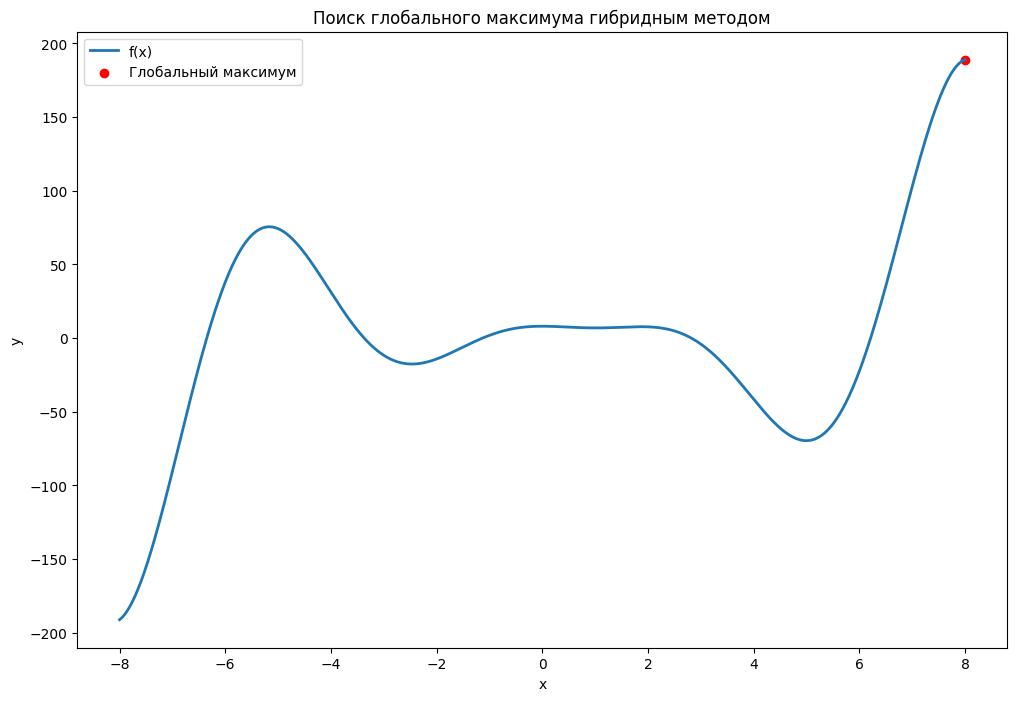

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


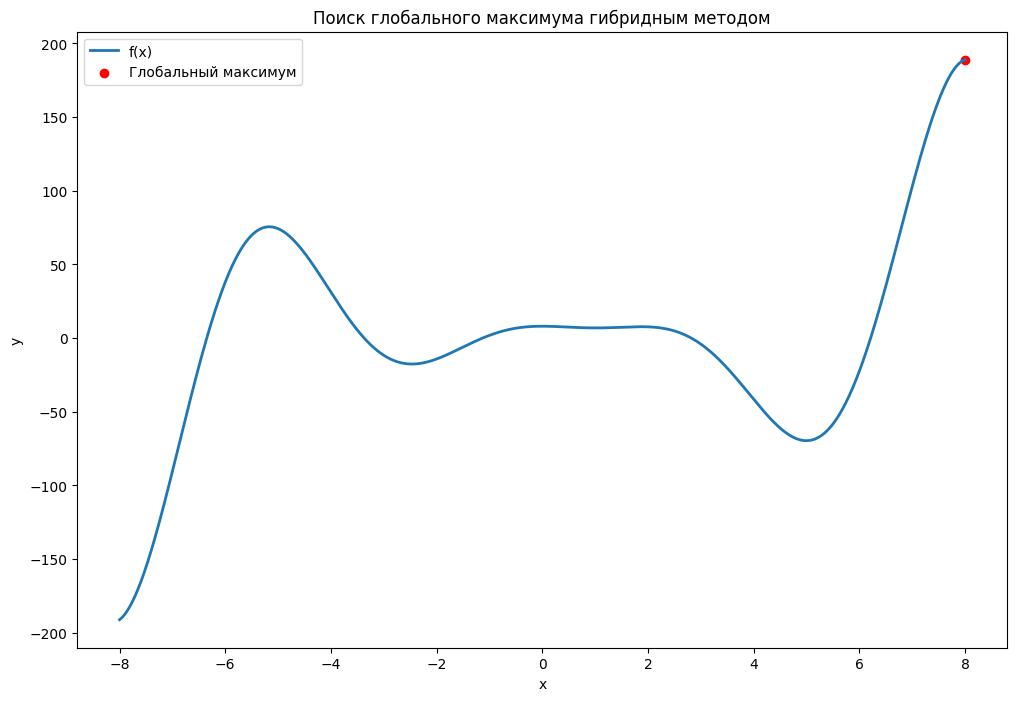

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


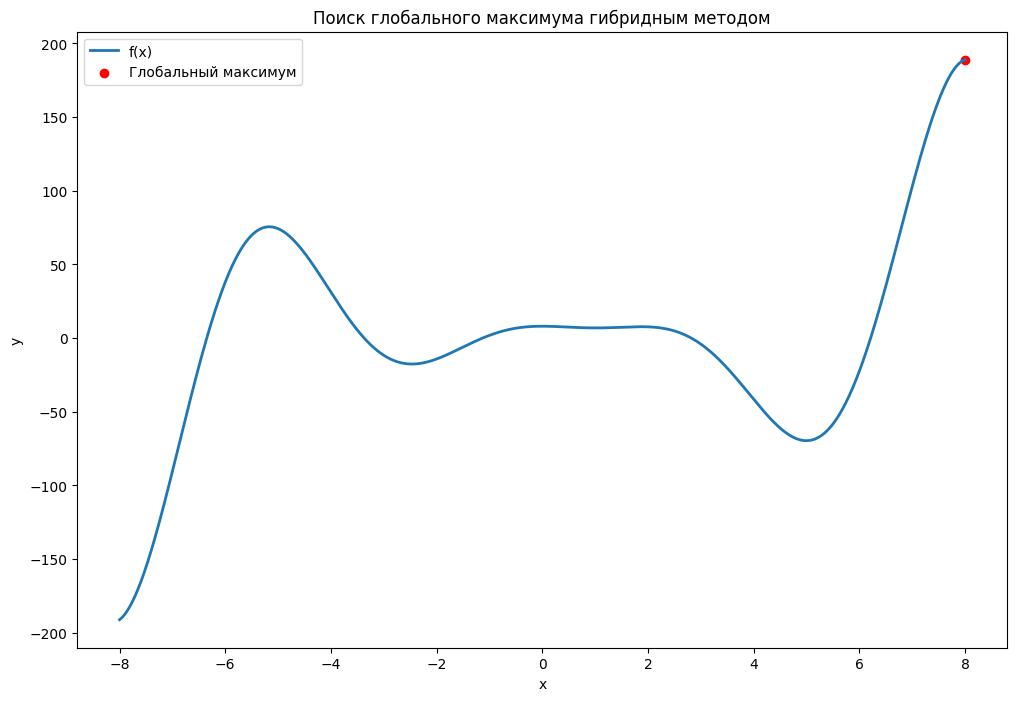

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


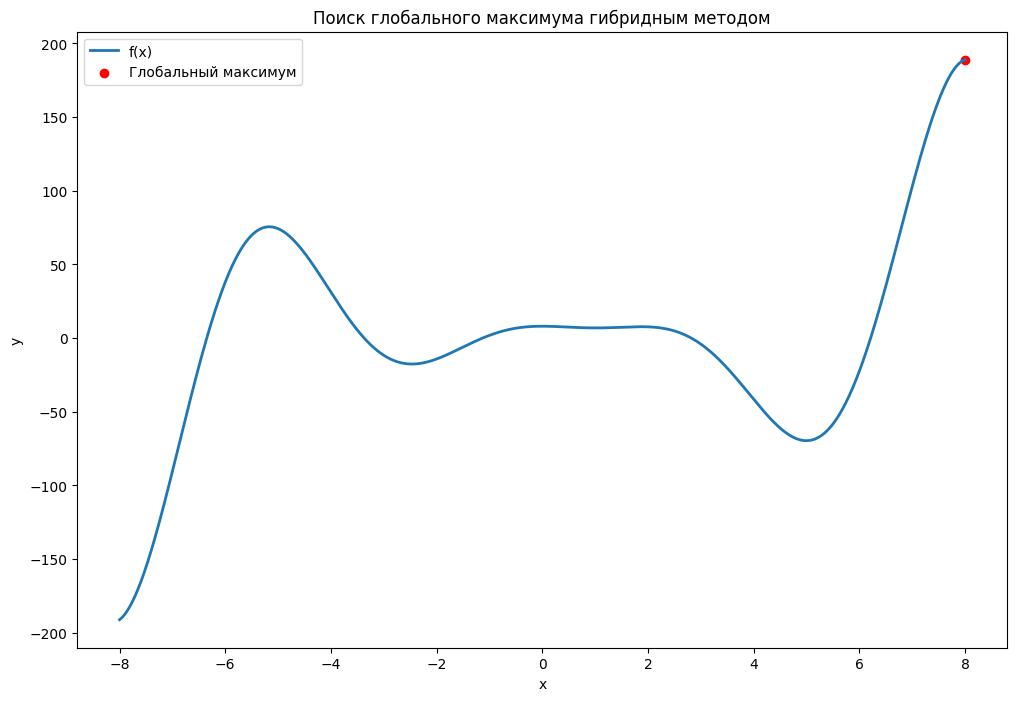

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


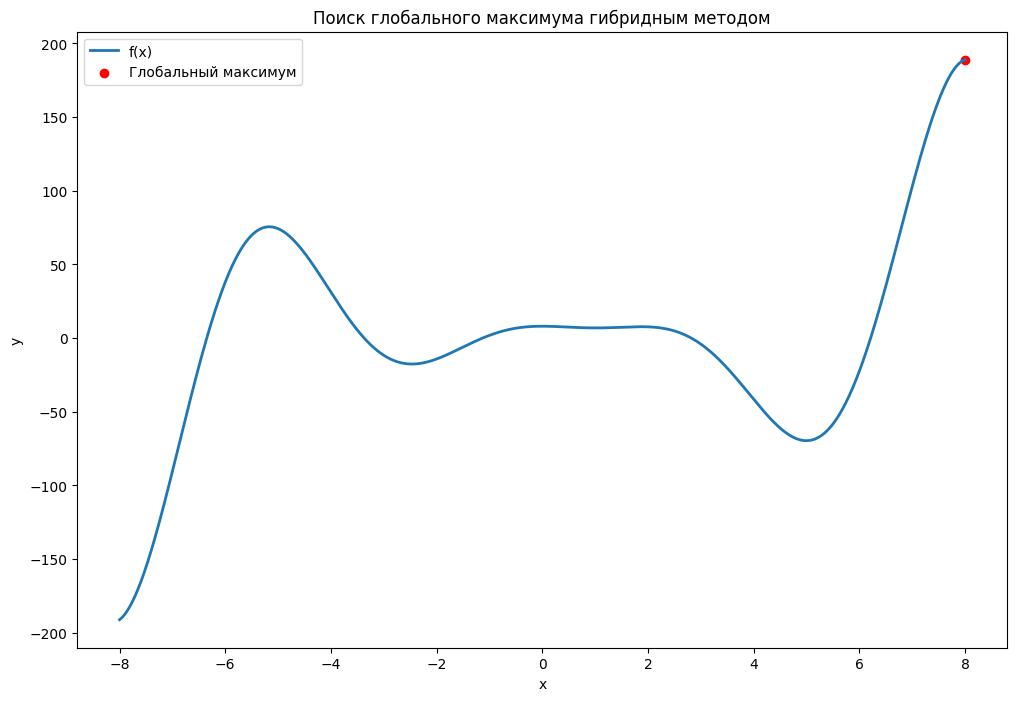

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


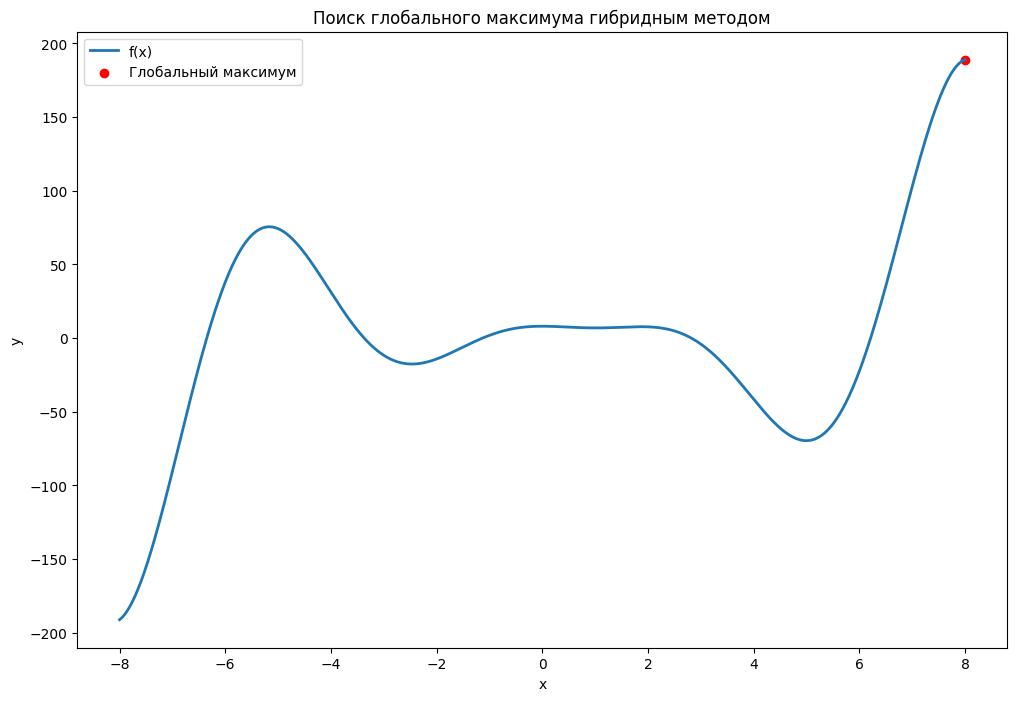

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


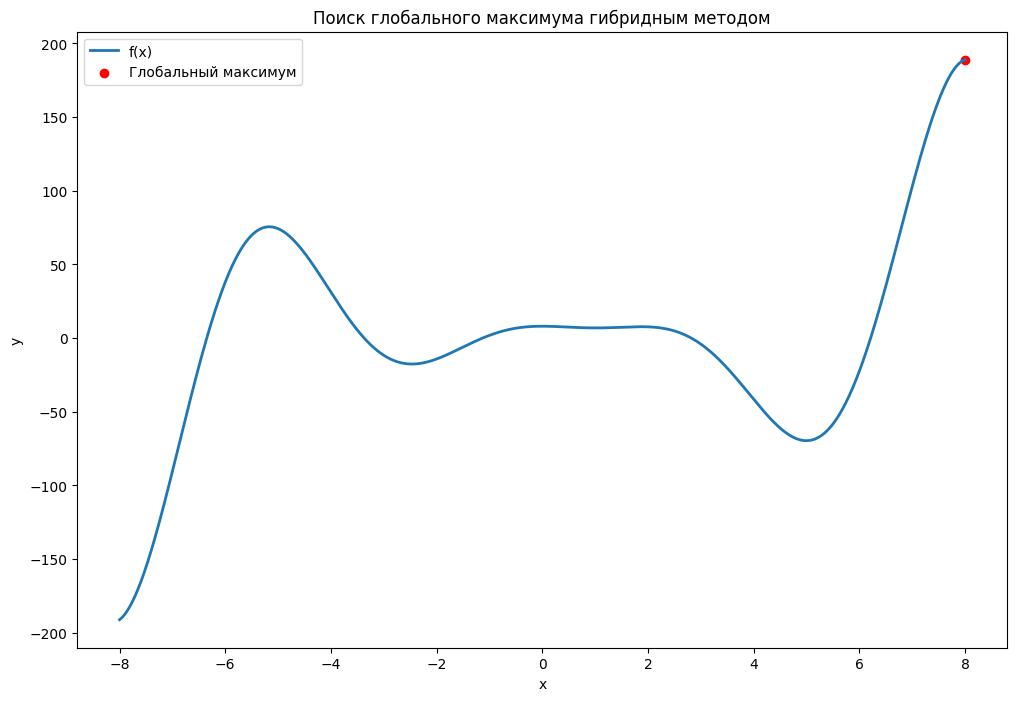

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


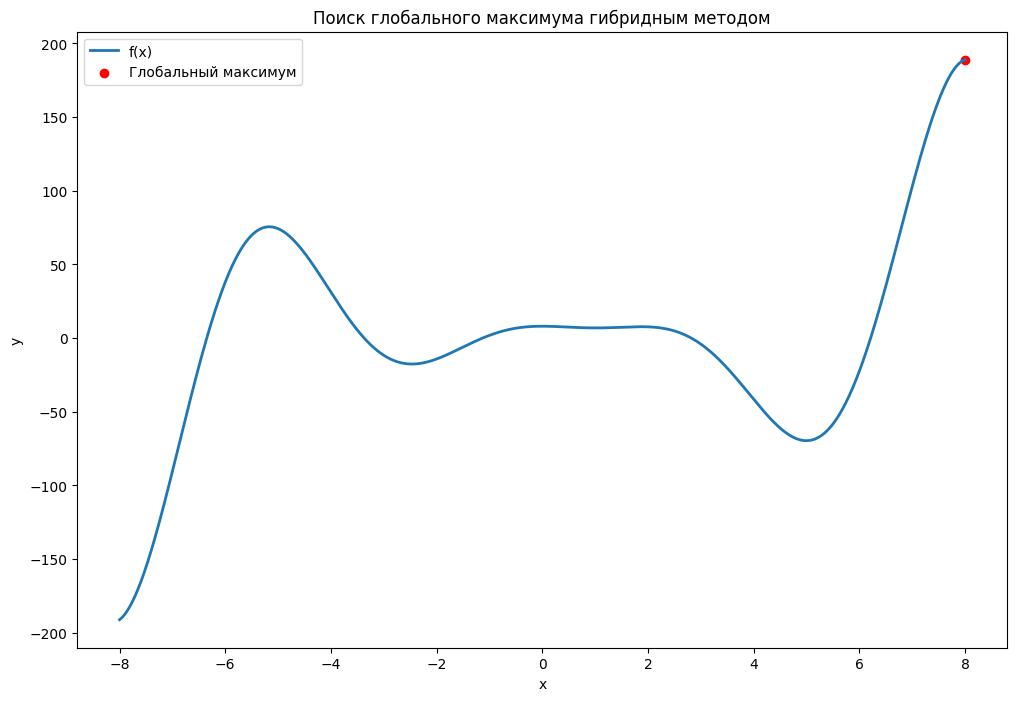

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


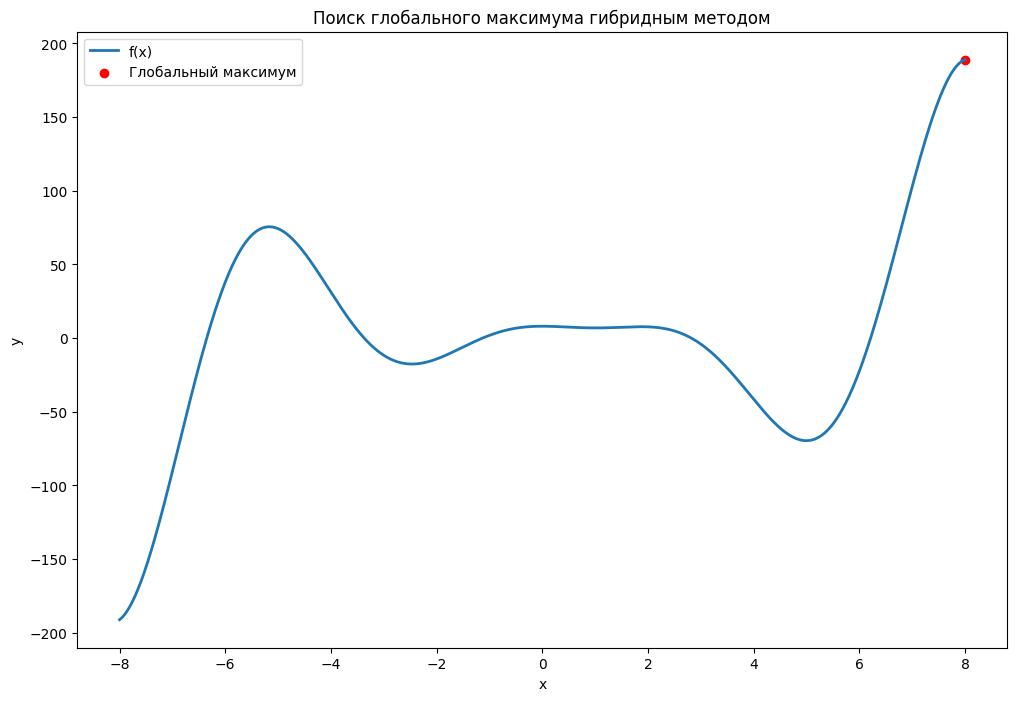

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


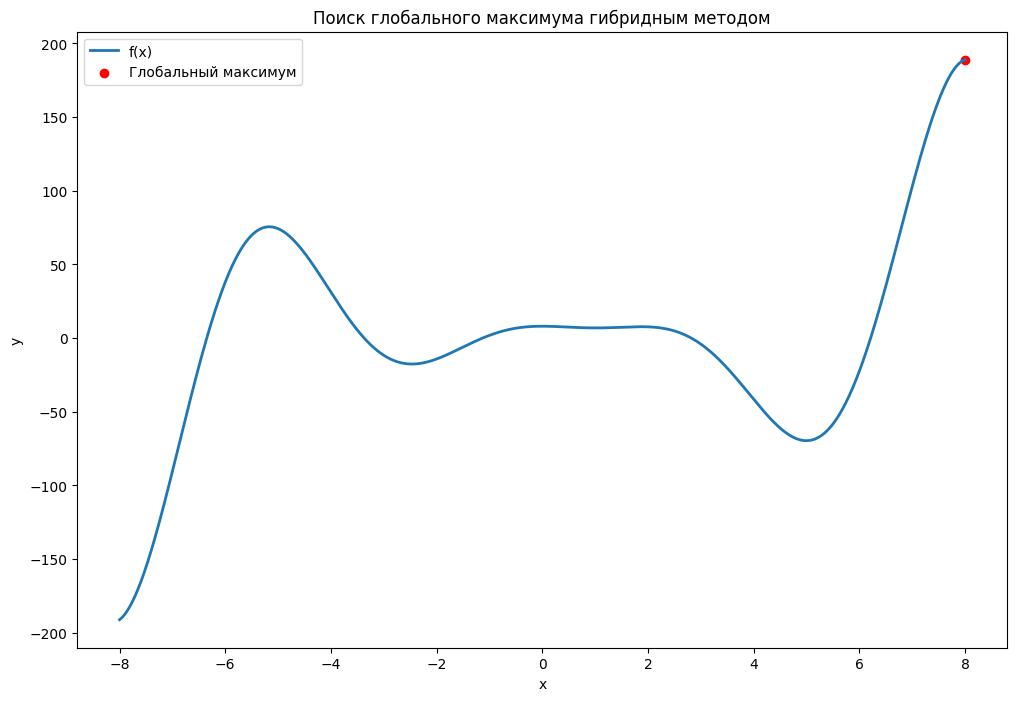

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


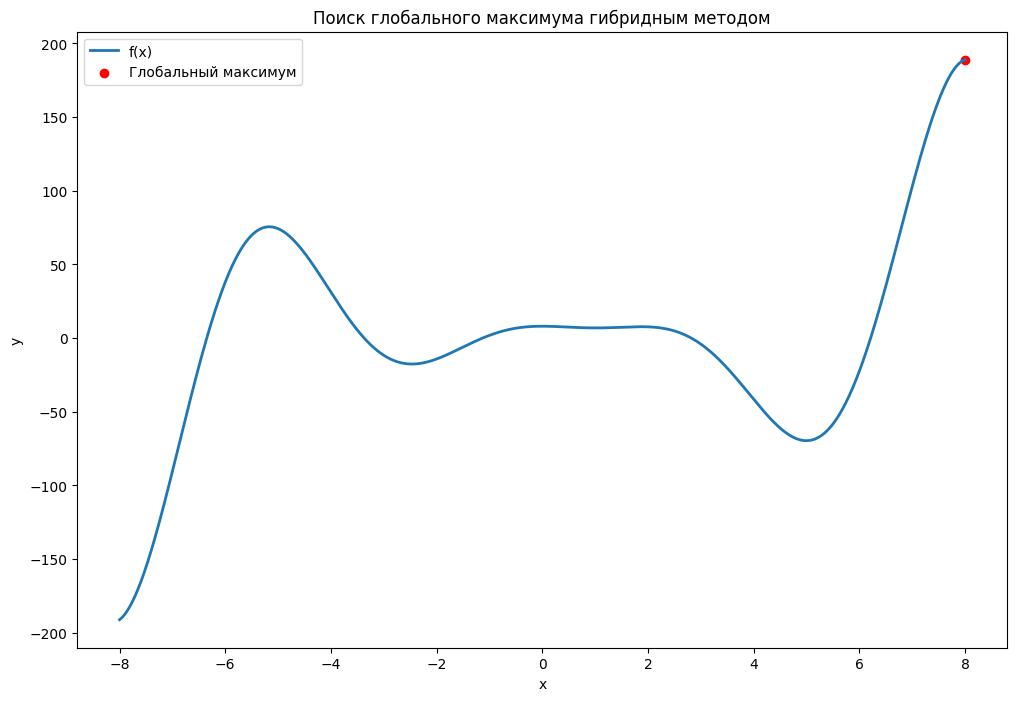

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


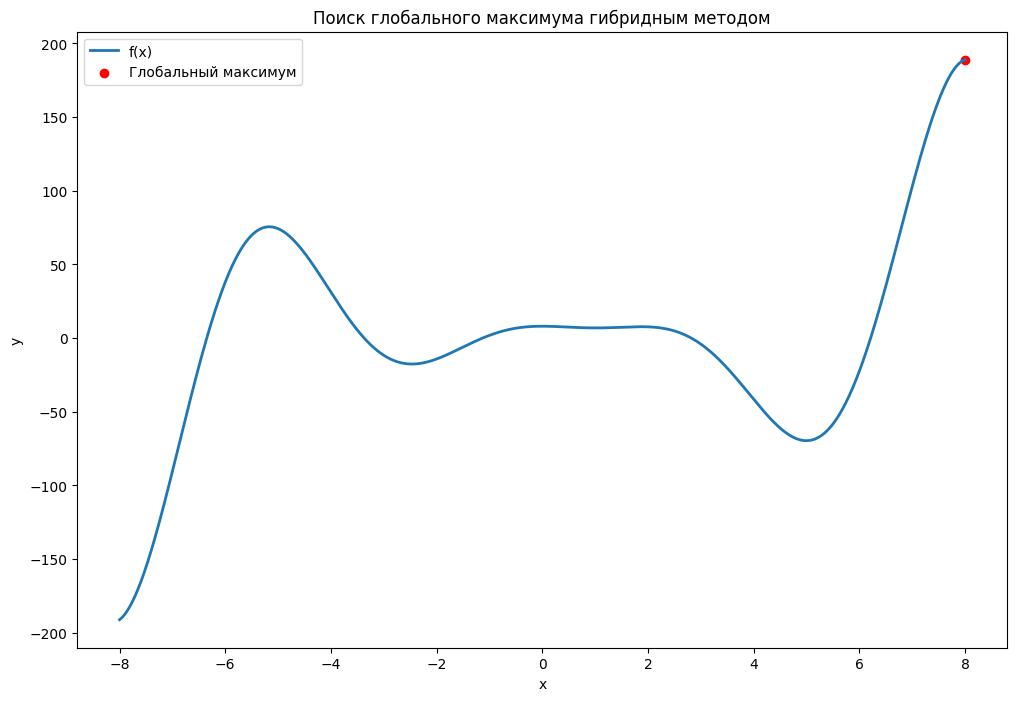

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


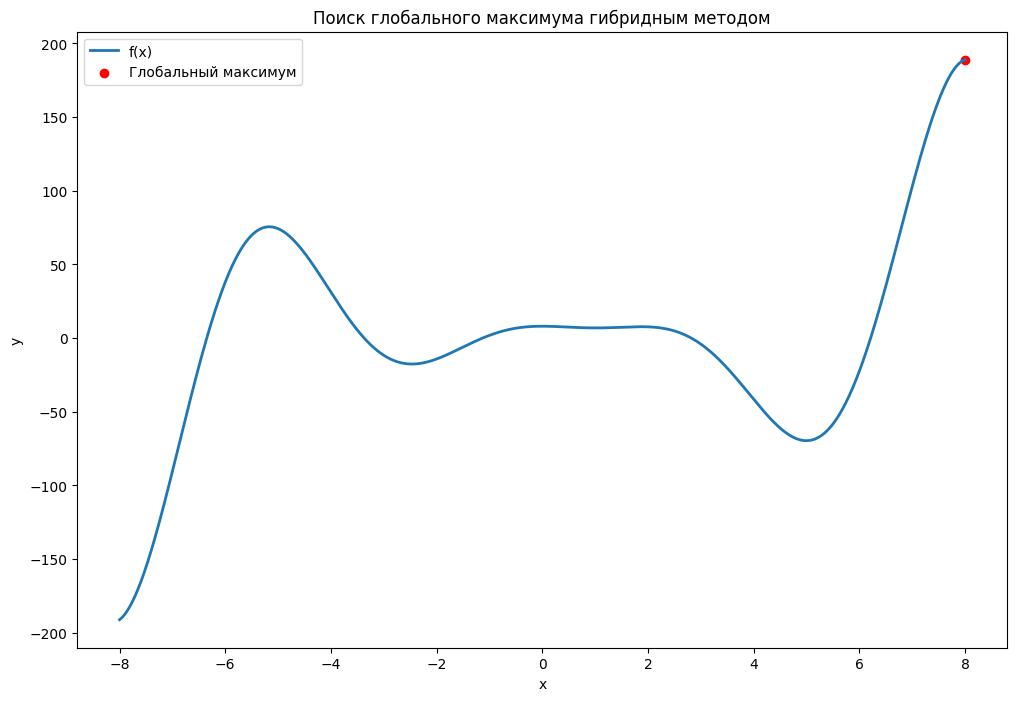

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


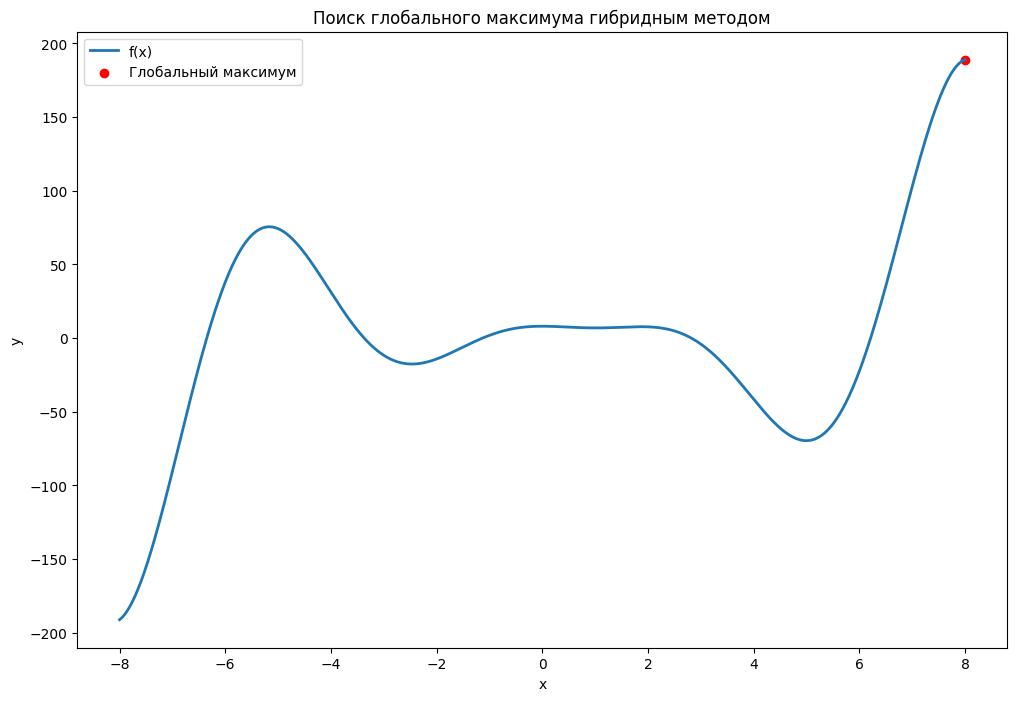

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


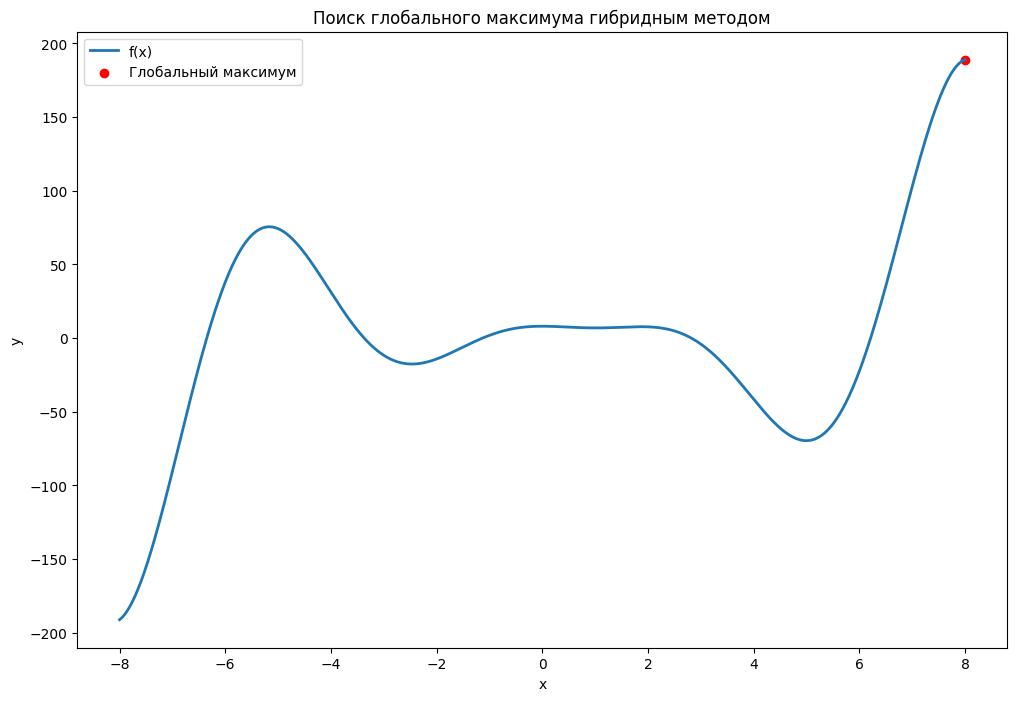

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


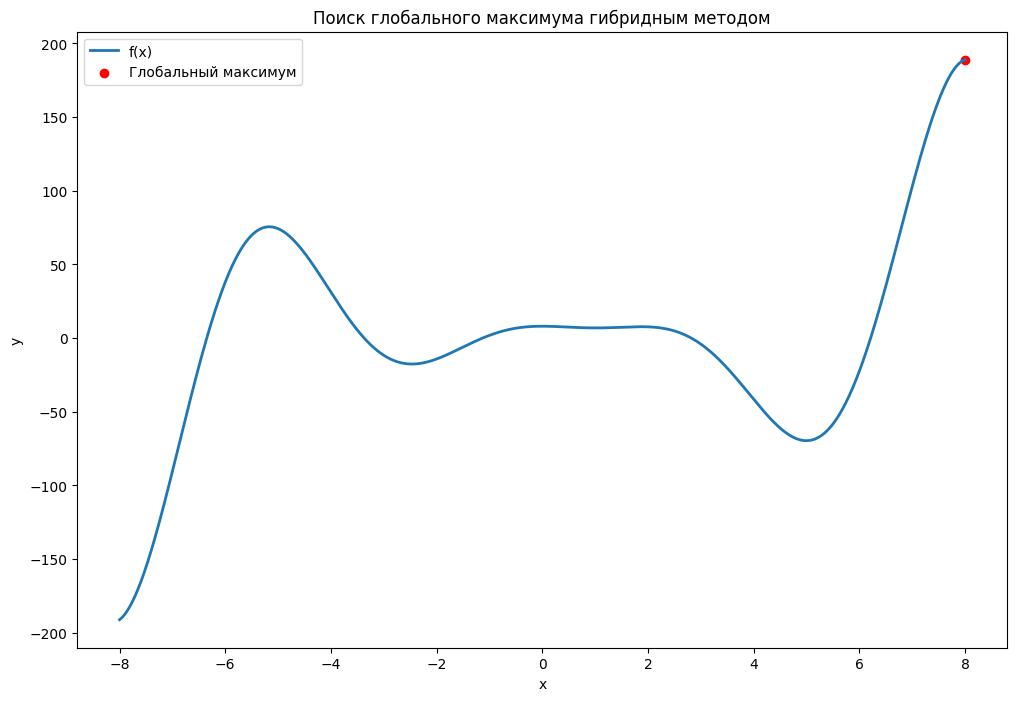

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


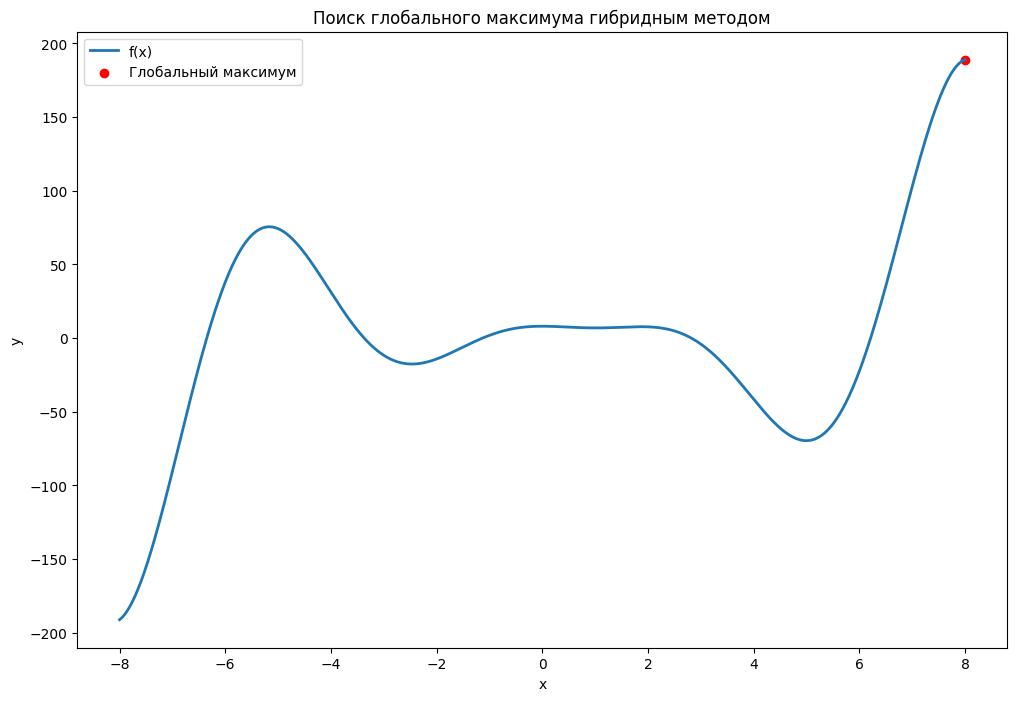

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


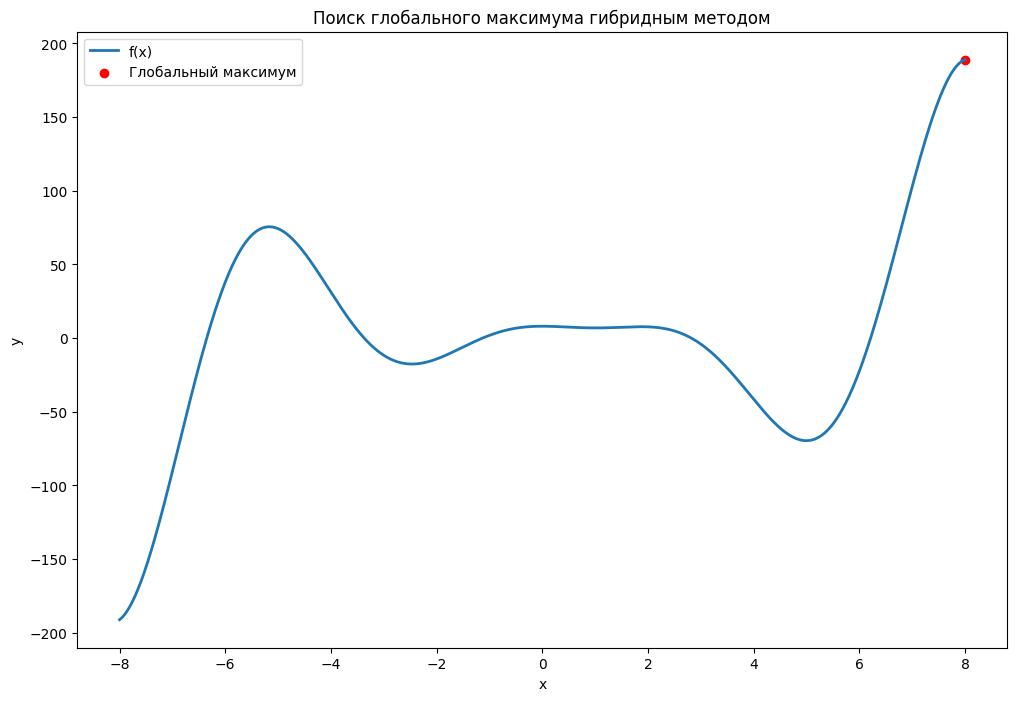

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


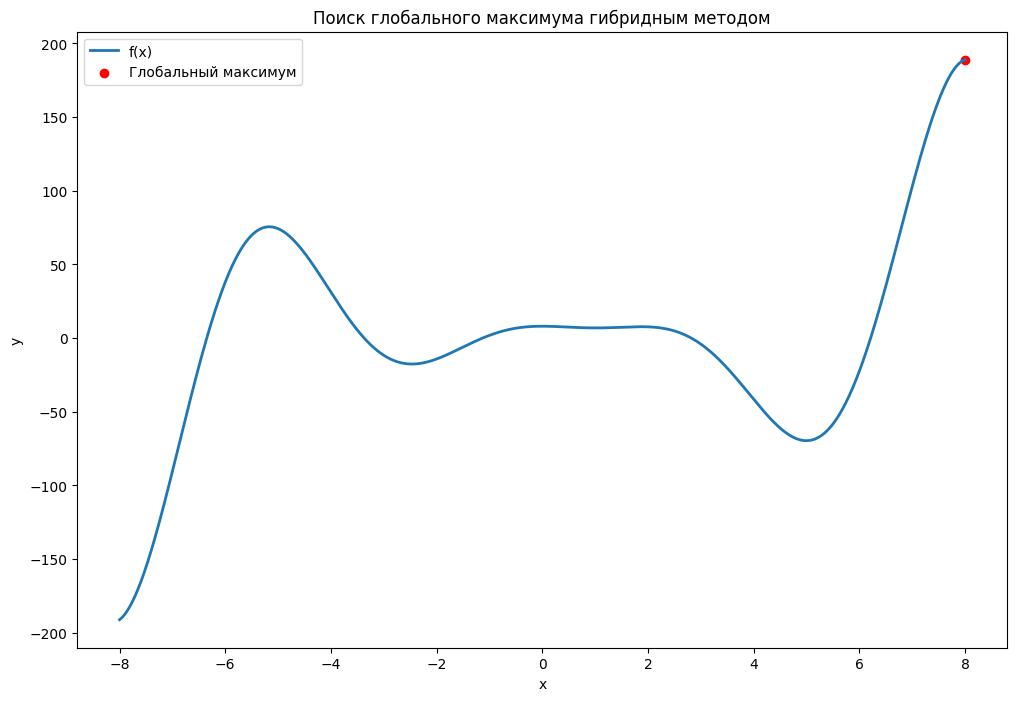

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


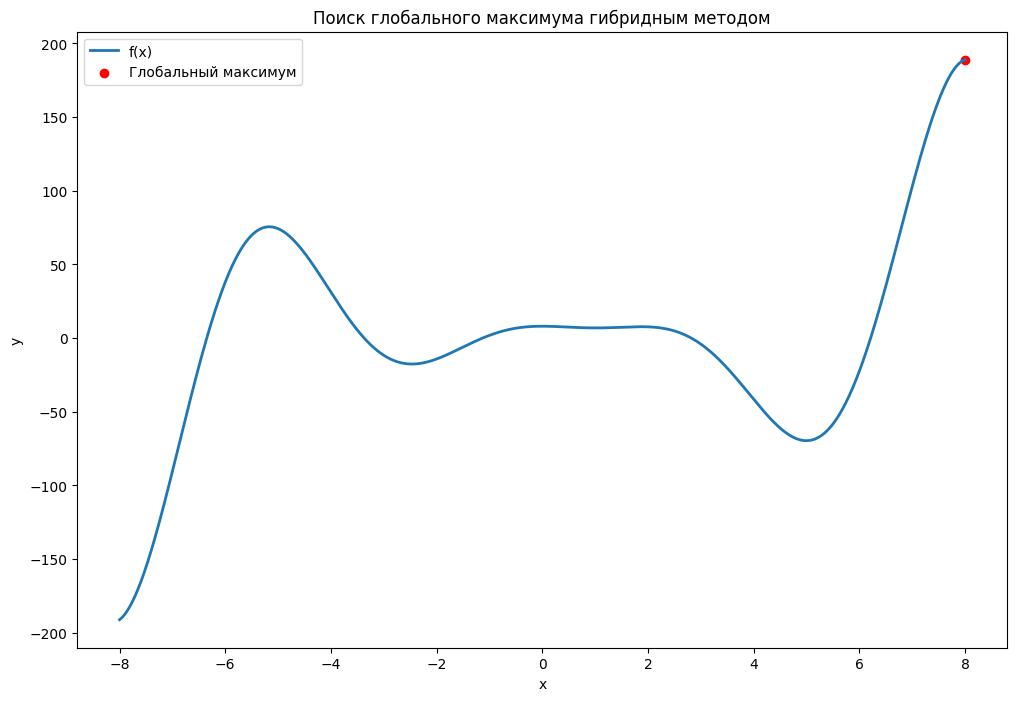

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


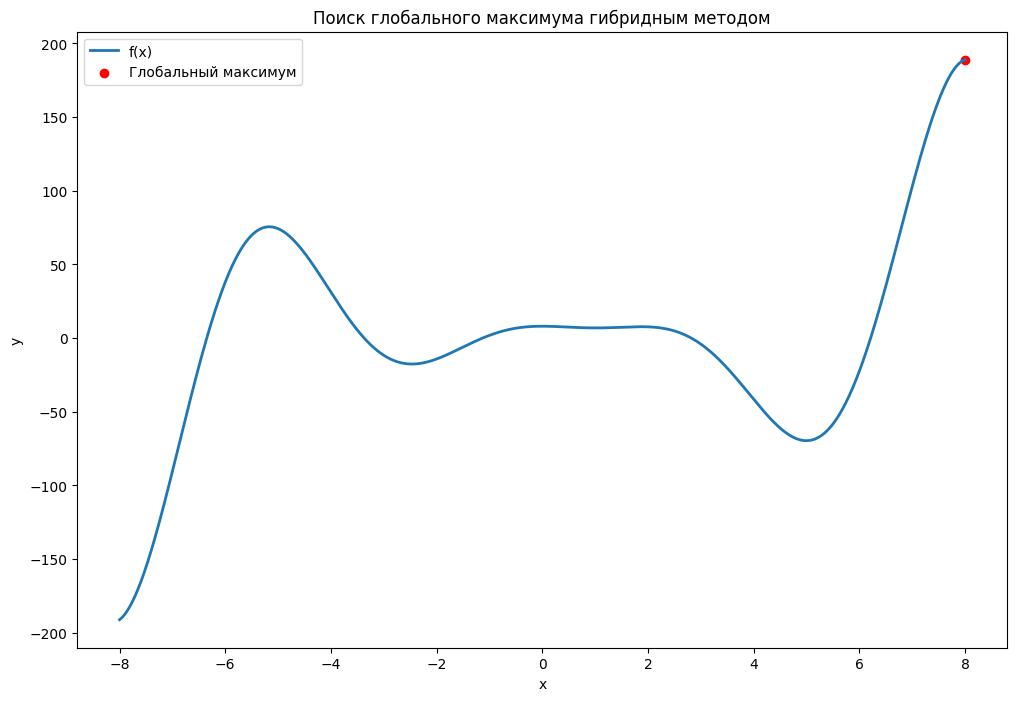

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


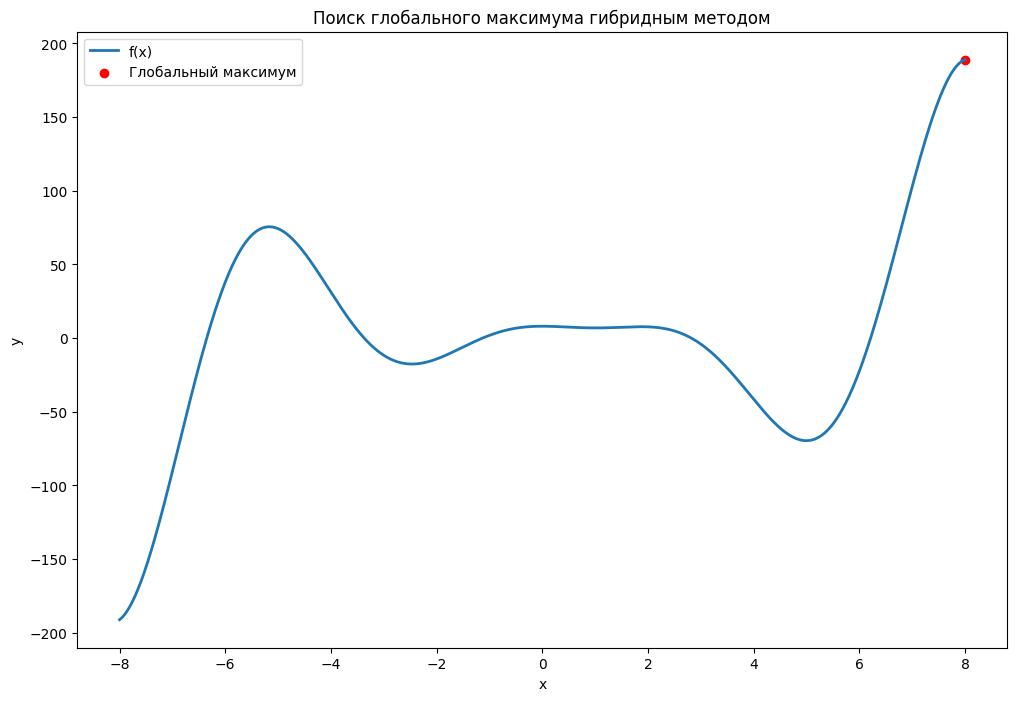

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


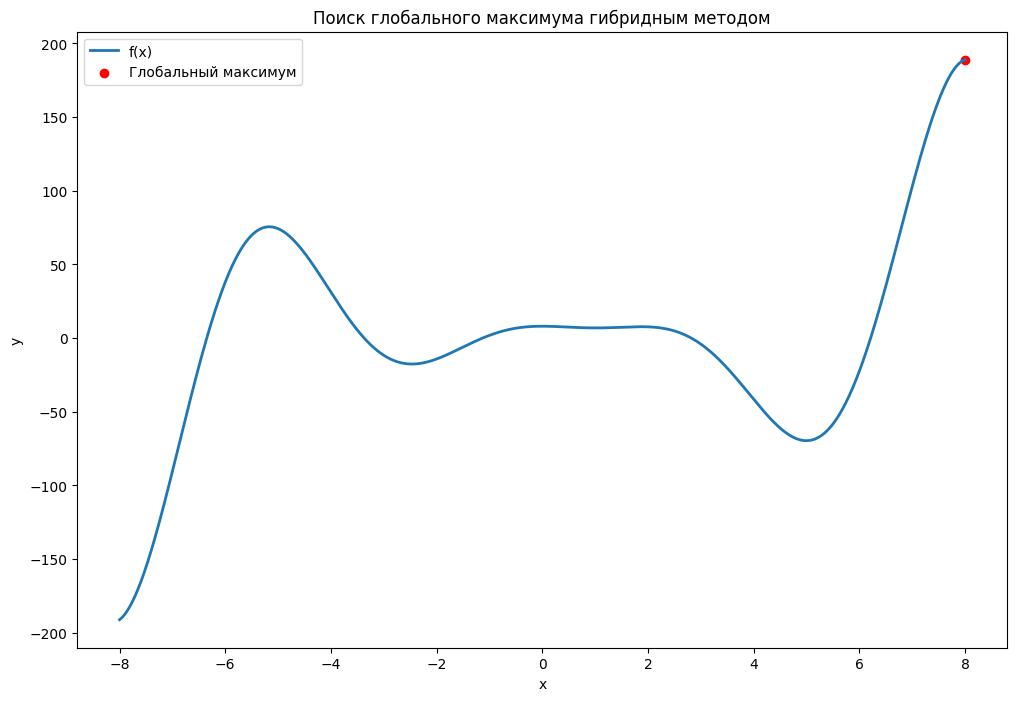

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


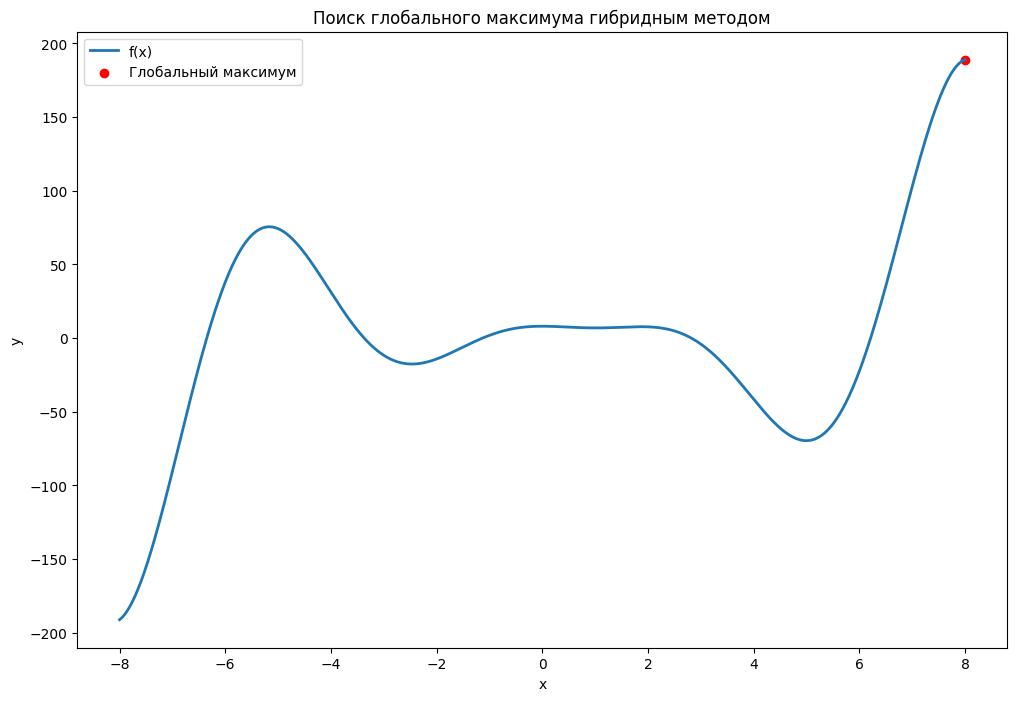

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


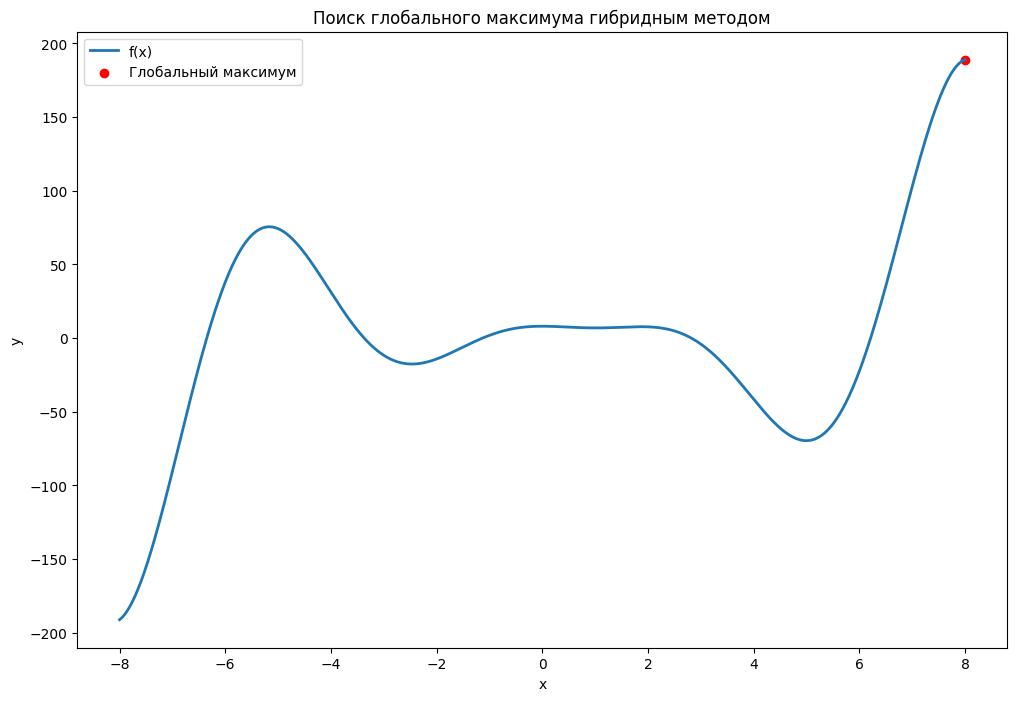

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


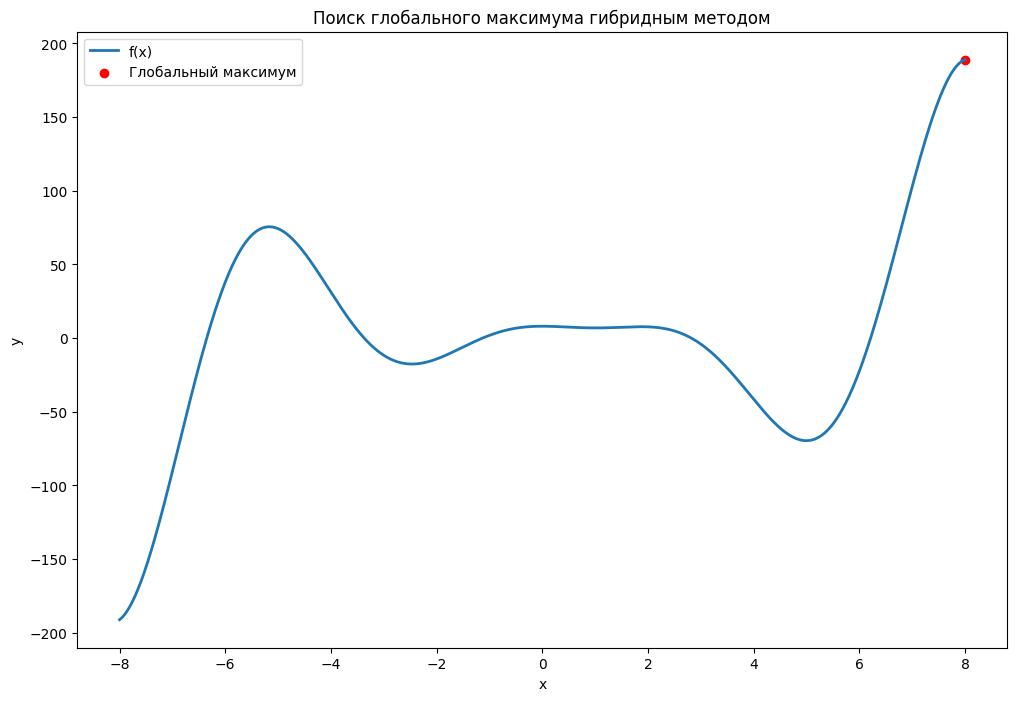

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


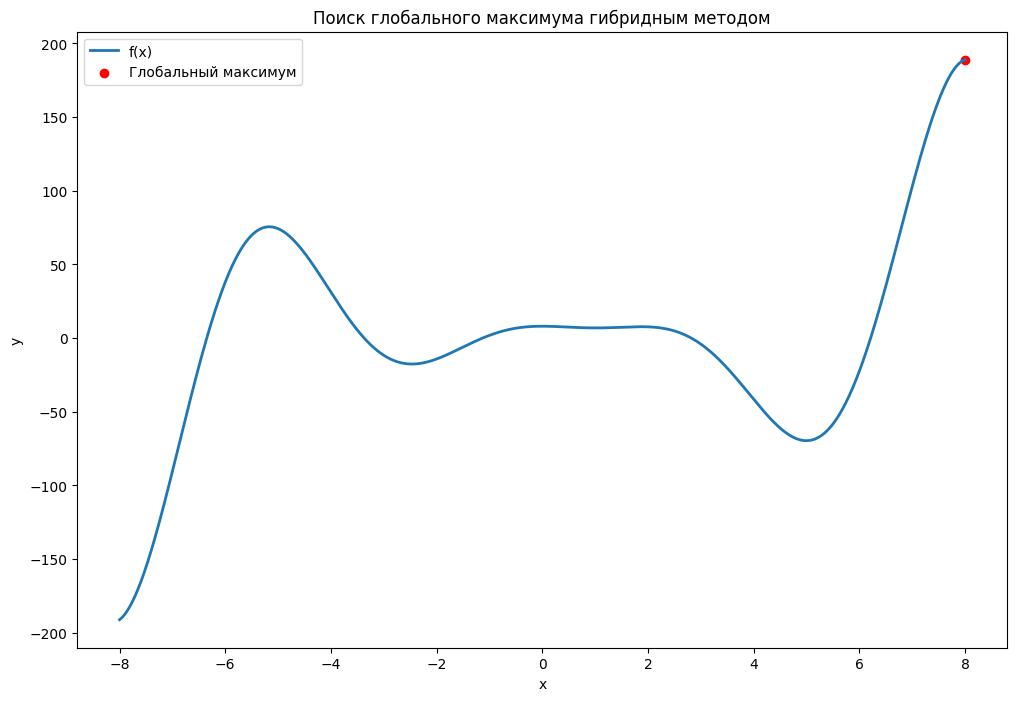

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


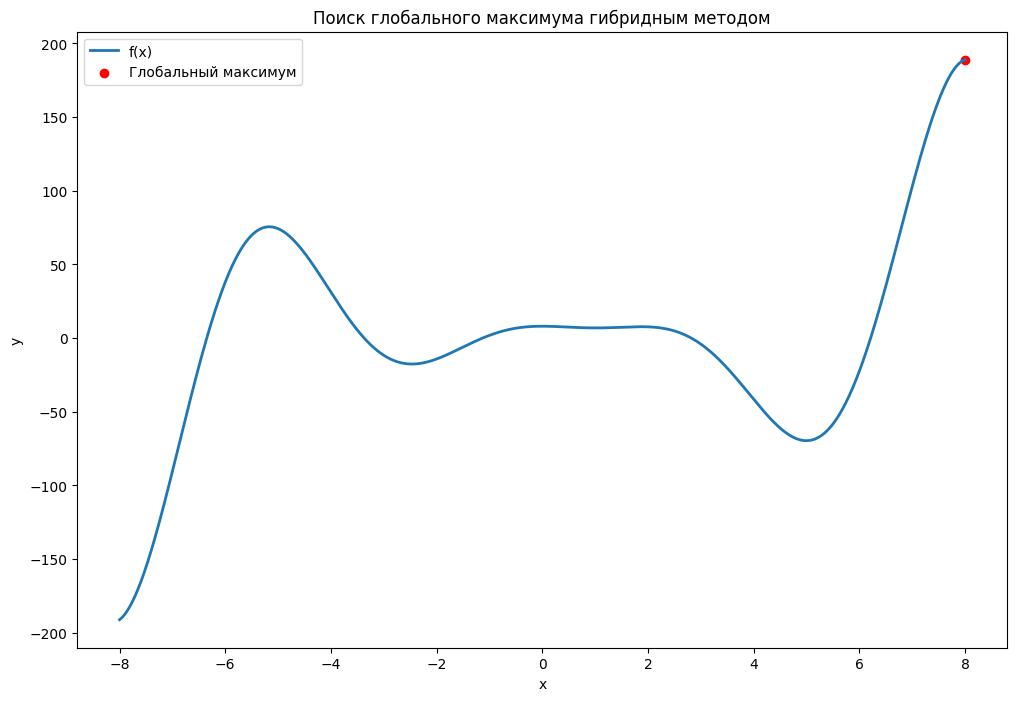

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


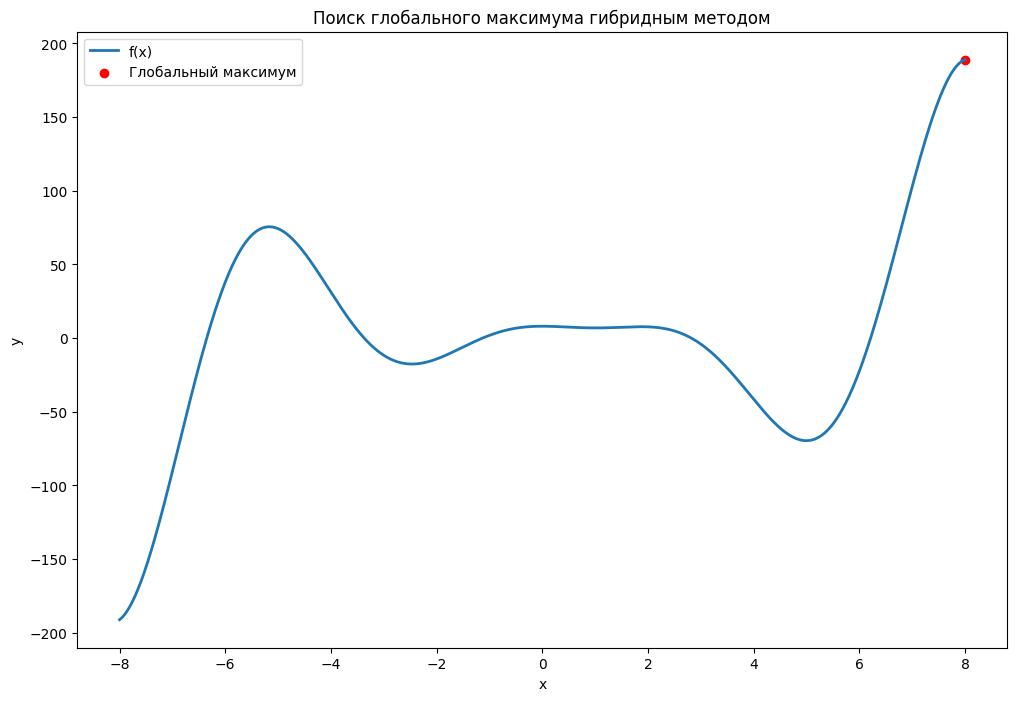

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


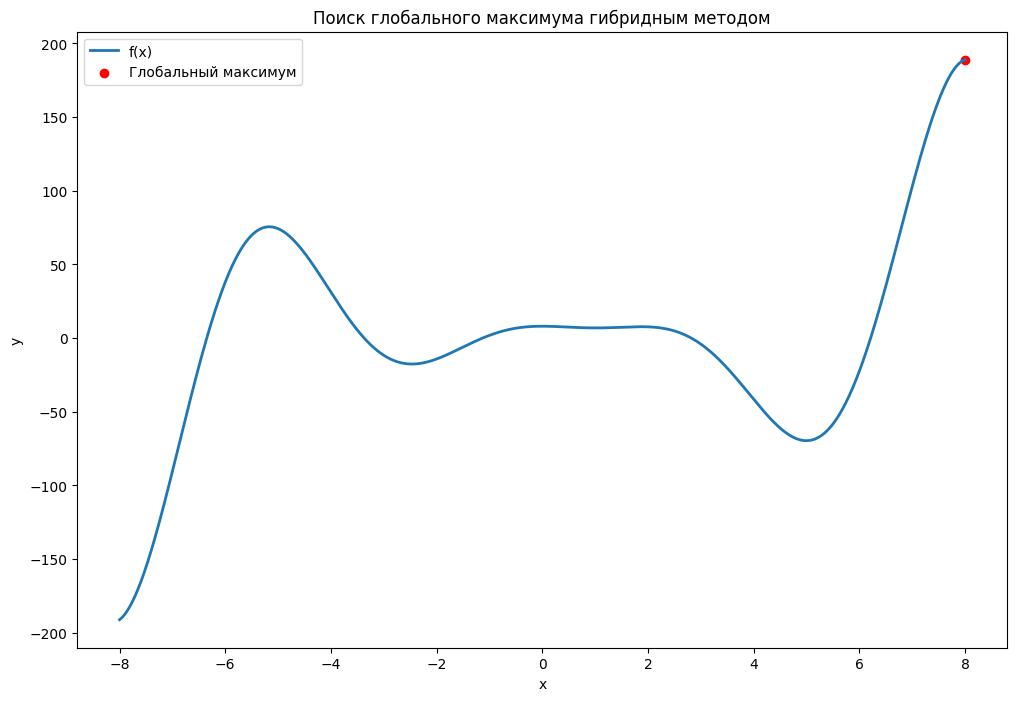

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


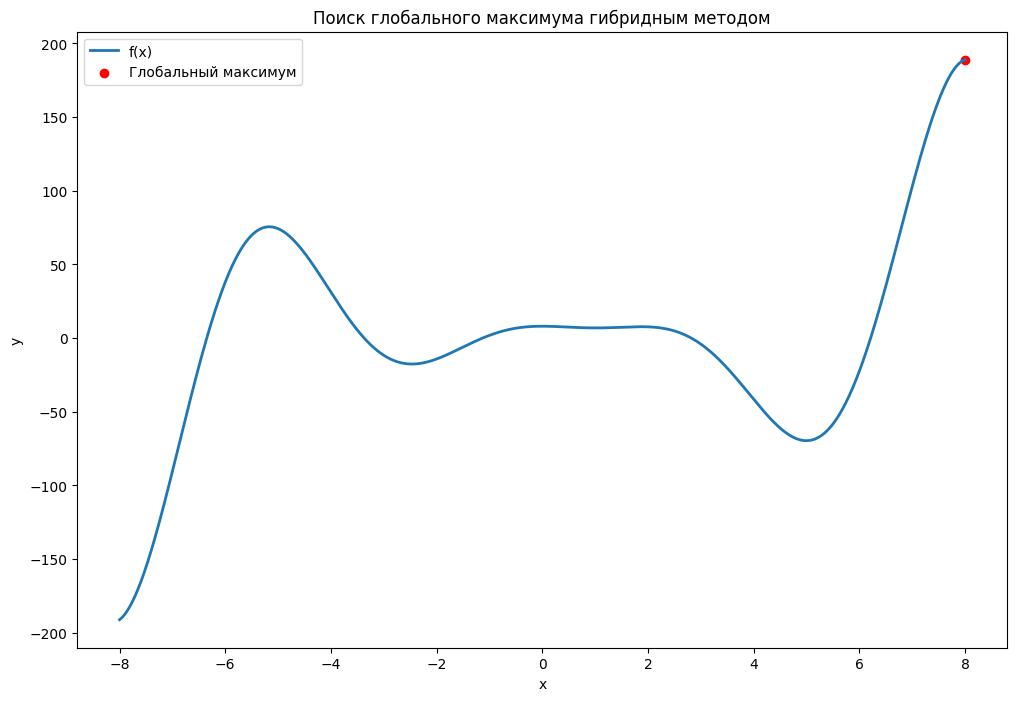

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


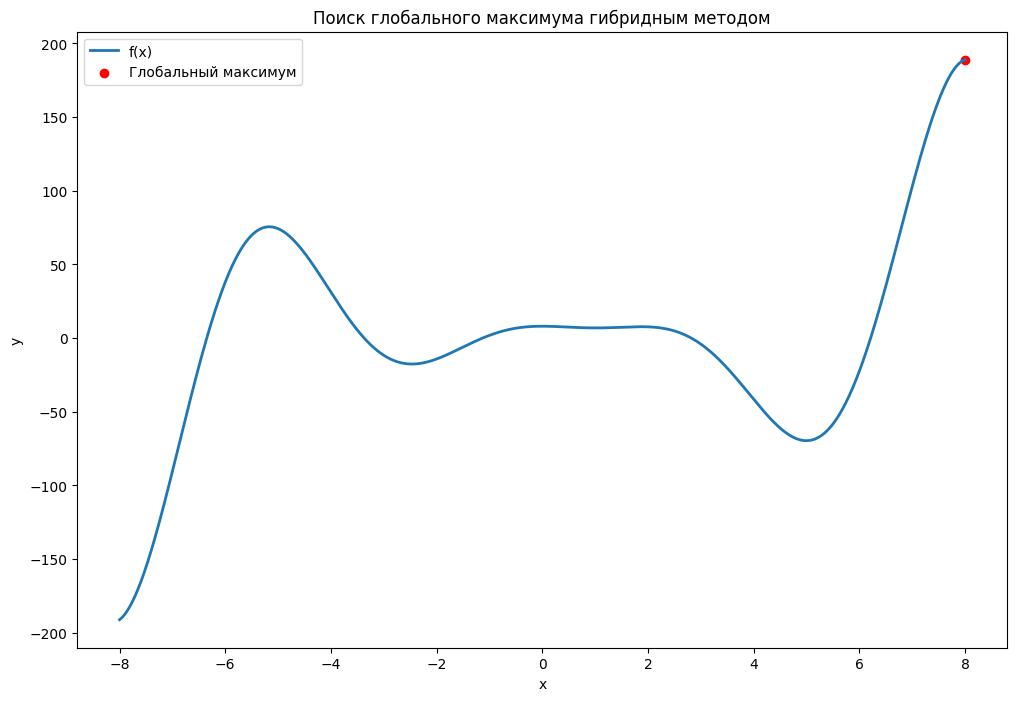

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


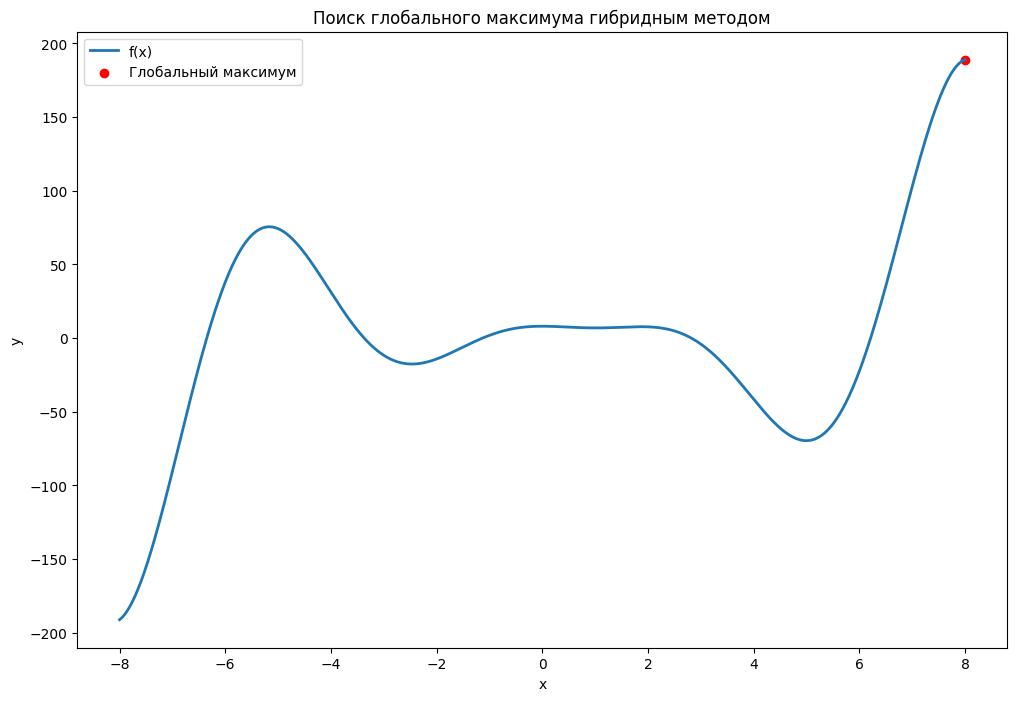

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


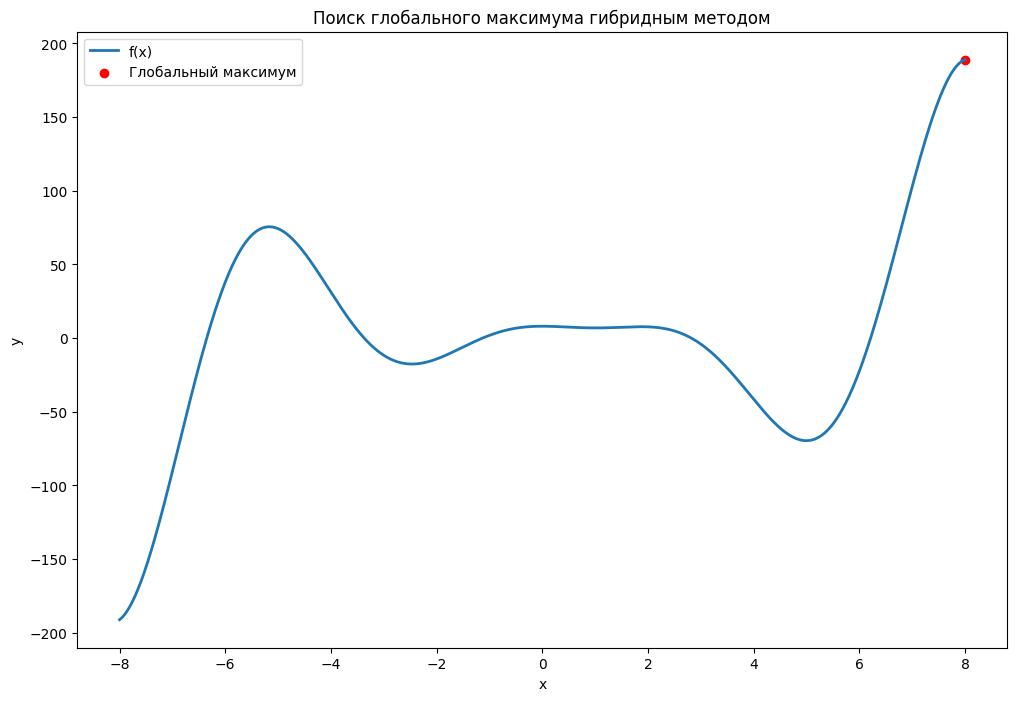

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


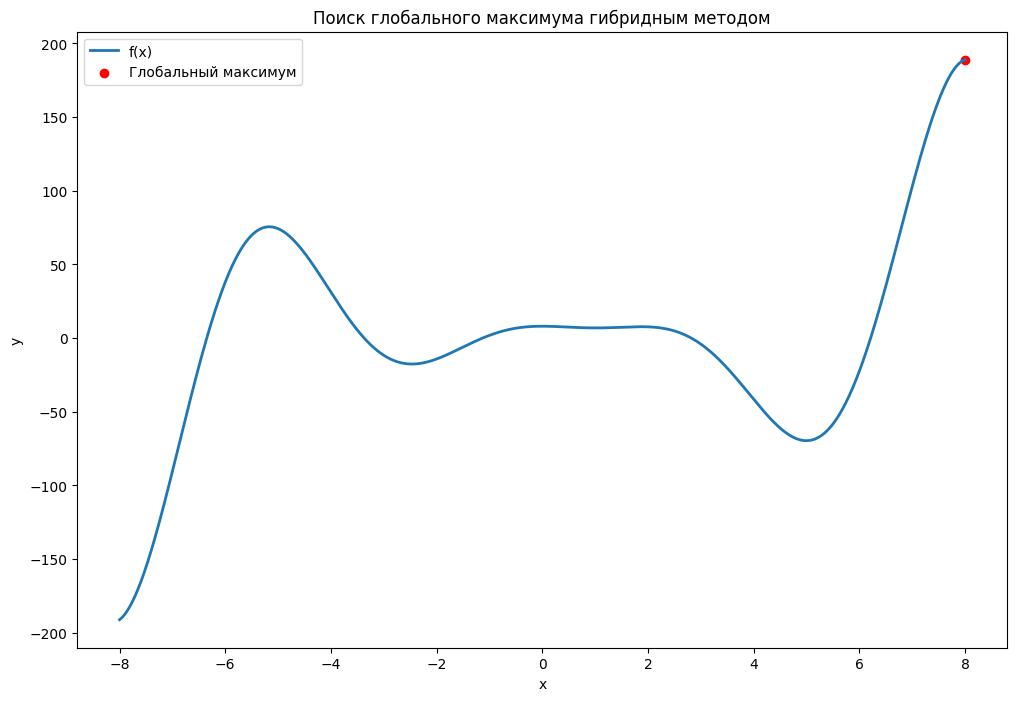

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


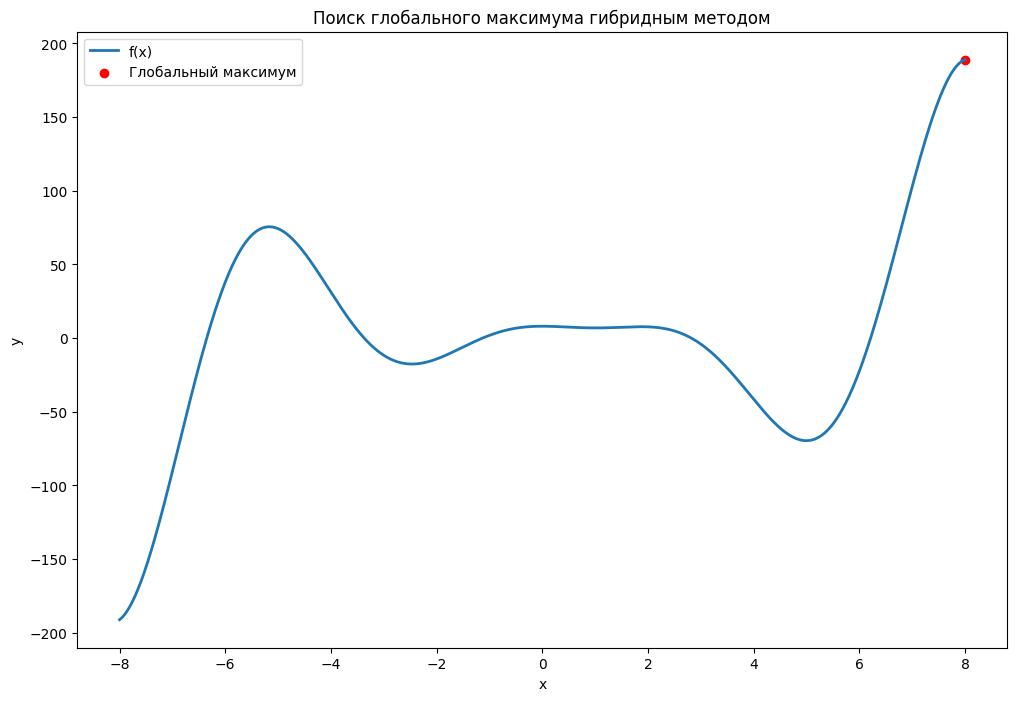

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


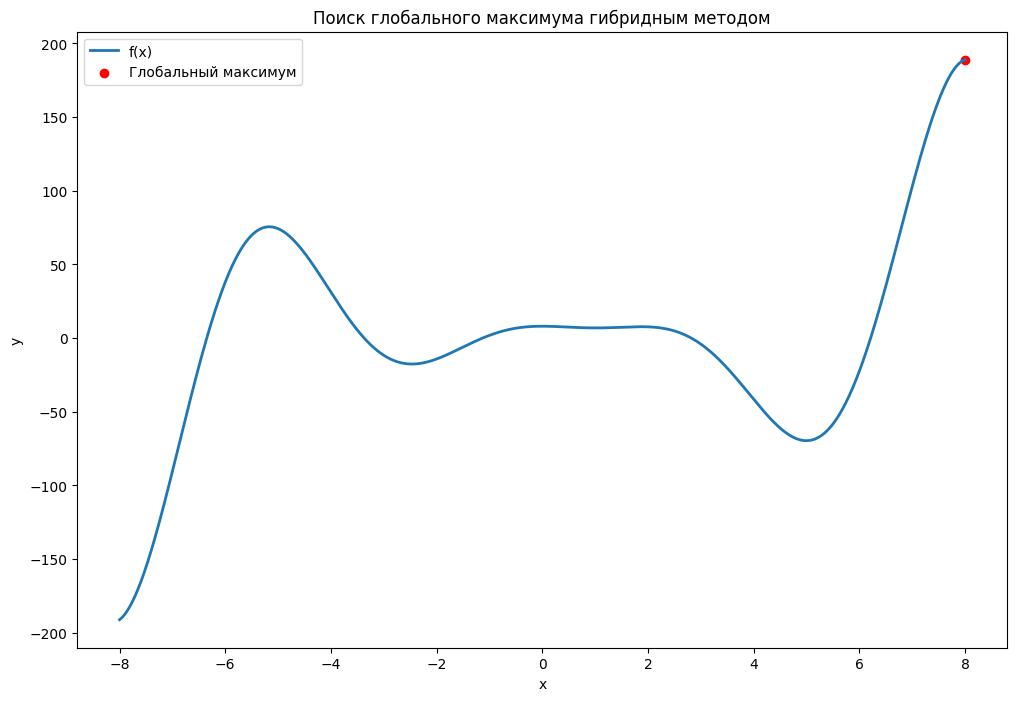

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


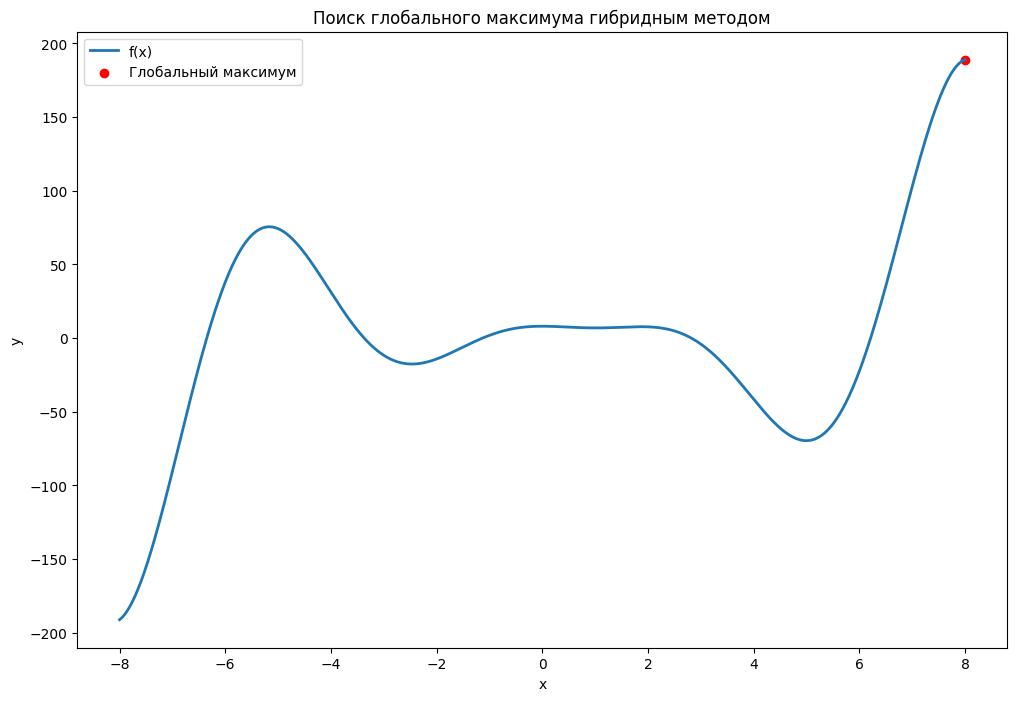

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


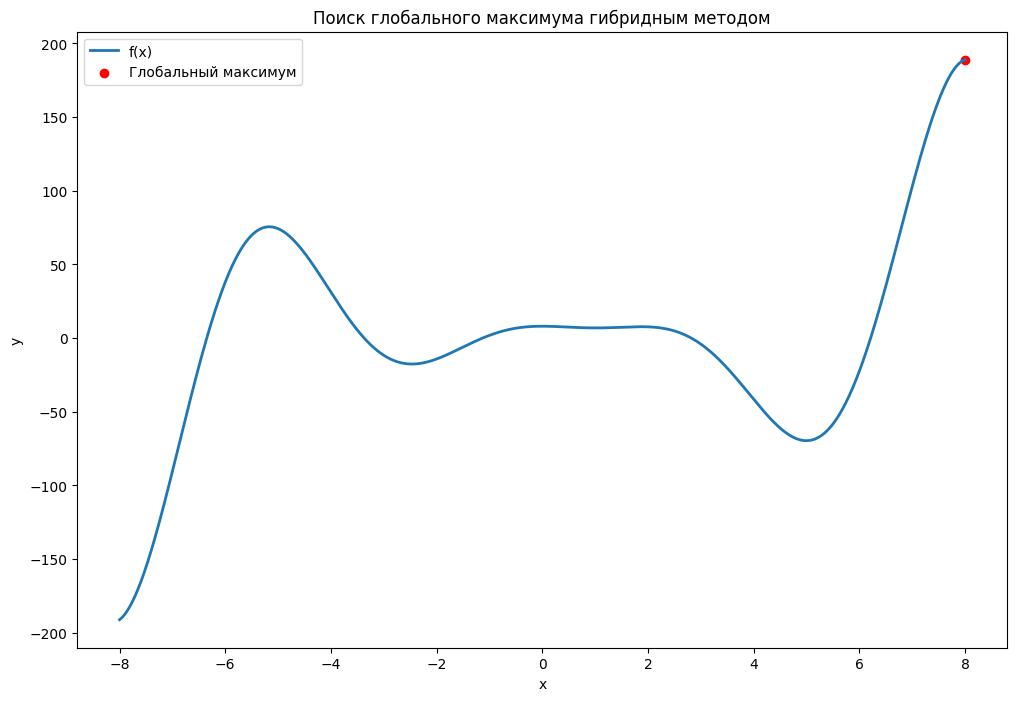

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


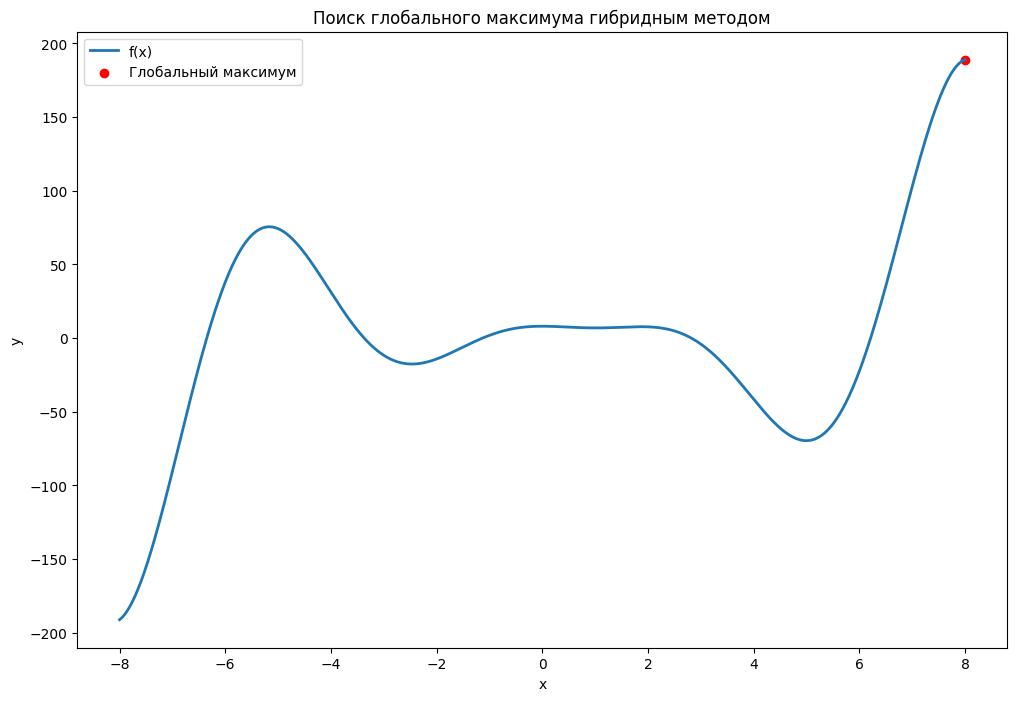

поиск: максимум при x = 8.0000, y = 188.7928
норм результат: x = 7.99999528, y = 188.79272815
Optimization terminated successfully.
         Current function value: -190.441330
         Iterations: 15
         Function evaluations: 30
[8.08691406] 7.999999999


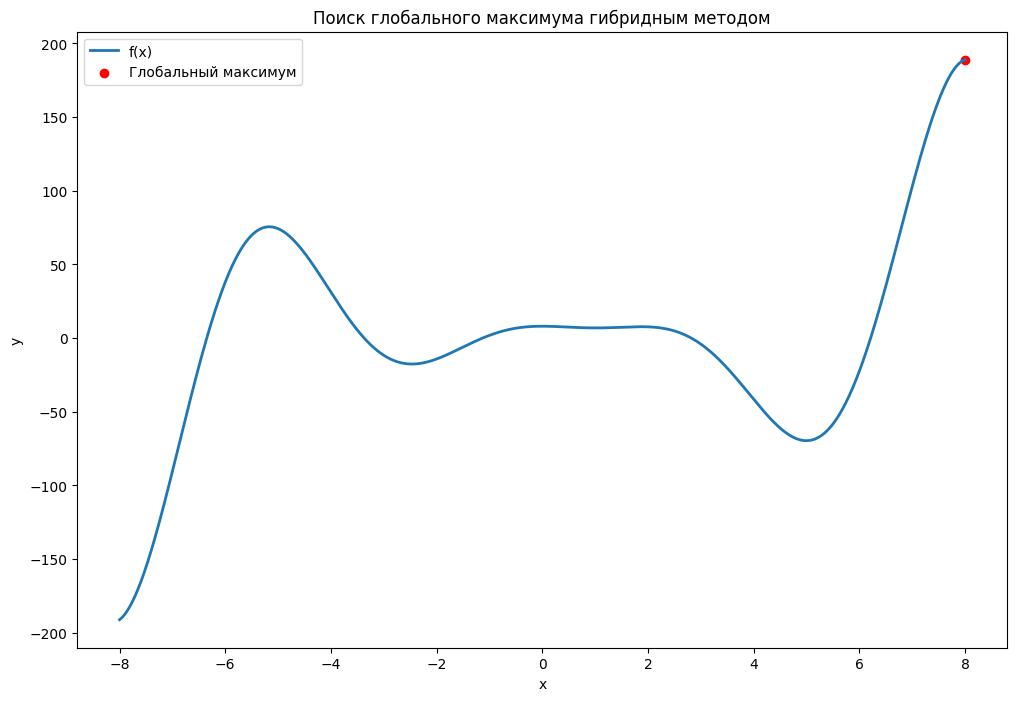

w для которых оптимальная точка не оптимальная при minimize_scalar: [2.8336969534224004, 10.651412865014212, 3.333920096664931, 14.524532730230838, 15.91809721642704, 9.954377534111542, 10.923154709444198, 12.210260943249608, 13.655631660919376, 4.35474868795556, 2.9124051718680635, 1.5229116412197108, 10.439497588762366, 15.133583677516294, 12.673809386844397, 4.546332403249531, 12.048903396003231, 2.6853039883452814, 15.899395160724014, 7.556814460537338, 10.456329213988258, 5.174800999594902, 9.248921811786431, 15.03633709284, 7.547081657657964, 14.704614625408103, 7.710479492941619, 12.027291452458371, 3.0885216863575504, 1.304920426454447, 10.20754533551541, 11.763805598068814, 11.831466829648823, 5.437209740913334, 11.896941671284623, 11.017134350715832, 14.113071229039686, 2.747648520270911, 10.817157896044357, 3.4275055658540037, 15.930918666752856, 7.118198310389366, 12.818184747803745, 2.958357859532091, 9.023469516740898, 12.16049215631419, 14.966024034500771, 2.415040766557

In [8]:
def global_max(w=8, x_min=-8, x_max=8, coarse_step=0.001):

    #  плотный перебор
    x_coarse = np.arange(x_min, x_max + coarse_step, coarse_step)
    #  добавляем границы
    if x_coarse[0] != x_min:
        x_coarse = np.insert(x_coarse, 0, x_min)
    if x_coarse[-1] != x_max:
        x_coarse = np.append(x_coarse, x_max)
    y_coarse = f(x_coarse, w)

    # Находим глобальный максимум
    max_idx = np.argmax(y_coarse)
    x_initial = x_coarse[max_idx]
    y_initial = y_coarse[max_idx]

    print(f"поиск: максимум при x = {x_initial:.4f}, y = {y_initial:.4f}")

    # 2
    result = minimize_scalar(fm, bounds=[max(x_min, x_initial - 0.2), min(x_max, x_initial + 0.2)], method='bounded', args=(w,))
    x_opt = result.x
    y_opt = f(x_opt, w)
    print(f"норм результат: x = {x_opt:.8f}, y = {y_opt:.8f}")
    return x_opt, y_opt

for i in range (100):
    # Параметры
    (x_min, x_max) = (-8, 8)
    w = 8

    # Поиск глобального макс
    x_global, y_global = global_max(w, x_min, x_max)
    x2=bruteforce(w)
    res_fmin=fmin(lambda x: fm(x,wrand), 7)

    razn=abs(x_global-x2)
    razn_fmin=abs(res_fmin-x2)
    
    if razn>tol:
        w_optimize_scalar.append(wrand)
    if razn_fmin>tol:
        print(res_fmin, x2)
        w_fmin.append(wrand)
    
    plt.figure(figsize=(12, 8))
    x_arr = np.linspace(x_min, x_max, 1000)
    plt.plot(x_arr, f(x_arr, w), label='f(x)', linewidth=2)
    plt.scatter(x_global, y_global,color='red',label='Глобальный максимум')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Поиск глобального максимума гибридным методом')
    plt.legend()
    plt.show()

print("w для которых оптимальная точка не оптимальная при minimize_scalar:", w_optimize_scalar)
print("w для которых оптимальная точка не оптимальная при fmin:", w_fmin)